## Toward Targeted Therapy of Hematologic Diseases via Selective JAK2 Inhibition: Structure-Guided Computational Optimization for Drug Discovery

#### Libraries

In [43]:
# Standard library imports
import os
import math
from math import floor
import subprocess
import tempfile
import time
import collections
from collections import defaultdict, Counter
import glob
import shutil
from typing import List, Dict, Tuple, Optional
import joblib
from joblib import Parallel, delayed
import copy
from copy import deepcopy 
from concurrent.futures import ProcessPoolExecutor, as_completed
from io import StringIO
import sys
import csv
import argparse
from pathlib import Path
import re
import hashlib
import cProfile
import pstats

import warnings
from sklearn.exceptions import ConvergenceWarning

# Data handling
import pandas as pd
import numpy as np

# Plotting
# import matplotlib.pyplot as plt

# RDKit – cheminformatics
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Lipinski, rdPartialCharges, rdmolops
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Cluster import Butina
from rdkit.DataStructs import ConvertToNumpyArray
#import meeko
#from meeko import MoleculePreparation, PDBQTWriterLegacy
#import vina
from concurrent.futures import ProcessPoolExecutor, as_completed

# Mordred – molecular descriptors
#import mordred
#from mordred import Calculator, descriptors

# Open Babel – cheminformatics conversion
import openbabel


# Biopython – bioinformatics
import Bio
from Bio import SeqIO, AlignIO, pairwise2
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import PairwiseAligner, MultipleSeqAlignment
from Bio.PDB import MMCIFParser, NeighborSearch, PDBIO, PPBuilder, Select
from Bio.PDB.Polypeptide import is_aa
from Bio.SeqUtils import seq1
from Bio.PDB.MMCIF2Dict import MMCIF2Dict

# Machine learning & statistics
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone
from sklearn.feature_selection import RFE, VarianceThreshold, SelectKBest, mutual_info_regression
from sklearn.impute import KNNImputer
from scipy.stats import spearmanr

# Hyperparameter optimization
import xgboost as xgb
from xgboost import XGBRegressor



In [42]:
import plip
try:
    from plip.structure.preparation import PDBComplex
except Exception as e:
    raise ImportError("PLIP Python API not found. Install via `pip install plip`.") from e

In [35]:
conda install -c conda-forge plip

Retrieving notices: done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [36]:
#!conda install -c conda-forge mamba -y
#!mamba install -c conda-forge pymol-open-source -y

In [37]:
conda install -c bioconda mgltools

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [38]:
conda install biopython

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [39]:
conda install xgboost

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [40]:
conda install openbabel

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [41]:
conda install rdkit

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


## Version 2 of QSAR (RFE)

In [8]:
jak1_data = pd.read_csv("Affinity Data/JAK1/curated_jak1_ki")
jak2_data = pd.read_csv("Affinity Data/JAK2/curated_jak2_ki")
jak3_data = pd.read_csv("Affinity Data/JAK3/curated_jak3_ki")
tyk2_data = pd.read_csv("Affinity Data/TYK2/curated_tyk2_ki")

In [9]:
jak1_data = jak1_data[np.isfinite(jak1_data['pKi'])]
jak2_data = jak2_data[np.isfinite(jak2_data['pKi'])]
jak3_data = jak3_data[np.isfinite(jak3_data['pKi'])]
tyk2_data = tyk2_data[np.isfinite(tyk2_data['pKi'])]

In [10]:
jak1_data = jak1_data[['Curated_SMILES', 'pKi']]
jak2_data = jak2_data[['Curated_SMILES', 'pKi']]
jak3_data = jak3_data[['Curated_SMILES', 'pKi']]
tyk2_data = tyk2_data[['Curated_SMILES', 'pKi']]

In [11]:
jak_data_dfs = [jak1_data, jak2_data, jak3_data, tyk2_data]
for df in jak_data_dfs: df['pKi'] = df['pKi'].apply(lambda x: x + 9)

In [12]:
def aggregate(df, smiles_col="Curated_SMILES", pki_col="pKi"):
    df_agg = (
        df.groupby(smiles_col)
        .agg(
            pKi_median=(pki_col, "median"),
        )
        .reset_index()
    )
    
    return df_agg

In [13]:
jak1_agg_df = aggregate(jak1_data)
jak2_agg_df = aggregate(jak2_data)
jak3_agg_df = aggregate(jak3_data)
tyk2_agg_df = aggregate(tyk2_data)

In [14]:
tyk2_agg_df

,Curated_SMILES,pKi_median
0,C#Cc1cc(Cl)c(C(=O)Nc2ccnc(NC(=O)C3CC3)c2)c(Cl)c1,8.022276
1,C=C(C(=O)NCC)c1ccc(Nc2nc(-c3c(F)cccc3F)nc3c2C(...,7.259637
2,C=CCOC(=O)N1[C@@H]2CCC[C@H]1C[C@@H](Nc1nc(Nc3c...,9.259637
3,C=CCOC(=O)N1[C@@H]2CCC[C@H]1C[C@H](Nc1nc(Nc3cc...,9.259637
4,C=CCOC(=O)N1[C@@H]2CCC[C@H]1C[C@H](Nc1nc(Nc3cc...,7.301030
...,...,...
946,c1ccc(CN2CCC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,6.602060
947,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.148742
948,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.050610
949,c1ccc(CNc2cc(-c3c[nH]c4ncccc34)ncn2)cc1,7.000000


In [15]:
agg_dfs = [jak1_agg_df, jak2_agg_df, jak3_agg_df, tyk2_agg_df]

In [27]:
def calculate_mordred_descriptors(df, smiles_col, nproc=8):
    """
    Calculate 2D Mordred descriptors for a dataframe containing SMILES.

    Args:
        df (pd.DataFrame): Original dataframe with SMILES and other columns.
        smiles_col (str): Name of the column containing SMILES strings.
        nproc (int): Number of processes for parallel descriptor calculation.

    Returns:
        pd.DataFrame: New dataframe with original columns + 2D descriptors.
    """
    # Initialize Mordred 2D calculator (no nproc here)
    calc = Calculator(descriptors, ignore_3D=True)

    # Convert SMILES to RDKit molecule objects
    mols = df[smiles_col].apply(Chem.MolFromSmiles)

    # Warn if some SMILES could not be converted
    if mols.isnull().any():
        print(f"Warning: {mols.isnull().sum()} SMILES could not be converted.")

    # Calculate descriptors with parallelization
    descriptors_df = calc.pandas(mols, nproc=nproc)

    # Combine original columns with descriptors
    combined_df = pd.concat(
        [df.reset_index(drop=True), descriptors_df.reset_index(drop=True)],
        axis=1
    )

    return combined_df

In [28]:
jak1_initial_desc_df = calculate_mordred_descriptors(jak1_agg_df, 'Curated_SMILES', nproc=os.cpu_count())
jak2_initial_desc_df = calculate_mordred_descriptors(jak2_agg_df, 'Curated_SMILES', nproc=os.cpu_count())
jak3_initial_desc_df = calculate_mordred_descriptors(jak3_agg_df, 'Curated_SMILES', nproc=os.cpu_count())
tyk2_initial_desc_df = calculate_mordred_descriptors(tyk2_agg_df, 'Curated_SMILES', nproc=os.cpu_count())

 60%|██████    | 1364/2264 [12:14<08:04,  1.86it/s]

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 90%|████████▉ | 2035/2264 [17:51<02:00,  1.91it/s]

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 92%|█████████▏| 2074/2264 [18:14<01:58,  1.61it/s]

...

 65%|██████▌   | 734/1126 [05:37<03:15,  2.01it/s]

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 44%|████▍     | 419/951 [03:23<05:49,  1.52it/s]

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 951/951 [07:07<00:00,  2.22it/s]


In [29]:
descriptor_dfs = [jak1_initial_desc_df, jak2_initial_desc_df, jak3_initial_desc_df, tyk2_initial_desc_df]

In [30]:
filtered_dataframes = []

for df in descriptor_dfs:

    exclude_cols = df.columns[:2].tolist()
    descriptor_cols = df.columns[2:]

    # 🔧 NEW: replace ±inf with NaN BEFORE any checks
    df = df.copy()
    df[descriptor_cols] = df[descriptor_cols].replace(
        [np.inf, -np.inf], np.nan
    )

    bad_descriptors = []
    for col in descriptor_cols:
        numeric_col = pd.to_numeric(df[col], errors='coerce')
        percent_non_numeric = numeric_col.isna().mean()
        if percent_non_numeric > 0.05:
            bad_descriptors.append(col)

    df_filtered = df.drop(columns=bad_descriptors)

    print(f"Removed {len(bad_descriptors)} columns from dataframe")

    descriptor_cols_filtered = df_filtered.columns[2:]

    # Ensure remaining descriptors are numeric
    df_filtered[descriptor_cols_filtered] = df_filtered[
        descriptor_cols_filtered
    ].apply(lambda col: pd.to_numeric(col, errors='coerce'))

    # KNN imputation (now safe)
    imputer = KNNImputer(n_neighbors=5)
    df_imputed = df_filtered.copy()
    df_imputed[descriptor_cols_filtered] = imputer.fit_transform(
        df_filtered[descriptor_cols_filtered]
    )

    filtered_dataframes.append(df_imputed)

Removed 178 columns from dataframe
Removed 183 columns from dataframe
Removed 183 columns from dataframe
Removed 183 columns from dataframe


In [31]:
jak1_filtered = filtered_dataframes[0]
jak2_filtered = filtered_dataframes[1]
jak3_filtered = filtered_dataframes[2]
tyk2_filtered = filtered_dataframes[3]
filtered_dataframes = [jak1_filtered, jak2_filtered, jak3_filtered, tyk2_filtered]

In [32]:
kept_descriptor_lists = []   # list where each item is the kept descriptors for that dataframe
uncorr_dfs = []            # list where each item is that dataframe's filtered version

for df in filtered_dataframes:

    # --- 1. Identify columns ---
    target_col = df.columns[1]              # pIC50
    descriptor_cols = list(df.columns[2:])  # descriptors only

    descriptor_df = df[descriptor_cols]

    # --- 2. Compute correlations ---
    corr = descriptor_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    target_corr = df[descriptor_cols].corrwith(df[target_col]).abs()

    # --- 3. Determine descriptors to drop ---
    to_drop = set()

    for col1 in upper.columns:
        for col2 in upper.index:

            # skip diagonal
            if col1 == col2:
                continue

            # high correlation?
            if upper.loc[col2, col1] > 0.9:

                # if one already dropped, skip
                if col1 in to_drop or col2 in to_drop:
                    continue

                # drop the one less correlated to pIC50
                if target_corr[col1] >= target_corr[col2]:
                    to_drop.add(col2)
                else:
                    to_drop.add(col1)

    # --- 4. Unique kept descriptors for THIS dataframe ---
    kept_descriptors = [d for d in descriptor_cols if d not in to_drop]
    kept_descriptor_lists.append(kept_descriptors)

    # --- 5. Filter dataframe for THIS dataframe ---
    filtered_df = pd.concat(
        [df.iloc[:, :2], df[kept_descriptors]],
        axis=1
    )
    uncorr_dfs.append(filtered_df)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid v

In [33]:
uncorr_jak1 = uncorr_dfs[0]
uncorr_jak2 = uncorr_dfs[1]
uncorr_jak3 = uncorr_dfs[2]
uncorr_tyk2 = uncorr_dfs[3]

In [34]:
scaled_dfs = []
scaler = StandardScaler()

for df in uncorr_dfs:
    first_two_cols = df.iloc[:, :2]
    scaled_cols = pd.DataFrame(scaler.fit_transform(df.iloc[:, 2:]), columns=df.columns[2:])
    scaled_df = pd.concat([first_two_cols, scaled_cols], axis=1)
    scaled_dfs.append(scaled_df)

In [35]:
jak1_scaled = scaled_dfs[0]
jak2_scaled = scaled_dfs[1]
jak3_scaled = scaled_dfs[2]
tyk2_scaled = scaled_dfs[3]

In [36]:
unvar_dfs = []

for df in scaled_dfs:
    threshold = 1e-5  # example

    # Keep the first two columns unchanged
    meta_cols = df.iloc[:, :2]

    # Descriptor-only dataframe
    desc_cols = df.iloc[:, 2:]

    # Compute variance of descriptors
    variances = desc_cols.var()

    # Select descriptors with sufficient variance
    good_desc = variances[variances > threshold].index

    # Final filtered dataframe
    df_var_filtered = pd.concat([meta_cols, desc_cols[good_desc]], axis=1)

    unvar_dfs.append(df_var_filtered)

In [37]:
jak1_unvar = unvar_dfs[0]
jak2_unvar = unvar_dfs[1]
jak3_unvar = unvar_dfs[2]
tyk2_unvar = unvar_dfs[3]

In [38]:
jak1_unvar

,Curated_SMILES,pKi_median,nAcid,nBase,SpMax_A,SpDiam_A,SpMAD_A,VE1_A,VR2_A,VR3_A,...,JGI8,JGI9,JGI10,TopoShapeIndex,MWC10,SRW09,TSRW10,AMW,WPath,mZagreb1
0,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,7.259637,-0.072274,-1.278325,-1.415056,-0.373774,-1.442815,0.046945,-0.186192,-0.233094,...,0.017210,0.068559,1.115900,-0.539870,-0.231798,-6.333098,-1.497949,0.356862,-0.021020,0.840279
1,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637,-0.072274,-1.278325,-0.030492,0.707621,-1.083835,0.259349,-0.236074,-1.164913,...,2.378854,1.772381,1.614173,-1.238969,-0.404661,-0.561869,-0.991586,0.457489,-0.021026,0.113337
2,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637,-0.072274,-1.278325,-0.428509,0.170302,0.185060,-0.662081,-0.209480,-0.921839,...,1.246024,0.967884,1.544767,-1.238969,-1.206506,-0.561869,-1.282349,-0.394262,-0.021026,-0.651710
3,C=CC(=O)N1CCC[C@H](Oc2cc(-c3cc(F)c(O)cc3CC)cn3...,7.259637,-0.072274,-1.278325,-0.409843,0.193072,0.150577,-0.596059,-0.217248,-1.009334,...,0.819496,1.153020,1.382223,0.858326,-1.165914,-0.561869,-1.281813,-0.394262,-0.021027,-0.651710
4,C=CC(=O)N1[C@@H]2CC[C@H]1C[C@H](Oc1cc(-c3cc(F)...,7.259637,-0.072274,-1.278325,0.206757,0.583914,0.570514,0.640597,-0.240403,-1.238940,...,0.345347,0.997898,1.183150,-1.238969,-0.043436,0.233740,-0.714027,-0.488900,-0.021026,-0.557911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2259,c1ccc(CN2CCC[C@@H](n3nnc4cnc5[nH]ccc5c43)C2)cc1,7.602060,-0.072274,0.302302,0.898720,0.138518,2.526383,-1.782916,-0.161856,-0.824889,...,-1.661611,-1.067362,-2.182422,0.858326,-1.372520,0.162416,-1.668749,-0.644482,-0.021028,-2.586314
2260,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.055517,-0.072274,0.302302,0.898720,0.138518,2.526383,-1.782916,-0.161856,-0.824889,...,-1.661611,-1.067362,-2.182422,0.858326,-1.372520,0.162416,-1.668749,-0.877269,-0.021028,-2.586314
2261,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.823909,-0.072274,0.302302,1.026810,-0.213609,2.647242,-1.755918,-0.178941,-1.012924,...,-1.090729,-1.067362,-2.182422,0.858326,-1.355857,0.472037,-1.674448,-0.651842,-0.021028,-2.691837
2262,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,7.795880,-0.072274,0.302302,0.855592,0.050643,2.762194,-1.869127,-0.136963,-0.675338,...,-0.739905,-0.906198,-1.032686,-1.538582,-1.431809,0.162416,-1.669363,-0.401115,-0.021028,-2.586314


In [39]:
def rfe_qsar(
    dataframe: pd.DataFrame,
    target_col: str,
    smiles_col: str | None,
    model,
    rfe_estimator=None,
    n_jobs: int = -1,
    outer_folds: int = 5,
    min_features: int = 80,
    max_features_ratio: float = 0.1,
    spearman_weight: float = 1.0,
    rmse_weight: float = 1.0,
    step: int = 5,
    random_state: int = 0,
    verbose: bool = True
):
    """
    Compact, modern RFE-based QSAR feature selection optimized for combined Spearman+RMSE.
    - Assumes descriptors are preprocessed (no NaNs). The function will raise if NaNs are present.
    - 'model' must be a pre-instantiated estimator (e.g., XGBRegressor(...)).
    - Returns dict with 'selected_features', 'feature_scores', 'final_model'.
    """

    # --- basic checks ---
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe must be a pandas DataFrame")

    if target_col not in dataframe.columns:
        raise ValueError(f"target_col '{target_col}' not in dataframe")

    # allow smiles_col to be None or missing; if missing, treat as not present
    if smiles_col is not None and smiles_col not in dataframe.columns:
        if verbose:
            print(f"[WARN] smiles_col '{smiles_col}' not found — proceeding without it.")
        smiles_col = None

    # descriptor columns = all except target and optional smiles
    exclude = {target_col}
    if smiles_col:
        exclude.add(smiles_col)
    descriptor_cols = [c for c in dataframe.columns if c not in exclude]
    if len(descriptor_cols) == 0:
        raise ValueError("No descriptor columns found (after excluding target and SMILES).")

    # extract X, y
    X_all = dataframe[descriptor_cols].copy()
    y_all = dataframe[target_col].copy()
    n_samples = len(X_all)

    # require numeric descriptors (coerce and error if non-numeric remain)
    for c in X_all.columns:
        if not pd.api.types.is_numeric_dtype(X_all[c]):
            X_all[c] = pd.to_numeric(X_all[c], errors="coerce")

    if X_all.isna().any().any():
        raise ValueError("Descriptor matrix contains NaNs. Preprocess (impute/clean) before calling this function.")

    # compute max_features and validate step
    suggested = int(floor(n_samples * max_features_ratio))
    max_features = max(min_features, suggested)
    max_features = min(max_features, max(1, n_samples - 1))

    n_features_initial = X_all.shape[1]
    if step < 1:
        step = 1
    if step >= n_features_initial:
        step = max(1, n_features_initial // 10)
        if verbose:
            print(f"[WARN] step too large; using step={step}")

    if verbose:
        print(f"[INFO] n_samples={n_samples}, descriptors={n_features_initial}, selecting k={max_features}, step={step}")

    # prepare rfe_estimator
    if rfe_estimator is None:
        rfe_estimator = ElasticNetCV(cv=5, n_jobs=n_jobs, random_state=random_state)

    if not hasattr(rfe_estimator, "fit"):
        raise TypeError("rfe_estimator must be an estimator with a .fit() method")

    # outer CV
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=random_state)
    descriptor_names = X_all.columns.tolist()

    # worker
    def _process_fold(tr_idx, val_idx):
        X_tr = X_all.iloc[tr_idx].values
        X_val = X_all.iloc[val_idx].values
        y_tr = y_all.iloc[tr_idx].values
        y_val = y_all.iloc[val_idx].values

        # run RFE (silence ElasticNet convergence warnings)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                rfe = RFE(estimator=clone(rfe_estimator), n_features_to_select=max_features, step=step)
                # RFE expects 2D inputs; pass DataFrame to preserve column order for support_ mapping
                rfe.fit(X_all.iloc[tr_idx, :], y_tr)
        except Exception as e:
            # fallback: try a lighter ElasticNetCV (fewer internal folds)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                fallback = ElasticNetCV(cv=3, n_jobs=1, random_state=random_state)
                rfe = RFE(estimator=fallback, n_features_to_select=max_features, step=step)
                rfe.fit(X_all.iloc[tr_idx, :], y_tr)

        support_mask = rfe.support_
        selected = [name for name, s in zip(descriptor_names, support_mask) if s]

        # fast evaluation with linear regression
        lr = LinearRegression()
        lr.fit(X_all.loc[tr_idx, selected], y_tr)
        y_pred = lr.predict(X_all.loc[val_idx, selected])

        rho, _ = spearmanr(y_val, y_pred)
        rho = 0.0 if np.isnan(rho) else float(rho)
        rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))

        combined = float(spearman_weight * rho - rmse_weight * rmse)
        return combined, selected

    # parallel outer folds
    jobs = list(outer_cv.split(X_all))
    results = Parallel(n_jobs=n_jobs)(delayed(_process_fold)(tr_idx, val_idx) for tr_idx, val_idx in jobs)

    # accumulate scores
    feature_scores = pd.Series(0.0, index=descriptor_names)
    for combined, selected in results:
        for f in selected:
            feature_scores[f] += combined

    feature_scores = feature_scores.sort_values(ascending=False)
    final_selected = feature_scores.head(max_features).index.tolist()

    if verbose:
        print(f"[INFO] Selected {len(final_selected)} features.")

    # final model fit (clone to avoid mutating input)
    final_model = clone(model)
    X_final = X_all[final_selected].values
    y_final = y_all.values
    try:
        final_model.fit(X_final, y_final)
    except Exception:
        # attempt safe coercion and re-fit with numpy arrays
        final_model.fit(np.asarray(X_final, dtype=float), np.asarray(y_final, dtype=float))

    return {
        "selected_features": final_selected,
        "feature_scores": feature_scores,
        "final_model": final_model
    }

In [40]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [92]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

rfe_result_xgboost_jak1 = rfe_qsar(
    dataframe=jak1_unvar,
    target_col='pKi_median',         # target column
    smiles_col='Curated_SMILES',      # SMILES column to ignore
    model=xgb_model,          # final model
    outer_folds=5,            # number of outer CV folds
    n_jobs=-1,                # parallelize
    spearman_weight=1.0,      # importance of ranking
    rmse_weight=0.5,          # importance of absolute error
    verbose=True
)

print("Top features:", rfe_result_xgboost_jak1['selected_features'])
xgboost_jak1_final_model = rfe_result_xgboost_jak1['final_model']

[INFO] n_samples=2264, descriptors=412, selecting k=226, step=5
[INFO] Selected 226 features.
Top features: ['TSRW10', 'nAcid', 'nBase', 'TopoShapeIndex', 'SpDiam_A', 'JGI10', 'VE1_A', 'VR2_A', 'JGI9', 'nSpiro', 'nBridgehead', 'JGI8', 'JGI7', 'JGI6', 'AATS8dv', 'JGI5', 'n6aHRing', 'n7ARing', 'MID_O', 'piPC4', 'AMID_h', 'AMID_N', 'VSA_EState3', 'VSA_EState7', 'AATSC0Z', 'AATSC4Z', 'ATSC1i', 'ATSC6i', 'AATSC0c', 'AATSC1c', 'AATSC2c', 'AATSC7c', 'ATSC5v', 'ATSC4are', 'ATSC0i', 'ATSC1s', 'ATSC2s', 'ATSC3s', 'ATSC7s', 'ATSC3Z', 'SlogP_VSA8', 'PEOE_VSA8', 'PEOE_VSA12', 'PEOE_VSA13', 'GhoseFilter', 'PEOE_VSA3', 'PEOE_VSA6', 'IC1', 'MAXaaN', 'MINssCH2', 'ETA_shape_y', 'SaaNH', 'MATS3s', 'MATS7s', 'AATSC5m', 'AATSC0p', 'NssNH', 'NssO', 'NaaO', 'AXp-7dv', 'NdCH2', 'C4SP3', 'GATS8Z', 'GATS5m', 'GATS7m', 'GATS8s', 'GATS3Z', 'GATS6Z', 'GATS8dv', 'GATS2c', 'GATS5c', 'MATS1se', 'MATS3se', 'JGI2', 'JGI3', 'JGI4', 'n9FAHRing', 'RotRatio', 'n10FaRing', 'n7FAHRing', 'n8FAHRing', 'n4AHRing', 'n10FRing', '

In [93]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

rfe_result_xgboost_jak2 = rfe_qsar(
    dataframe=jak2_unvar,
    target_col='pKi_median',         # target column
    smiles_col='Curated_SMILES',      # SMILES column to ignore
    model=xgb_model,          # final model
    outer_folds=5,            # number of outer CV folds
    n_jobs=-1,                # parallelize
    spearman_weight=1.0,      # importance of ranking
    rmse_weight=0.5,          # importance of absolute error
    verbose=True
)

print("Top features:", rfe_result_xgboost_jak2['selected_features'])
xgboost_jak2_final_model = rfe_result_xgboost_jak2['final_model']

[INFO] n_samples=2322, descriptors=473, selecting k=232, step=5
[INFO] Selected 232 features.
Top features: ['JGI8', 'AATS7d', 'AATS7i', 'nAcid', 'JGI2', 'JGI3', 'SLogP', 'PEOE_VSA4', 'MATS8c', 'n8FAHRing', 'n9FRing', 'n10FaRing', 'nFaHRing', 'n6AHRing', 'n6Ring', 'n5aHRing', 'AMID_N', 'piPC3', 'VSA_EState9', 'MDEC-33', 'MDEN-22', 'ATSC5v', 'ATSC6v', 'ATSC8v', 'ATSC4Z', 'ATSC6Z', 'ATSC1m', 'ATSC8s', 'GATS5m', 'GATS7m', 'GATS3s', 'GGI8', 'VSA_EState7', 'EState_VSA8', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA10', 'EState_VSA1', 'AATSC5dv', 'AATSC6s', 'GATS2c', 'MATS8m', 'SdCH2', 'AATSC4c', 'AATSC5c', 'ATSC6i', 'AATSC0c', 'ATSC7pe', 'ATSC8are', 'ATSC3p', 'PEOE_VSA11', 'PEOE_VSA3', 'AATSC7c', 'ATSC7p', 'AATSC4Z', 'AATSC7m', 'MAXaaN', 'SaaO', 'SRW05', 'SpMAD_A', 'VE1_A', 'JGI10', 'JGI9', 'nG12FaHRing', 'n7FAHRing', 'JGI7', 'JGI6', 'JGI5', 'JGI4', 'n7ARing', 'n6FARing', 'n4ARing', 'nBase', 'nSpiro', 'ATSC5p', 'ATSC8p', 'ATSC8i', 'MATS7p', 'GATS6i', 'AATSC7s', 'EState_VSA6', 'ATSC2dv', 'ATSC1d',

In [94]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

rfe_result_xgboost_jak3 = rfe_qsar(
    dataframe=jak3_unvar,
    target_col='pKi_median',         # target column
    smiles_col='Curated_SMILES',      # SMILES column to ignore
    model=xgb_model,          # final model
    outer_folds=5,            # number of outer CV folds
    n_jobs=-1,                # parallelize
    spearman_weight=1.0,      # importance of ranking
    rmse_weight=0.5,          # importance of absolute error
    verbose=True
)

print("Top features:", rfe_result_xgboost_jak3['selected_features'])
xgboost_jak3_final_model = rfe_result_xgboost_jak3['final_model']

[INFO] n_samples=1126, descriptors=492, selecting k=112, step=5
[INFO] Selected 112 features.
Top features: ['MATS6d', 'JGI6', 'JGI4', 'n5aHRing', 'MATS6i', 'GATS2s', 'ATSC7c', 'MATS7s', 'VE1_A', 'ATSC6Z', 'VSA_EState4', 'AATSC7s', 'GATS2Z', 'BCUTare-1l', 'BCUTc-1h', 'BCUTc-1l', 'C1SP3', 'C1SP2', 'EState_VSA10', 'SlogP_VSA3', 'SMR_VSA9', 'SlogP_VSA10', 'NdCH2', 'NaaO', 'TopoShapeIndex', 'nAcid', 'SlogP_VSA1', 'PEOE_VSA9', 'PEOE_VSA3', 'Lipinski', 'AETA_beta_ns_d', 'ATSC7se', 'SpDiam_A', 'nG12FaHRing', 'TpiPC10', 'C2SP1', 'SdssC', 'nHBAcc', 'WPath', 'ATSC4v', 'ATSC4Z', 'nRot', 'MATS4d', 'SlogP_VSA11', 'AATSC8s', 'BCUTs-1h', 'AATS4i', 'ATSC7v', 'n8FHRing', 'GATS6s', 'AATSC5s', 'ATSC8i', 'nCl', 'AXp-4dv', 'GATS7se', 'BCUTv-1h', 'NssssC', 'JGI3', 'JGI7', 'nFaHRing', 'nBridgehead', 'C3SP2', 'NdsCH', 'ZMIC5', 'GATS8p', 'MINaasC', 'EState_VSA3', 'n9FHRing', 'ATSC6p', 'AATS7dv', 'GhoseFilter', 'GATS1dv', 'CIC5', 'IC3', 'RPCG', 'SlogP_VSA8', 'GATS8s', 'GATS2dv', 'MAXaaN', 'nG12FAHRing', 'nBase'

In [95]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

rfe_result_xgboost_tyk2 = rfe_qsar(
    dataframe=tyk2_unvar,
    target_col='pKi_median',         # target column
    smiles_col='Curated_SMILES',      # SMILES column to ignore
    model=xgb_model,          # final model
    outer_folds=5,            # number of outer CV folds
    n_jobs=-1,                # parallelize
    spearman_weight=1.0,      # importance of ranking
    rmse_weight=0.5,          # importance of absolute error
    verbose=True
)

print("Top features:", rfe_result_xgboost_tyk2['selected_features'])
xgboost_tyk2_final_model = rfe_result_xgboost_tyk2['final_model']

[INFO] n_samples=951, descriptors=467, selecting k=95, step=5
[INFO] Selected 95 features.
Top features: ['JGI10', 'GATS7c', 'BCUTc-1l', 'GATS2s', 'n8FHRing', 'MAXaaN', 'AATSC8dv', 'SaasC', 'VSA_EState7', 'BCUTm-1l', 'ATSC4s', 'BCUTse-1l', 'IC2', 'nBondsD', 'n10FARing', 'RPCG', 'ATSC4v', 'EState_VSA9', 'NaaO', 'ATSC5c', 'ATSC2m', 'AATSC8m', 'ATSC4c', 'nBridgehead', 'AATS8d', 'GGI8', 'GATS6Z', 'PEOE_VSA9', 'ATSC8s', 'nG12FHRing', 'ATSC8v', 'JGI7', 'SRW05', 'ATSC7dv', 'MATS5i', 'AATS6i', 'Lipinski', 'ATSC6p', 'EState_VSA7', 'JGI4', 'JGI9', 'nO', 'EState_VSA5', 'Xch-4d', 'nBondsT', 'ATSC7p', 'NdssC', 'NdsCH', 'GATS8s', 'GATS8c', 'AATSC5m', 'AATS4d', 'TopoShapeIndex', 'piPC10', 'n6AHRing', 'MINaaN', 'MATS3i', 'RotRatio', 'nFHRing', 'GATS4i', 'SpDiam_A', 'n4ARing', 'ATSC6i', 'GATS7m', 'EState_VSA3', 'ATSC7v', 'NdCH2', 'SlogP_VSA6', 'AMID_X', 'nAcid', 'VSA_EState3', 'GATS6i', 'BCUTdv-1l', 'ATSC2v', 'AATS7i', 'nFaRing', 'MDEC-22', 'AATSC4se', 'AATSC8c', 'NssS', 'ATSC6se', 'AATS8Z', 'AATSC3m',

In [72]:
jak1_unvar

,Curated_SMILES,pKi_median,nAcid,nBase,SpMax_A,SpDiam_A,SpMAD_A,VE1_A,VR2_A,VR3_A,...,JGI8,JGI9,JGI10,TopoShapeIndex,MWC10,SRW09,TSRW10,AMW,WPath,mZagreb1
0,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,7.259637,-0.072274,-1.278325,-1.415056,-0.373774,-1.442815,0.046945,-0.186192,-0.233094,...,0.017210,0.068559,1.115900,-0.539870,-0.231798,-6.333098,-1.497949,0.356862,-0.021020,0.840279
1,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637,-0.072274,-1.278325,-0.030492,0.707621,-1.083835,0.259349,-0.236074,-1.164913,...,2.378854,1.772381,1.614173,-1.238969,-0.404661,-0.561869,-0.991586,0.457489,-0.021026,0.113337
2,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637,-0.072274,-1.278325,-0.428509,0.170302,0.185060,-0.662081,-0.209480,-0.921839,...,1.246024,0.967884,1.544767,-1.238969,-1.206506,-0.561869,-1.282349,-0.394262,-0.021026,-0.651710
3,C=CC(=O)N1CCC[C@H](Oc2cc(-c3cc(F)c(O)cc3CC)cn3...,7.259637,-0.072274,-1.278325,-0.409843,0.193072,0.150577,-0.596059,-0.217248,-1.009334,...,0.819496,1.153020,1.382223,0.858326,-1.165914,-0.561869,-1.281813,-0.394262,-0.021027,-0.651710
4,C=CC(=O)N1[C@@H]2CC[C@H]1C[C@H](Oc1cc(-c3cc(F)...,7.259637,-0.072274,-1.278325,0.206757,0.583914,0.570514,0.640597,-0.240403,-1.238940,...,0.345347,0.997898,1.183150,-1.238969,-0.043436,0.233740,-0.714027,-0.488900,-0.021026,-0.557911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2259,c1ccc(CN2CCC[C@@H](n3nnc4cnc5[nH]ccc5c43)C2)cc1,7.602060,-0.072274,0.302302,0.898720,0.138518,2.526383,-1.782916,-0.161856,-0.824889,...,-1.661611,-1.067362,-2.182422,0.858326,-1.372520,0.162416,-1.668749,-0.644482,-0.021028,-2.586314
2260,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.055517,-0.072274,0.302302,0.898720,0.138518,2.526383,-1.782916,-0.161856,-0.824889,...,-1.661611,-1.067362,-2.182422,0.858326,-1.372520,0.162416,-1.668749,-0.877269,-0.021028,-2.586314
2261,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.823909,-0.072274,0.302302,1.026810,-0.213609,2.647242,-1.755918,-0.178941,-1.012924,...,-1.090729,-1.067362,-2.182422,0.858326,-1.355857,0.472037,-1.674448,-0.651842,-0.021028,-2.691837
2262,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,7.795880,-0.072274,0.302302,0.855592,0.050643,2.762194,-1.869127,-0.136963,-0.675338,...,-0.739905,-0.906198,-1.032686,-1.538582,-1.431809,0.162416,-1.669363,-0.401115,-0.021028,-2.586314


In [45]:
jak1_features = ['TSRW10', 'nAcid', 'nBase', 'TopoShapeIndex', 'SpDiam_A', 'JGI10', 'VE1_A', 'VR2_A', 'JGI9', 'nSpiro', 'nBridgehead', 'JGI8', 'JGI7', 'JGI6', 'AATS8dv', 'JGI5', 'n6aHRing', 'n7ARing', 'MID_O', 'piPC4', 'AMID_h', 'AMID_N', 'VSA_EState3', 'VSA_EState7', 'AATSC0Z', 'AATSC4Z', 'ATSC1i', 'ATSC6i', 'AATSC0c', 'AATSC1c', 'AATSC2c', 'AATSC7c', 'ATSC5v', 'ATSC4are', 'ATSC0i', 'ATSC1s', 'ATSC2s', 'ATSC3s', 'ATSC7s', 'ATSC3Z', 'SlogP_VSA8', 'PEOE_VSA8', 'PEOE_VSA12', 'PEOE_VSA13', 'GhoseFilter', 'PEOE_VSA3', 'PEOE_VSA6', 'IC1', 'MAXaaN', 'MINssCH2', 'ETA_shape_y', 'SaaNH', 'MATS3s', 'MATS7s', 'AATSC5m', 'AATSC0p', 'NssNH', 'NssO', 'NaaO', 'AXp-7dv', 'NdCH2', 'C4SP3', 'GATS8Z', 'GATS5m', 'GATS7m', 'GATS8s', 'GATS3Z', 'GATS6Z', 'GATS8dv', 'GATS2c', 'GATS5c', 'MATS1se', 'MATS3se', 'JGI2', 'JGI3', 'JGI4', 'n9FAHRing', 'RotRatio', 'n10FaRing', 'n7FAHRing', 'n8FAHRing', 'n4AHRing', 'n10FRing', 'nFaRing', 'ATSC5c', 'ATSC7dv', 'ATSC8dv', 'ATSC8d', 'AATS4i', 'AATS7i', 'AATS8i', 'MATS6Z', 'MATS2dv', 'GATS1i', 'GATS8p', 'BCUTd-1l', 'GATS3dv', 'EState_VSA8', 'GATS3c', 'MDEN-23', 'SsCH3', 'GATS7d', 'GATS7se', 'nFHRing', 'piPC9', 'BCUTm-1h', 'Lipinski', 'n6aRing', 'ATSC1m', 'n6FARing', 'MWC10', 'GATS6c', 'ATSC2m', 'ATSC0Z', 'SMR_VSA3', 'ATS7s', 'AATS6d', 'ATSC8p', 'n10FAHRing', 'nRot', 'nFAHRing', 'n7FARing', 'n6HRing', 'GATS3d', 'PEOE_VSA9', 'PEOE_VSA4', 'MATS3c', 'ATSC4c', 'AATSC1p', 'MATS3p', 'AATS6p', 'SRW09', 'SLogP', 'GATS1s', 'ATSC1are', 'SpMAD_A', 'SdS', 'ATSC8i', 'WPath', 'GATS3s', 'nHRing', 'C2SP1', 'nN', 'n9FaHRing', 'AATSC0v', 'ATSC3pe', 'AATSC7se', 'AATSC7m', 'MDEN-22', 'n5AHRing', 'SlogP_VSA1', 'GATS8d', 'C1SP3', 'EState_VSA5', 'AATSC0dv', 'AATSC3dv', 'BCUTs-1h', 'GGI9', 'JGI1', 'AATSC4i', 'AATSC5d', 'naRing', 'MATS1v', 'naHRing', 'nG12FaHRing', 'GATS6dv', 'MAXssCH2', 'SMR_VSA2', 'Xch-4d', 'GATS8c', 'AATSC8c', 'ETA_shape_x', 'BCUTd-1h', 'AATS5d', 'AATSC1dv', 'ATSC0c', 'ATSC8v', 'AATS7p', 'AATS5p', 'AATS0i', 'AATS3p', 'TopoPSA', 'AMW', 'SpMax_A', 'AATS3d', 'AATSC0d', 'AATS8d', 'MATS1i', 'AATS7d', 'GATS6d', 'Xc-4dv', 'SMR_VSA6', 'MATS8s', 'n6Ring', 'GATS5s', 'GATS3p', 'GATS7v', 'MINaasC', 'BIC0', 'EState_VSA3', 'SdsN', 'VSA_EState9', 'GATS4m', 'MATS3i', 'ATSC1d', 'AATSC8pe', 'C3SP2', 'SaasC', 'ATSC1dv', 'ATSC2dv', 'VR3_A', 'SMR_VSA9', 'GATS4c', 'ATSC1c', 'MATS1dv', 'SdsCH', 'GATS7c', 'AATSC6c', 'GATS7i', 'MDEC-23', 'SMR_VSA4', 'MID_h', 'MATS6s', 'n3ARing', 'MATS4d', 'NaasC', 'Curated_SMILES', 'pKi_median']
jak2_features = ['JGI8', 'AATS7d', 'AATS7i', 'nAcid', 'JGI2', 'JGI3', 'SLogP', 'PEOE_VSA4', 'MATS8c', 'n8FAHRing', 'n9FRing', 'n10FaRing', 'nFaHRing', 'n6AHRing', 'n6Ring', 'n5aHRing', 'AMID_N', 'piPC3', 'VSA_EState9', 'MDEC-33', 'MDEN-22', 'ATSC5v', 'ATSC6v', 'ATSC8v', 'ATSC4Z', 'ATSC6Z', 'ATSC1m', 'ATSC8s', 'GATS5m', 'GATS7m', 'GATS3s', 'GGI8', 'VSA_EState7', 'EState_VSA8', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA10', 'EState_VSA1', 'AATSC5dv', 'AATSC6s', 'GATS2c', 'MATS8m', 'SdCH2', 'AATSC4c', 'AATSC5c', 'ATSC6i', 'AATSC0c', 'ATSC7pe', 'ATSC8are', 'ATSC3p', 'PEOE_VSA11', 'PEOE_VSA3', 'AATSC7c', 'ATSC7p', 'AATSC4Z', 'AATSC7m', 'MAXaaN', 'SaaO', 'SRW05', 'SpMAD_A', 'VE1_A', 'JGI10', 'JGI9', 'nG12FaHRing', 'n7FAHRing', 'JGI7', 'JGI6', 'JGI5', 'JGI4', 'n7ARing', 'n6FARing', 'n4ARing', 'nBase', 'nSpiro', 'ATSC5p', 'ATSC8p', 'ATSC8i', 'MATS7p', 'GATS6i', 'AATSC7s', 'EState_VSA6', 'ATSC2dv', 'ATSC1d', 'ATSC2m', 'n8AHRing', 'n10FRing', 'AATS4i', 'nG12AHRing', 'MATS6dv', 'AATSC5i', 'PEOE_VSA9', 'ATSC6se', 'AATSC8are', 'ATSC3pe', 'SdsCH', 'SaaS', 'AATSC1dv', 'ATSC7s', 'AATSC8dv', 'GATS8s', 'AATSC3s', 'AATSC8d', 'GATS2s', 'JGI1', 'ATSC4v', 'ATSC2se', 'AATS6d', 'n11FAHRing', 'piPC10', 'MATS3Z', 'WPath', 'VSA_EState6', 'SMR_VSA3', 'NaaNH', 'TopoShapeIndex', 'ATSC1s', 'n6FAHRing', 'ZMIC2', 'BCUTc-1h', 'Xc-6dv', 'NddsN', 'NdsN', 'NssS', 'SdssC', 'SaasC', 'NsBr', 'AETA_beta_ns_d', 'ECIndex', 'MINaaN', 'AATSC8i', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA2', 'PEOE_VSA6', 'nHBDon', 'MIC1', 'MATS3s', 'GATS7i', 'GATS7v', 'GATS8v', 'GATS8c', 'MATS3i', 'BCUTdv-1l', 'SlogP_VSA1', 'GATS3p', 'GATS2Z', 'ATSC8c', 'ATSC8d', 'n5HRing', 'AATS3p', 'AATS3s', 'VSA_EState2', 'PEOE_VSA8', 'AATSC2c', 'n4aRing', 'VE3_A', 'SlogP_VSA8', 'EState_VSA3', 'ATSC4p', 'ATSC7v', 'ATSC4se', 'AATS1i', 'n9FAHRing', 'n12FAHRing', 'AATS4m', 'VR1_A', 'SpDiam_A', 'nRot', 'ATSC7m', 'ATSC0m', 'VSA_EState5', 'ATSC8m', 'EState_VSA9', 'EState_VSA7', 'nG12FAHRing', 'VSA_EState8', 'ATSC6d', 'n10FAHRing', 'nBridgehead', 'ATSC6dv', 'GATS7dv', 'GGI4', 'nFHRing', 'ATSC7d', 'AATS8d', 'AXp-4d', 'GATS6c', 'SlogP_VSA3', 'n5ARing', 'CIC5', 'piPC9', 'ETA_dPsi_B', 'GATS2i', 'BCUTs-1l', 'SMR_VSA4', 'ATSC2p', 'ATSC1c', 'ATSC0c', 'GATS4c', 'GATS5i', 'BCUTd-1l', 'MATS6pe', 'AATSC0v', 'NsssB', 'SsssCH', 'MATS4d', 'AATS8Z', 'n9FaHRing', 'TopoPSA(NO)', 'AATS5are', 'AATS0m', 'MATS7s', 'ATSC0p', 'SlogP_VSA11', 'GATS6s', 'AATS8s', 'MID_h', 'AMID_h', 'AATS4p', 'AMID_O', 'EState_VSA10', 'AATS2i', 'MINaaCH', 'StCH', 'ATSC4i', 'AATSC4s', 'GATS5v', 'MAXaasC', 'Xch-6d', 'GATS7pe', 'VSA_EState4', 'MID_X', 'Curated_SMILES', 'pKi_median']
jak3_features = ['MATS6d', 'JGI6', 'JGI4', 'n5aHRing', 'MATS6i', 'GATS2s', 'ATSC7c', 'MATS7s', 'VE1_A', 'ATSC6Z', 'VSA_EState4', 'AATSC7s', 'GATS2Z', 'BCUTare-1l', 'BCUTc-1h', 'BCUTc-1l', 'C1SP3', 'C1SP2', 'EState_VSA10', 'SlogP_VSA3', 'SMR_VSA9', 'SlogP_VSA10', 'NdCH2', 'NaaO', 'TopoShapeIndex', 'nAcid', 'SlogP_VSA1', 'PEOE_VSA9', 'PEOE_VSA3', 'Lipinski', 'AETA_beta_ns_d', 'ATSC7se', 'SpDiam_A', 'nG12FaHRing', 'TpiPC10', 'C2SP1', 'SdssC', 'nHBAcc', 'WPath', 'ATSC4v', 'ATSC4Z', 'nRot', 'MATS4d', 'SlogP_VSA11', 'AATSC8s', 'BCUTs-1h', 'AATS4i', 'ATSC7v', 'n8FHRing', 'GATS6s', 'AATSC5s', 'ATSC8i', 'nCl', 'AXp-4dv', 'GATS7se', 'BCUTv-1h', 'NssssC', 'JGI3', 'JGI7', 'nFaHRing', 'nBridgehead', 'C3SP2', 'NdsCH', 'ZMIC5', 'GATS8p', 'MINaasC', 'EState_VSA3', 'n9FHRing', 'ATSC6p', 'AATS7dv', 'GhoseFilter', 'GATS1dv', 'CIC5', 'IC3', 'RPCG', 'SlogP_VSA8', 'GATS8s', 'GATS2dv', 'MAXaaN', 'nG12FAHRing', 'nBase', 'SpMAD_A', 'GATS7s', 'ATSC2s', 'PEOE_VSA6', 'Xch-5dv', 'C3SP3', 'AATS8s', 'ATSC8Z', 'EState_VSA7', 'MINaaN', 'ATSC6d', 'GATS3m', 'ATSC4dv', 'AATS6i', 'MATS6c', 'nSpiro', 'AETA_beta_s', 'JGI10', 'BCUTd-1l', 'nG12AHRing', 'naHRing', 'GATS1are', 'SlogP_VSA4', 'AATS7s', 'SLogP', 'n10FAHRing', 'AATS5Z', 'VSA_EState5', 'SdS', 'n9FAHRing', 'nAHRing', 'Curated_SMILES', 'pKi_median']
tyk2_features = ['JGI10', 'GATS7c', 'BCUTc-1l', 'GATS2s', 'n8FHRing', 'MAXaaN', 'AATSC8dv', 'SaasC', 'VSA_EState7', 'BCUTm-1l', 'ATSC4s', 'BCUTse-1l', 'IC2', 'nBondsD', 'n10FARing', 'RPCG', 'ATSC4v', 'EState_VSA9', 'NaaO', 'ATSC5c', 'ATSC2m', 'AATSC8m', 'ATSC4c', 'nBridgehead', 'AATS8d', 'GGI8', 'GATS6Z', 'PEOE_VSA9', 'ATSC8s', 'nG12FHRing', 'ATSC8v', 'JGI7', 'SRW05', 'ATSC7dv', 'MATS5i', 'AATS6i', 'Lipinski', 'ATSC6p', 'EState_VSA7', 'JGI4', 'JGI9', 'nO', 'EState_VSA5', 'Xch-4d', 'nBondsT', 'ATSC7p', 'NdssC', 'NdsCH', 'GATS8s', 'GATS8c', 'AATSC5m', 'AATS4d', 'TopoShapeIndex', 'piPC10', 'n6AHRing', 'MINaaN', 'MATS3i', 'RotRatio', 'nFHRing', 'GATS4i', 'SpDiam_A', 'n4ARing', 'ATSC6i', 'GATS7m', 'EState_VSA3', 'ATSC7v', 'NdCH2', 'SlogP_VSA6', 'AMID_X', 'nAcid', 'VSA_EState3', 'GATS6i', 'BCUTdv-1l', 'ATSC2v', 'AATS7i', 'nFaRing', 'MDEC-22', 'AATSC4se', 'AATSC8c', 'NssS', 'ATSC6se', 'AATS8Z', 'AATSC3m', 'n5aHRing', 'WPath', 'AATS5i', 'GATS3dv', 'JGI8', 'AATSC6c', 'JGI5', 'GGI10', 'ATSC8i', 'MAXaasC', 'SlogP_VSA7', 'ATSC4p', 'Curated_SMILES', 'pKi_median']

In [46]:
jak1_qsar_df = jak1_unvar[jak1_features]
jak2_qsar_df = jak2_unvar[jak2_features]
jak3_qsar_df = jak3_unvar[jak3_features]
tyk2_qsar_df = tyk2_unvar[tyk2_features]

In [47]:
jak1_qsar_df

,TSRW10,nAcid,nBase,TopoShapeIndex,SpDiam_A,JGI10,VE1_A,VR2_A,JGI9,nSpiro,...,GATS7i,MDEC-23,SMR_VSA4,MID_h,MATS6s,n3ARing,MATS4d,NaasC,Curated_SMILES,pKi_median
0,-1.497949,-0.072274,-1.278325,-0.539870,-0.373774,1.115900,0.046945,-0.186192,0.068559,-0.254776,...,-1.868069,-0.046589,0.987867,0.390076,-1.043214,-0.20464,-0.690831,-1.097163,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,7.259637
1,-0.991586,-0.072274,-1.278325,-1.238969,0.707621,1.614173,0.259349,-0.236074,1.772381,-0.254776,...,0.748593,-0.353871,-0.569908,-1.097610,-0.059752,-0.20464,-0.942054,0.492074,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637
2,-1.282349,-0.072274,-1.278325,-1.238969,0.170302,1.544767,-0.662081,-0.209480,0.967884,-0.254776,...,-0.082292,0.011454,-0.569908,-1.736231,-0.000085,-0.20464,-0.919624,0.492074,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637
3,-1.281813,-0.072274,-1.278325,0.858326,0.193072,1.382223,-0.596059,-0.217248,1.153020,-0.254776,...,0.297354,0.016333,-0.569908,-1.734966,-0.564671,-0.20464,-0.919624,0.492074,C=CC(=O)N1CCC[C@H](Oc2cc(-c3cc(F)c(O)cc3CC)cn3...,7.259637
4,-0.714027,-0.072274,-1.278325,-1.238969,0.583914,1.183150,0.640597,-0.240403,0.997898,-0.254776,...,-0.041240,0.911496,-0.569908,-1.723766,-0.106249,-0.20464,-2.134410,0.492074,C=CC(=O)N1[C@@H]2CC[C@H]1C[C@H](Oc1cc(-c3cc(F)...,7.259637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2259,-1.668749,-0.072274,0.302302,0.858326,0.138518,-2.182422,-1.782916,-0.161856,-1.067362,-0.254776,...,-0.373444,-1.541007,-0.569908,-1.927815,-2.851925,-0.20464,-0.163185,-2.156654,c1ccc(CN2CCC[C@@H](n3nnc4cnc5[nH]ccc5c43)C2)cc1,7.602060
2260,-1.668749,-0.072274,0.302302,0.858326,0.138518,-2.182422,-1.782916,-0.161856,-1.067362,-0.254776,...,-0.881006,-1.194715,-0.569908,-2.309913,-2.120680,-0.20464,-0.378084,-2.156654,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.055517
2261,-1.674448,-0.072274,0.302302,0.858326,-0.213609,-2.182422,-1.755918,-0.178941,-1.067362,-0.254776,...,-1.045827,-1.394514,-0.569908,-2.313052,-2.439637,-0.20464,0.110013,-2.156654,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.823909
2262,-1.669363,-0.072274,0.302302,-1.538582,0.050643,-1.032686,-1.869127,-0.136963,-0.906198,-0.254776,...,0.722495,-1.778558,-0.569908,-1.560956,-3.448365,-0.20464,-0.467866,-2.156654,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,7.795880


In [52]:
def fit_xgb_qsar_cv(
    df,
    feature_cols=None,
    target_col="pKi_median",
    smiles_col="Curated_SMILES",
    n_splits=5,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
):
    """
    Fit XGBoost QSAR model with K-fold CV and print formatted metrics.
    """

    from sklearn.model_selection import KFold
    from sklearn.metrics import r2_score, mean_squared_error
    from scipy.stats import spearmanr
    from xgboost import XGBRegressor
    import numpy as np

    # --------------------
    # Feature selection
    # --------------------
    if feature_cols is None:
        feature_cols = [
            c for c in df.columns
            if c != target_col and c != smiles_col
        ]

    X = df[feature_cols].values
    y = df[target_col].values

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    r2_scores = []
    rmse_scores = []
    spearman_scores = []
    fold_metrics = []

    # For uncertainty estimation
    all_preds = np.full((X.shape[0], n_splits), np.nan)

    # --------------------
    # Cross-validation
    # --------------------
    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=random_state,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_preds[test_idx, fold - 1] = y_pred

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        sp = spearmanr(y_test, y_pred).correlation
        if np.isnan(sp):
            sp = 0.0

        r2_scores.append(r2)
        rmse_scores.append(rmse)
        spearman_scores.append(sp)

        fold_metrics.append((fold, r2, rmse, sp))

    # --------------------
    # Aggregate metrics
    # --------------------
    r2_mean, r2_std = np.mean(r2_scores), np.std(r2_scores)
    rmse_mean, rmse_std = np.mean(rmse_scores), np.std(rmse_scores)
    sp_mean, sp_std = np.mean(spearman_scores), np.std(spearman_scores)


    # --------------------
    # Print formatted output
    # --------------------
    print("\n=== Cross-Validated Metrics ===")
    print(f"Mean R²: {r2_mean:.3f}")
    print(f"Std R²: {r2_std:.3f}")
    print(f"Mean RMSE: {rmse_mean:.3f}")
    print(f"Std RMSE: {rmse_std:.3f}")
    print(f"Mean Spearman correlation: {sp_mean:.3f}")
    print(f"Std Spearman correlation: {sp_std:.3f}")

    print("\n=== Fold Metrics ===")
    for fold, r2, rmse, sp in fold_metrics:
        print(
            f"Fold {fold}: "
            f"R²={r2:.3f}, "
            f"RMSE={rmse:.3f}, "
            f"Spearman={sp:.3f}"
        )

    # --------------------
    # Train final model
    # --------------------
    final_model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=random_state,
        n_jobs=-1,
        objective="reg:squarederror"
    )
    final_model.fit(X, y)

    return final_model, {
        "R2_mean": r2_mean,
        "R2_std": r2_std,
        "RMSE_mean": rmse_mean,
        "RMSE_std": rmse_std,
        "Spearman_mean": sp_mean,
        "Spearman_std": sp_std,
    }, fold_metrics,

In [53]:
model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    df=jak1_qsar_df,
    target_col="pKi_median",
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)



=== Cross-Validated Metrics ===
Mean R²: 0.729
Std R²: 0.031
Mean RMSE: 0.396
Std RMSE: 0.036
Mean Spearman correlation: 0.822
Std Spearman correlation: 0.012

=== Fold Metrics ===
Fold 1: R²=0.758, RMSE=0.370, Spearman=0.838
Fold 2: R²=0.746, RMSE=0.366, Spearman=0.823
Fold 3: R²=0.752, RMSE=0.363, Spearman=0.823
Fold 4: R²=0.675, RMSE=0.445, Spearman=0.802
Fold 5: R²=0.713, RMSE=0.437, Spearman=0.823


In [54]:
model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    df=jak2_qsar_df,
    target_col="pKi_median",
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)


=== Cross-Validated Metrics ===
Mean R²: 0.777
Std R²: 0.017
Mean RMSE: 0.602
Std RMSE: 0.023
Mean Spearman correlation: 0.861
Std Spearman correlation: 0.017

=== Fold Metrics ===
Fold 1: R²=0.778, RMSE=0.588, Spearman=0.880
Fold 2: R²=0.801, RMSE=0.565, Spearman=0.855
Fold 3: R²=0.780, RMSE=0.605, Spearman=0.882
Fold 4: R²=0.779, RMSE=0.629, Spearman=0.838
Fold 5: R²=0.748, RMSE=0.622, Spearman=0.851


In [55]:
model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    df=jak3_qsar_df,
    target_col="pKi_median",
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)



=== Cross-Validated Metrics ===
Mean R²: 0.819
Std R²: 0.028
Mean RMSE: 0.647
Std RMSE: 0.047
Mean Spearman correlation: 0.897
Std Spearman correlation: 0.020

=== Fold Metrics ===
Fold 1: R²=0.843, RMSE=0.638, Spearman=0.924
Fold 2: R²=0.805, RMSE=0.650, Spearman=0.890
Fold 3: R²=0.856, RMSE=0.563, Spearman=0.907
Fold 4: R²=0.778, RMSE=0.688, Spearman=0.864
Fold 5: R²=0.812, RMSE=0.696, Spearman=0.901


In [56]:
model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    df=tyk2_qsar_df,
    target_col="pKi_median",
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)



=== Cross-Validated Metrics ===
Mean R²: 0.537
Std R²: 0.047
Mean RMSE: 0.743
Std RMSE: 0.046
Mean Spearman correlation: 0.726
Std Spearman correlation: 0.037

=== Fold Metrics ===
Fold 1: R²=0.472, RMSE=0.833, Spearman=0.692
Fold 2: R²=0.551, RMSE=0.719, Spearman=0.736
Fold 3: R²=0.603, RMSE=0.723, Spearman=0.762
Fold 4: R²=0.496, RMSE=0.729, Spearman=0.675
Fold 5: R²=0.563, RMSE=0.709, Spearman=0.768


## QSAR Model Development

In [48]:
jak1_raw_data = pd.read_csv("jak1_chembl_ki.tsv", sep='\t')
jak2_raw_data = pd.read_csv("jak2_chembl_ki.tsv", sep='\t')
jak3_raw_data = pd.read_csv("jak3_chembl_ki.tsv", sep='\t')
tyk2_raw_data = pd.read_csv("tyk2_chembl_ki.tsv", sep='\t')

In [4]:
jak1_raw_data['Standard Relation'].value_counts(normalize=True)

Standard Relation
'='    0.832348
'>'    0.102597
'<'    0.065055
Name: proportion, dtype: float64

In [5]:
jak2_raw_data['Standard Relation'].value_counts(normalize=True)

Standard Relation
'='    0.721897
'>'    0.210743
'<'    0.067360
Name: proportion, dtype: float64

In [8]:
jak3_raw_data['Standard Relation'].value_counts(normalize=True)

Standard Relation
'='    0.661667
'>'    0.282083
'<'    0.056250
Name: proportion, dtype: float64

In [10]:
tyk2_raw_data['Standard Relation'].value_counts()

Standard Relation
'='    1605
'>'     857
'<'     282
Name: count, dtype: int64

In [3]:
def chembl_preprocessing(
    df,
    value_col="Standard Value",
    smiles_col="Smiles",
    id_col="Molecule ChEMBL ID",
    relation_col="Standard Relation",
    keep_relation="'='",
    bao_col="BAO Label",
    keep_bao_labels=("single protein format", "assay format"),
    compute_pKi=True,
    start_index_at_1=True
):

    columns = [
        id_col,
        smiles_col,
        relation_col,
        value_col,
        "Potential Duplicate",
        "Assay Description",
        "Assay Type",
        "BAO Format ID",
        bao_col
    ]

    # Subset only existing columns
    df = df[[c for c in columns if c in df.columns]].copy()

    # Compute pKi
    if compute_pKi:
        df["pKi"] = -np.log10(df[value_col])

    # Drop missing SMILES
    df = df.dropna(subset=[smiles_col])

    # Keep only standard relation (e.g., '=')
    if relation_col in df.columns:
        df = df[df[relation_col] == keep_relation]

    # Remove non-finite pKi values
    if compute_pKi:
        df = df[np.isfinite(df["pKi"])]

    # Keep only allowed BAO Labels
    if bao_col in df.columns:
        df = df[df[bao_col].isin(keep_bao_labels)]

    # Reset index
    df.reset_index(drop=True, inplace=True)
    if start_index_at_1:
        df.index += 1

    return df

In [49]:
jak1_data = chembl_preprocessing(jak1_raw_data)
jak2_data = chembl_preprocessing(jak2_raw_data)
jak3_data = chembl_preprocessing(jak3_raw_data)
tyk2_data = chembl_preprocessing(tyk2_raw_data)

In [17]:
jak1_data

,Molecule ChEMBL ID,Smiles,Standard Relation,Standard Value,Potential Duplicate,Assay Description,Assay Type,BAO Format ID,BAO Label,pKi
1,CHEMBL5813648,O=C(Nc1cn(CC(=O)N2CCC(N3CCOCC3)CC2)nc1-c1cc2sc...,'=',0.300,0,Enzyme Assay: The activity of the isolated rec...,B,BAO_0000357,single protein format,0.522879
2,CHEMBL5833272,COc1cc(Nc2cc(CO)[nH]n2)nc(N[C@@H]2C[C@H]3CC[C@...,'=',5.500,1,Biochemical JAK and Off-Target Kinase Assays: ...,B,BAO_0000357,single protein format,-0.740363
3,CHEMBL5764020,Cc1cnc2c(F)c(Nc3cc(C)[nH]n3)nc(N[C@@H]3C[C@H]4...,'=',0.550,1,Biochemical JAK Assays: A panel of four Lantha...,B,BAO_0000357,single protein format,0.259637
4,CHEMBL5856150,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,'=',0.550,1,Biochemical JAK Assays: A panel of four Lantha...,B,BAO_0000357,single protein format,0.259637
5,CHEMBL6003682,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5ccc(O)cc5CC)ccc3...,'=',0.063,0,Biochemical Kinase Assay: A panel of four Lant...,B,BAO_0000357,single protein format,1.200659
...,...,...,...,...,...,...,...,...,...,...
3163,CHEMBL5828027,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5ccc(O)cc5CC)ccc3...,'=',0.032,1,Biochemical JAK Kinase Assays: A panel of four...,B,BAO_0000357,single protein format,1.494850
3164,CHEMBL5905186,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,'=',0.079,1,Biochemical JAK Kinase Assays: A panel of four...,B,BAO_0000357,single protein format,1.102373
3165,CHEMBL5993958,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,'=',0.050,1,Biochemical JAK Kinase Assays: A panel of four...,B,BAO_0000357,single protein format,1.301030
3166,CHEMBL4780070,O=C(Nc1c[nH]nc1-c1cc(Cl)ccc1OC(F)F)c1cncc2scnc12,'=',6.550,0,JAK Enzyme Assay: The activity of the isolated...,B,BAO_0000357,single protein format,-0.816241


In [30]:
uncharger = rdMolStandardize.Uncharger()

def curate_molecules(smi: str):
    if not isinstance(smi, str):
        return np.nan

    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.nan

    # Require carbon
    if not any(atom.GetAtomicNum() == 6 for atom in mol.GetAtoms()):
        return np.nan

    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return np.nan

    # Uncharge only (fast)
    try:
        mol = uncharger.uncharge(mol)
    except Exception:
        pass

    # Assign stereochemistry
    try:
        Chem.AssignStereochemistry(mol, force=True, cleanIt=True)
    except Exception:
        pass

    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return np.nan

In [50]:
jak1_data['Curated_SMILES'] = jak1_data['Smiles'].apply(curate_molecules)
jak1_data = jak1_data.dropna(subset=['Curated_SMILES'])

jak2_data['Curated_SMILES'] = jak2_data['Smiles'].apply(curate_molecules)
jak2_data = jak2_data.dropna(subset=['Curated_SMILES'])

jak3_data['Curated_SMILES'] = jak3_data['Smiles'].apply(curate_molecules)
jak3_data = jak3_data.dropna(subset=['Curated_SMILES'])

tyk2_data['Curated_SMILES'] = tyk2_data['Smiles'].apply(curate_molecules)
tyk2_data = tyk2_data.dropna(subset=['Curated_SMILES'])

In [37]:
jak1_data.to_csv("curated_jak1_ki", index=False)
jak2_data.to_csv("curated_jak2_ki", index=False)
jak3_data.to_csv("curated_jak3_ki", index=False)
tyk2_data.to_csv("curated_tyk2_ki", index=False)

In [2]:
jak1_data = pd.read_csv("curated_jak1_ki")
jak2_data = pd.read_csv("curated_jak2_ki")
jak3_data = pd.read_csv("curated_jak3_ki")
tyk2_data = pd.read_csv("curated_tyk2_ki")

In [4]:
jak1_data = jak1_data[np.isfinite(jak1_data['pKi'])]
jak2_data = jak2_data[np.isfinite(jak2_data['pKi'])]
jak3_data = jak3_data[np.isfinite(jak3_data['pKi'])]
tyk2_data = tyk2_data[np.isfinite(tyk2_data['pKi'])]

In [5]:
jak1_data = jak1_data[['Curated_SMILES', 'pKi']]
jak2_data = jak2_data[['Curated_SMILES', 'pKi']]
jak3_data = jak3_data[['Curated_SMILES', 'pKi']]
tyk2_data = tyk2_data[['Curated_SMILES', 'pKi']]

In [6]:
jak1_data

,Curated_SMILES,pKi
0,O=C(Nc1cn(CC(=O)N2CCC(N3CCOCC3)CC2)nc1-c1cc2sc...,0.522879
1,COc1cc(Nc2cc(CO)[nH]n2)nc(N[C@@H]2C[C@H]3CC[C@...,-0.740363
2,Cc1cnc2c(F)c(Nc3cc(C)[nH]n3)nc(N[C@@H]3C[C@H]4...,0.259637
3,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,0.259637
4,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5ccc(O)cc5CC)ccc3...,1.200659
...,...,...
3162,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5ccc(O)cc5CC)ccc3...,1.494850
3163,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,1.102373
3164,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,1.301030
3165,O=C(Nc1c[nH]nc1-c1cc(Cl)ccc1OC(F)F)c1cncc2scnc12,-0.816241


In [7]:
def aggregate(df, smiles_col="Curated_SMILES", pki_col="pKi"):
    df_agg = (
        df.groupby(smiles_col)
        .agg(
            pKi_median=(pki_col, "median"),
        )
        .reset_index()
    )
    
    return df_agg

In [8]:
jak1_agg_df = aggregate(jak1_data)
jak2_agg_df = aggregate(jak2_data)
jak3_agg_df = aggregate(jak3_data)
tyk2_agg_df = aggregate(tyk2_data)

In [18]:
jak1_agg_df

,Curated_SMILES,pKi_median
0,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,-1.740363
1,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,-1.740363
2,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,-1.740363
3,C=CC(=O)N1CCC[C@H](Oc2cc(-c3cc(F)c(O)cc3CC)cn3...,-1.740363
4,C=CC(=O)N1[C@@H]2CC[C@H]1C[C@H](Oc1cc(-c3cc(F)...,-1.740363
...,...,...
2259,c1ccc(CN2CCC[C@@H](n3nnc4cnc5[nH]ccc5c43)C2)cc1,-1.397940
2260,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,-1.944483
2261,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,-1.176091
2262,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,-1.204120


In [19]:
def add_morgan_fingerprints(df, smiles_col="Curated_SMILES", radius=2, n_bits=1024):
    """
    Given a dataframe with SMILES, compute Morgan fingerprints for each compound.

    Args:
        df (pd.DataFrame): Input dataframe with a column of SMILES.
        smiles_col (str): Name of the column containing SMILES.
        radius (int): Morgan fingerprint radius.
        n_bits (int): Number of bits in the fingerprint.

    Returns:
        df_fp (pd.DataFrame): Dataframe with:
            - original columns
            - 'FP_0', 'FP_1', ..., 'FP_{n_bits-1}' columns for Morgan bits
    """
    fps = []
    for smi in df[smiles_col]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            # If SMILES cannot be parsed, fill with zeros
            fp_array = np.zeros(n_bits, dtype=int)
        else:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            fp_array = np.array(fp)
        fps.append(fp_array)

    # Convert list of arrays to DataFrame
    fp_df = pd.DataFrame(fps, columns=[f"FP_{i}" for i in range(n_bits)])
    
    # Combine with original dataframe
    df_fp = pd.concat([df.reset_index(drop=True), fp_df], axis=1)
    
    return df_fp

In [1]:
RDLogger.DisableLog('rdApp.*')
jak1_qsar_df = add_morgan_fingerprints(jak1_agg_df, radius=2, n_bits=1024)
jak2_qsar_df = add_morgan_fingerprints(jak2_agg_df, radius=2, n_bits=1024)
jak3_qsar_df = add_morgan_fingerprints(jak3_agg_df, radius=2, n_bits=1024)
tyk2_qsar_df = add_morgan_fingerprints(tyk2_agg_df, radius=2, n_bits=1024)

NameError: name 'RDLogger' is not defined

In [21]:
jak1_qsar_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,-1.740363,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,-1.740363,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,-1.740363,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,C=CC(=O)N1CCC[C@H](Oc2cc(-c3cc(F)c(O)cc3CC)cn3...,-1.740363,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,C=CC(=O)N1[C@@H]2CC[C@H]1C[C@H](Oc1cc(-c3cc(F)...,-1.740363,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2259,c1ccc(CN2CCC[C@@H](n3nnc4cnc5[nH]ccc5c43)C2)cc1,-1.397940,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2260,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,-1.944483,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2261,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,-1.176091,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2262,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,-1.204120,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [7]:
jak1_qsar_df = pd.read_csv("Affinity Data/JAK1/jak1_ki_qsar_df.csv")
jak2_qsar_df = pd.read_csv("Affinity Data/JAK2/jak2_ki_qsar_df.csv")
jak3_qsar_df = pd.read_csv("Affinity Data/JAK3/jak3_ki_qsar_df.csv")
tyk2_qsar_df = pd.read_csv("Affinity Data/TYK2/tyk2_ki_qsar_df.csv")

##### Functions

###### Random Forest

In [7]:
def fit_rf_qsar(df, feature_cols=None, target_col="pKi_median",
                test_size=0.2, random_state=42, n_estimators=500, max_depth=None):
    """
    Fit a Random Forest QSAR model.

    Args:
        df (pd.DataFrame): DataFrame containing features and target.
        feature_cols (list or None): List of feature column names. If None, use all except target_col.
        target_col (str): Name of target variable.
        test_size (float): Fraction of data for test set.
        random_state (int): Random seed.
        n_estimators (int): Number of trees in the forest.
        max_depth (int or None): Maximum depth of trees.

    Returns:
        model: Trained RandomForestRegressor.
        X_train, X_test, y_train, y_test: Train/test splits.
        metrics: dict with R² and RMSE for train and test sets.
    """
    # Select features
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c != target_col]
    X = df[feature_cols].values
    y = df[target_col].values

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Fit Random Forest
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Metrics
    metrics = {
        "R2_train": r2_score(y_train, y_train_pred),
        "R2_test": r2_score(y_test, y_test_pred),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }

    return model, X_train, X_test, y_train, y_test, metrics

###### XGBoost

In [8]:
def fit_xgb_qsar(
    df,
    feature_cols=None,
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
):
    """
    Fit an XGBoost QSAR regression model.

    Args:
        df (pd.DataFrame): DataFrame containing features and target.
        feature_cols (list or None): Feature column names. If None, use all except target_col.
        target_col (str): Target variable.
        test_size (float): Fraction for test split.
        random_state (int): Random seed.
        n_estimators (int): Number of boosting rounds.
        max_depth (int): Maximum tree depth.
        learning_rate (float): Learning rate (eta).
        subsample (float): Row subsampling ratio.
        colsample_bytree (float): Feature subsampling ratio.

    Returns:
        model: Trained XGBRegressor.
        X_train, X_test, y_train, y_test: Train/test splits.
        metrics: dict with R² and RMSE for train and test sets.
    """

    # Select features
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c != target_col]

    X = df[feature_cols].values
    y = df[target_col].values

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Fit XGBoost
    model = xgb.XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Metrics
    metrics = {
        "R2_train": r2_score(y_train, y_train_pred),
        "R2_test": r2_score(y_test, y_test_pred),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }

    return model, X_train, X_test, y_train, y_test, metrics

In [10]:
def fit_xgb_qsar_cv(
    df,
    feature_cols=None,
    target_col="pKi_median",
    n_splits=5,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    top_k_fraction=0.1
):
    """
    Fit XGBoost QSAR model with 5-fold CV and metrics important for iterative optimization loop.

    Returns:
        final_model: trained on full dataset
        cv_metrics: dict of mean ± std for R2, RMSE, Spearman rank
        fold_metrics: per-fold metrics
        pred_variances: std deviation of predicted pKi across folds (per compound)
    """
    # Feature selection
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c != target_col]

    X = df[feature_cols].values
    y = df[target_col].values

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    r2_scores = []
    rmse_scores = []
    spearman_scores = []
    fold_metrics = []
    
    # Store predictions for each fold for variance calculation
    all_preds = np.zeros((X.shape[0], n_splits))

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=random_state,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        all_preds[test_idx, fold-1] = y_pred

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        spearman = spearmanr(y_test, y_pred).correlation

        r2_scores.append(r2)
        rmse_scores.append(rmse)
        spearman_scores.append(spearman)

        fold_metrics.append({
            "fold": fold,
            "R2": r2,
            "RMSE": rmse,
            "Spearman": spearman
        })

    # Aggregate CV metrics
    cv_metrics = {
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores),
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores),
        "Spearman_mean": np.mean(spearman_scores),
        "Spearman_std": np.std(spearman_scores)
    }

    # Prediction variance across folds (useful for ranking confidence)
    #pred_variances = np.std(all_preds, axis=1)

    # Train final model on full dataset
    final_model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=random_state,
        n_jobs=-1,
        objective="reg:squarederror"
    )
    final_model.fit(X, y)

    return final_model, cv_metrics, fold_metrics, #pred_variances

###### Basic Feature Selection

In [9]:
def select_fingerprint_features(df, fingerprint_cols, target_col, 
                                var_threshold=0.01, corr_threshold=0.95, top_k=None):
    """
    Apply feature selection on Morgan fingerprints for regression,
    while keeping the Curated_SMILES column.
    
    Parameters:
    - df: pandas DataFrame containing 'Curated_SMILES', fingerprint columns, and target.
    - fingerprint_cols: list of column names for the fingerprints (e.g., FP_0, FP_1, ...)
    - target_col: name of the target column (e.g., 'pKi_median')
    - var_threshold: threshold for VarianceThreshold (default 0.01)
    - corr_threshold: threshold to remove highly correlated features (default 0.95)
    - top_k: number of features to keep via mutual information. If None, skip this step.
    
    Returns:
    - df_selected: DataFrame with Curated_SMILES, selected fingerprint columns, and target
    - selected_features: list of selected fingerprint column names
    """
    
    # Keep smiles and target separately
    smiles = df['Curated_SMILES'].copy()
    y = df[target_col].values
    
    X = df[fingerprint_cols].values
    
    # --- 1. Variance Thresholding ---
    var_selector = VarianceThreshold(threshold=var_threshold)
    X_var = var_selector.fit_transform(X)
    features_var = np.array(fingerprint_cols)[var_selector.get_support()]
    
    # --- 2. Correlation Filtering ---
    X_corr = pd.DataFrame(X_var, columns=features_var, index=df.index)
    corr_matrix = X_corr.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]
    X_uncorr = X_corr.drop(columns=to_drop)
    features_uncorr = X_uncorr.columns.tolist()
    
    # --- 3. Univariate Feature Selection (Mutual Information) ---
    if top_k is not None and top_k < len(features_uncorr):
        mi_selector = SelectKBest(mutual_info_regression, k=top_k)
        X_final = mi_selector.fit_transform(X_uncorr, y)
        selected_features = np.array(features_uncorr)[mi_selector.get_support()].tolist()
    else:
        X_final = X_uncorr.values
        selected_features = features_uncorr
    
    # Reconstruct final DataFrame including Curated_SMILES
    df_selected = pd.DataFrame(X_final, columns=selected_features, index=df.index)
    df_selected['Curated_SMILES'] = smiles
    df_selected[target_col] = y
    
    return df_selected, selected_features

##### Random Forest, Morgan Fingerprints, No Feature Selection

In [80]:
fp_cols = [col for col in jak1_qsar_df.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(jak1_qsar_df, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9599525342856944, 'R2_test': 0.7625136015509729, 'RMSE_train': 0.1529264066354855, 'RMSE_test': 0.3668762206132525}


In [82]:
fp_cols = [col for col in jak2_qsar_df.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(jak2_qsar_df, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9683566130095776, 'R2_test': 0.7790143723681984, 'RMSE_train': 0.2285222353347279, 'RMSE_test': 0.5859570878211373}


In [83]:
fp_cols = [col for col in jak3_qsar_df.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(jak3_qsar_df, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9724344503315753, 'R2_test': 0.8105382862691077, 'RMSE_train': 0.25095371507422015, 'RMSE_test': 0.7007690901329696}


In [81]:
fp_cols = [col for col in tyk2_qsar_df.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(tyk2_qsar_df, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9306000918694874, 'R2_test': 0.6194384354543648, 'RMSE_train': 0.284907828848289, 'RMSE_test': 0.7069922360108305}


##### Random Forest, Morgan Fingerprints, Feature Selection

In [31]:
jak1_qsar_df_selected, jak1_selected_features = select_fingerprint_features(
    jak1_qsar_df, 
    fingerprint_cols=[c for c in jak1_qsar_df.columns if c.startswith("FP_")], 
    target_col='pKi_median',
    var_threshold=0.01,
    corr_threshold=0.95,
    top_k=200  # optional, can skip by setting None
)

In [32]:
jak2_qsar_df_selected, jak2_selected_features = select_fingerprint_features(
    jak2_qsar_df, 
    fingerprint_cols=[c for c in jak2_qsar_df.columns if c.startswith("FP_")], 
    target_col='pKi_median',
    var_threshold=0.01,
    corr_threshold=0.95,
    top_k=200  # optional, can skip by setting None
)

In [33]:
jak3_qsar_df_selected, jak3_selected_features = select_fingerprint_features(
    jak3_qsar_df, 
    fingerprint_cols=[c for c in jak3_qsar_df.columns if c.startswith("FP_")], 
    target_col='pKi_median',
    var_threshold=0.01,
    corr_threshold=0.95,
    top_k=200  # optional, can skip by setting None
)

In [34]:
tyk2_qsar_df_selected, tyk2_selected_features = select_fingerprint_features(
    tyk2_qsar_df, 
    fingerprint_cols=[c for c in tyk2_qsar_df.columns if c.startswith("FP_")], 
    target_col='pKi_median',
    var_threshold=0.01,
    corr_threshold=0.95,
    top_k=200  # optional, can skip by setting None
)

In [98]:
fp_cols = [col for col in jak1_qsar_df_selected.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(jak1_qsar_df_selected, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9540827062288937, 'R2_test': 0.7331105236547553, 'RMSE_train': 0.16375067799214374, 'RMSE_test': 0.3889250512601118}


In [97]:
fp_cols = [col for col in jak2_qsar_df_selected.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(jak2_qsar_df_selected, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9639227418171619, 'R2_test': 0.7810997373161767, 'RMSE_train': 0.24400781975126867, 'RMSE_test': 0.5831857971933395}


In [99]:
fp_cols = [col for col in jak3_qsar_df_selected.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(jak3_qsar_df_selected, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9717525501775806, 'R2_test': 0.8081852272855606, 'RMSE_train': 0.2540387246320197, 'RMSE_test': 0.7051073351732067}


In [100]:
fp_cols = [col for col in tyk2_qsar_df_selected.columns if col.startswith("FP_")]

rf_model, X_train, X_test, y_train, y_test, metrics = fit_rf_qsar(tyk2_qsar_df_selected, feature_cols=fp_cols)
print(metrics)

{'R2_train': 0.9253190249713201, 'R2_test': 0.5691560706701896, 'RMSE_train': 0.29554929322470813, 'RMSE_test': 0.7522499570377896}


In [102]:
jak1_qsar_df.to_csv("jak1_ki_qsar_df.csv", index=False)
jak2_qsar_df.to_csv("jak2_ki_qsar_df.csv", index=False)
jak3_qsar_df.to_csv("jak3_ki_qsar_df.csv", index=False)
tyk2_qsar_df.to_csv("tyk2_ki_qsar_df.csv", index=False)

##### XGBoost, Morgan Fingerprints, No Feature Selection

In [24]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=jak1_qsar_df,
    feature_cols=[c for c in jak1_qsar_df.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9659712373174092, 'R2_test': 0.7495817211175886, 'RMSE_train': 0.14096719034045668, 'RMSE_test': 0.3767326027266182}


In [25]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=jak2_qsar_df,
    feature_cols=[c for c in jak2_qsar_df.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9744756411539801, 'R2_test': 0.789756784096165, 'RMSE_train': 0.2052411328468613, 'RMSE_test': 0.5715375816000048}


In [26]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=jak3_qsar_df,
    feature_cols=[c for c in jak3_qsar_df.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9888531119208903, 'R2_test': 0.8335541918070051, 'RMSE_train': 0.15958318226122237, 'RMSE_test': 0.656826457193593}


In [27]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=tyk2_qsar_df,
    feature_cols=[c for c in tyk2_qsar_df.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9576855044727828, 'R2_test': 0.6110821651587337, 'RMSE_train': 0.22246900847305626, 'RMSE_test': 0.714712063010074}


##### XGBoost, Morgan Fingerprints, Feature Selection

In [35]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=jak1_qsar_df_selected,
    feature_cols=[c for c in jak1_qsar_df_selected.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9663699815969053, 'R2_test': 0.7337202511201106, 'RMSE_train': 0.14013883965995777, 'RMSE_test': 0.38848053414463307}


In [36]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=jak2_qsar_df_selected,
    feature_cols=[c for c in jak2_qsar_df_selected.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9755326500705548, 'R2_test': 0.7915597232874181, 'RMSE_train': 0.20094650122300536, 'RMSE_test': 0.5690816969407898}


In [37]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=jak3_qsar_df_selected,
    feature_cols=[c for c in jak3_qsar_df_selected.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9902035585185394, 'R2_test': 0.8295073969217973, 'RMSE_train': 0.1496044373461905, 'RMSE_test': 0.6647632121333236}


In [38]:
model, X_train, X_test, y_train, y_test, metrics = fit_xgb_qsar(
    df=tyk2_qsar_df_selected,
    feature_cols=[c for c in tyk2_qsar_df_selected.columns if c.startswith("FP_")],
    target_col="pKi_median",
    test_size=0.2,
    random_state=42,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05
)

print(metrics)

{'R2_train': 0.9591351573844675, 'R2_test': 0.5681716577416225, 'RMSE_train': 0.21862501421444294, 'RMSE_test': 0.7531088551431674}


##### XGBoost, Morgan Fingerprints, No Feature Selection, Cross-Validation

###### Iteration 1

In [47]:
final_model, cv_metrics, fold_metrics, pred_variances = fit_xgb_qsar_cv(
    jak1_qsar_df, feature_cols=[c for c in jak1_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

print("\n=== Prediction Variances ===")
print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.727
Std R²: 0.027
Mean RMSE: 0.397
Std RMSE: 0.034
Mean Spearman correlation: 0.826
Std Spearman correlation: 0.015

=== Fold Metrics ===
Fold 1: R²=0.763, RMSE=0.366, Spearman=0.841
Fold 2: R²=0.743, RMSE=0.368, Spearman=0.813
Fold 3: R²=0.736, RMSE=0.375, Spearman=0.840
Fold 4: R²=0.686, RMSE=0.437, Spearman=0.803
Fold 5: R²=0.708, RMSE=0.440, Spearman=0.834

=== Prediction Variances ===
[0.44589171 0.6595068  0.63265305 0.67858372 0.52431183 0.16696064
 0.11165693 0.11165693 0.1034367  0.08934575]


In [48]:
final_model, cv_metrics, fold_metrics, pred_variances = fit_xgb_qsar_cv(
    jak2_qsar_df, feature_cols=[c for c in jak2_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

print("\n=== Prediction Variances ===")
print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.798
Std R²: 0.015
Mean RMSE: 0.572
Std RMSE: 0.023
Mean Spearman correlation: 0.876
Std Spearman correlation: 0.010

=== Fold Metrics ===
Fold 1: R²=0.791, RMSE=0.570, Spearman=0.882
Fold 2: R²=0.819, RMSE=0.539, Spearman=0.864
Fold 3: R²=0.776, RMSE=0.610, Spearman=0.890
Fold 4: R²=0.812, RMSE=0.580, Spearman=0.865
Fold 5: R²=0.795, RMSE=0.561, Spearman=0.879

=== Prediction Variances ===
[1.35680046 1.252913   0.57395763 0.72318845 0.57278357 0.52206631
 0.75675917 0.18499982 0.11898998 0.10504476]


In [49]:
final_model, cv_metrics, fold_metrics, pred_variances = fit_xgb_qsar_cv(
    jak3_qsar_df, feature_cols=[c for c in jak3_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

print("\n=== Prediction Variances ===")
print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.831
Std R²: 0.021
Mean RMSE: 0.627
Std RMSE: 0.048
Mean Spearman correlation: 0.909
Std Spearman correlation: 0.019

=== Fold Metrics ===
Fold 1: R²=0.832, RMSE=0.661, Spearman=0.923
Fold 2: R²=0.835, RMSE=0.597, Spearman=0.914
Fold 3: R²=0.864, RMSE=0.546, Spearman=0.923
Fold 4: R²=0.798, RMSE=0.656, Spearman=0.873
Fold 5: R²=0.824, RMSE=0.674, Spearman=0.912

=== Prediction Variances ===
[1.28456383 0.49317245 0.12989843 0.11962765 0.0812526  0.11601161
 0.12637103 0.09176556 0.08001429 0.1026724 ]


In [50]:
final_model, cv_metrics, fold_metrics, pred_variances = fit_xgb_qsar_cv(
    tyk2_qsar_df, feature_cols=[c for c in tyk2_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

print("\n=== Prediction Variances ===")
print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.583
Std R²: 0.056
Mean RMSE: 0.703
Std RMSE: 0.027
Mean Spearman correlation: 0.752
Std Spearman correlation: 0.030

=== Fold Metrics ===
Fold 1: R²=0.606, RMSE=0.720, Spearman=0.775
Fold 2: R²=0.570, RMSE=0.704, Spearman=0.751
Fold 3: R²=0.679, RMSE=0.651, Spearman=0.791
Fold 4: R²=0.519, RMSE=0.713, Spearman=0.703
Fold 5: R²=0.541, RMSE=0.727, Spearman=0.741

=== Prediction Variances ===
[0.269065   0.52248206 0.01503307 0.05485768 0.47023449 0.20855792
 0.45643477 0.69951272 0.75366201 0.7541369 ]


###### Iteration 2

In [12]:
final_model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    jak1_qsar_df, feature_cols=[c for c in jak1_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

#print("\n=== Prediction Variances ===")
#print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.727
Std R²: 0.027
Mean RMSE: 0.397
Std RMSE: 0.034
Mean Spearman correlation: 0.826
Std Spearman correlation: 0.015

=== Fold Metrics ===
Fold 1: R²=0.763, RMSE=0.366, Spearman=0.841
Fold 2: R²=0.743, RMSE=0.368, Spearman=0.813
Fold 3: R²=0.736, RMSE=0.375, Spearman=0.840
Fold 4: R²=0.686, RMSE=0.437, Spearman=0.803
Fold 5: R²=0.708, RMSE=0.440, Spearman=0.834


In [13]:
final_model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    jak2_qsar_df, feature_cols=[c for c in jak2_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

#print("\n=== Prediction Variances ===")
#print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.798
Std R²: 0.015
Mean RMSE: 0.572
Std RMSE: 0.023
Mean Spearman correlation: 0.876
Std Spearman correlation: 0.010

=== Fold Metrics ===
Fold 1: R²=0.791, RMSE=0.570, Spearman=0.882
Fold 2: R²=0.819, RMSE=0.539, Spearman=0.864
Fold 3: R²=0.776, RMSE=0.610, Spearman=0.890
Fold 4: R²=0.812, RMSE=0.580, Spearman=0.865
Fold 5: R²=0.795, RMSE=0.561, Spearman=0.879


In [14]:
final_model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    jak3_qsar_df, feature_cols=[c for c in jak3_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

#print("\n=== Prediction Variances ===")
#print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.831
Std R²: 0.021
Mean RMSE: 0.627
Std RMSE: 0.048
Mean Spearman correlation: 0.909
Std Spearman correlation: 0.019

=== Fold Metrics ===
Fold 1: R²=0.832, RMSE=0.661, Spearman=0.923
Fold 2: R²=0.835, RMSE=0.597, Spearman=0.914
Fold 3: R²=0.864, RMSE=0.546, Spearman=0.923
Fold 4: R²=0.798, RMSE=0.656, Spearman=0.873
Fold 5: R²=0.824, RMSE=0.674, Spearman=0.912


In [15]:
final_model, cv_metrics, fold_metrics = fit_xgb_qsar_cv(
    tyk2_qsar_df, feature_cols=[c for c in tyk2_qsar_df.columns if c.startswith("FP_")], target_col="pKi_median", n_splits=5
)

print("=== Cross-Validated Metrics ===")
print(f"Mean R²: {cv_metrics['R2_mean']:.3f}")
print(f"Std R²: {cv_metrics['R2_std']:.3f}")
print(f"Mean RMSE: {cv_metrics['RMSE_mean']:.3f}")
print(f"Std RMSE: {cv_metrics['RMSE_std']:.3f}")
print(f"Mean Spearman correlation: {cv_metrics['Spearman_mean']:.3f}")
print(f"Std Spearman correlation: {cv_metrics['Spearman_std']:.3f}")

print("\n=== Fold Metrics ===")
for i, fm in enumerate(fold_metrics):
    print(f"Fold {i+1}: R²={fm['R2']:.3f}, RMSE={fm['RMSE']:.3f}, Spearman={fm['Spearman']:.3f}")

#print("\n=== Prediction Variances ===")
#print(pred_variances[:10])  # first 10 compounds

=== Cross-Validated Metrics ===
Mean R²: 0.583
Std R²: 0.056
Mean RMSE: 0.703
Std RMSE: 0.027
Mean Spearman correlation: 0.752
Std Spearman correlation: 0.030

=== Fold Metrics ===
Fold 1: R²=0.606, RMSE=0.720, Spearman=0.775
Fold 2: R²=0.570, RMSE=0.704, Spearman=0.751
Fold 3: R²=0.679, RMSE=0.651, Spearman=0.791
Fold 4: R²=0.519, RMSE=0.713, Spearman=0.703
Fold 5: R²=0.541, RMSE=0.727, Spearman=0.741


## Sequence Alignment

### Version #1

In [5]:
STRUCT_FILE = "PDB Structures/6VNH_JAK2_Jh1_PDB.cif"  # JAK2 mmCIF with ligand
CHAIN_ID = "A"
LIGAND_RESNAME = "XZS"          # Inhibitor resname
CUTOFF = 5.0                     # Å distance for pocket residues
FASTA_FILES = ["FASTA Sequences/8S85_JAK1_FASTA.fasta", "FASTA Sequences/6VNH_JAK2_FASTA.fasta",
               "FASTA Sequences/3ZC6_JAK3_FASTA.fasta", "FASTA Sequences/3NYX_TYK2_FASTA.fasta"]
MUSCLE_EXE = "./muscle5.1.linux_intel64"

In [6]:
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("JAK2", STRUCT_FILE)
model = structure[0]
chain = model[CHAIN_ID]

In [7]:
lig_atoms = []
for res in chain:
    if res.get_resname().strip() == LIGAND_RESNAME:
        for atom in res:
            lig_atoms.append(atom)

In [8]:
ns = NeighborSearch(list(structure.get_atoms()))
pocket_residues = set()
for latom in lig_atoms:
    neighbors = ns.search(latom.get_coord(), CUTOFF, level="R")  # residue-level
    for neigh in neighbors:
        # Store tuple: (chain, resseq, resname)
        pocket_residues.add((neigh.get_parent().id, neigh.id[1], neigh.get_resname().strip()))

pocket_residues = sorted(list(pocket_residues), key=lambda x: (x[0], x[1]))
print("Pocket residues (chain, resnum, resname):")
for ch, rnum, rname in pocket_residues:
    print(ch, rnum, rname)

Pocket residues (chain, resnum, resname):
A 853 GLN
A 854 GLN
A 855 LEU
A 856 GLY
A 857 LYS
A 858 GLY
A 861 GLY
A 862 SER
A 863 VAL
A 880 ALA
A 882 LYS
A 911 VAL
A 929 MET
A 930 GLU
A 931 TYR
A 932 LEU
A 933 PRO
A 934 TYR
A 935 GLY
A 936 SER
A 939 ASP
A 976 ASP
A 980 ARG
A 981 ASN
A 983 LEU
A 993 GLY
A 994 ASP
A 1201 XZS
A 1314 HOH
A 1316 HOH
A 1318 HOH


In [10]:
records = []

for f in FASTA_FILES:
    rec = list(SeqIO.parse(f, "fasta"))[0]
    records.append(rec)

fasta_input = "to_align.fasta"
SeqIO.write(records, fasta_input, "fasta")

In [ ]:
result = subprocess.run(
    [MUSCLE_EXE, "-align", fasta_input, "-output", aligned_file],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("MUSCLE stdout:\n", result.stdout)
    print("MUSCLE stderr:\n", result.stderr)
    raise RuntimeError(
        "MUSCLE failed. Check input and flags (v5 uses -align/-output)."
    )

In [ ]:
if not os.path.exists(aligned_file):
    raise FileNotFoundError(f"{aligned_file} was not created. Check MUSCLE execution.")

alignment = AlignIO.read(aligned_file, "fasta")
print(f"Alignment contains {len(alignment)} sequences and {alignment.get_alignment_length()} columns")

|--------------------------------------------------------------------|

### Version #2

In [23]:
STRUCT_FILE = "PDB Structures/6VNH_JAK2_Jh1_PDB.cif"  # JAK2 mmCIF with ligand
CHAIN_ID = "A"
LIGAND_RESNAME = "XZS"          # Inhibitor resname
CUTOFF = 5.0                     # Å distance for pocket residues
FASTA_FILES = ["FASTA Sequences/8S85_JAK1_FASTA.fasta", "FASTA Sequences/6VNH_JAK2_FASTA.fasta",
               "FASTA Sequences/3ZC6_JAK3_FASTA.fasta", "FASTA Sequences/3NYX_TYK2_FASTA.fasta"]
MUSCLE_EXE = "./muscle5.1.linux_intel64"
ALIGNED_FULL = "aligned_2.fasta"
ALIGNED_POCKET = "aligned_pocket.fasta"

In [24]:
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("JAK2", STRUCT_FILE)
model = structure[0]
chain = model[CHAIN_ID]

In [25]:
lig_atoms = []
for res in chain:
    if res.get_resname().strip() == LIGAND_RESNAME:
        for atom in res:
            lig_atoms.append(atom)

In [26]:
ns = NeighborSearch(list(structure.get_atoms()))
raw_pocket_residues = set()
for latom in lig_atoms:
    neighbors = ns.search(latom.get_coord(), CUTOFF, level="R")
    for neigh in neighbors:
        raw_pocket_residues.add(neigh)

In [31]:
pocket_residues = [res for res in raw_pocket_residues if is_aa(res, standard=True)]
pocket_residues.sort(key=lambda r: r.id[1])
print("Pocket residues (PDB numbering):")
for res in pocket_residues:
    print(res.get_parent().id, res.id[1], res.get_resname())

Pocket residues (PDB numbering):
A 853 GLN
A 854 GLN
A 855 LEU
A 856 GLY
A 857 LYS
A 858 GLY
A 861 GLY
A 862 SER
A 863 VAL
A 880 ALA
A 882 LYS
A 911 VAL
A 929 MET
A 930 GLU
A 931 TYR
A 932 LEU
A 933 PRO
A 934 TYR
A 935 GLY
A 936 SER
A 939 ASP
A 976 ASP
A 980 ARG
A 981 ASN
A 983 LEU
A 993 GLY
A 994 ASP


In [33]:
records = [list(SeqIO.parse(f, "fasta"))[0] for f in FASTA_FILES]
SeqIO.write(records, "to_align_fasta.fasta", "fasta")

4

In [35]:
result = subprocess.run(
    [MUSCLE_EXE, "-align", "to_align_fasta.fasta", "-output", ALIGNED_FULL],
    capture_output=True, text=True
)
if result.returncode != 0:
    print("MUSCLE stdout:\n", result.stdout)
    print("MUSCLE stderr:\n", result.stderr)
    raise RuntimeError("MUSCLE failed.")

alignment = AlignIO.read(ALIGNED_FULL, "fasta")
print(f"Full MSA: {len(alignment)} sequences, {alignment.get_alignment_length()} columns")

Full MSA: 4 sequences, 314 columns


In [36]:
pdb_to_seq_index = {}
seq_index = 0
for res in chain:
    if is_aa(res, standard=True):
        pdb_to_seq_index[(res.id[1], res.id[2])] = seq_index
        seq_index += 1

pocket_seq_indices = [pdb_to_seq_index[(res.id[1], res.id[2])] for res in pocket_residues]

In [37]:
jak2_id_hint = "6VNH"  
jak2_row_index = next(i for i, rec in enumerate(alignment) if jak2_id_hint in rec.id)
jak2_aligned_seq = alignment[jak2_row_index].seq

In [38]:
pocket_cols = []
seq_pos = 0
for col_idx, aa in enumerate(jak2_aligned_seq):
    if aa != "-":
        if seq_pos in pocket_seq_indices:
            pocket_cols.append(col_idx)
        seq_pos += 1

print("ATP-pocket mapped to alignment columns:", pocket_cols)

ATP-pocket mapped to alignment columns: [18, 19, 20, 21, 22, 23, 26, 27, 28, 45, 47, 77, 95, 96, 97, 98, 99, 100, 101, 102, 105, 142, 146, 147, 149, 159, 160]


In [39]:
pocket_records = []
for rec in alignment:
    pocket_seq = "".join([rec.seq[i] for i in pocket_cols])
    pocket_records.append(SeqRecord(Seq(pocket_seq), id=rec.id, description="ATP-pocket only"))

In [40]:
pocket_msa = MultipleSeqAlignment(pocket_records)
AlignIO.write(pocket_msa, ALIGNED_POCKET, "fasta")
print(f"Pocket alignment written: {ALIGNED_POCKET}")
print(f"Sequences: {len(pocket_msa)}, Columns: {pocket_msa.get_alignment_length()}")

Pocket alignment written: aligned_pocket.fasta
Sequences: 4, Columns: 27


### Version #3

In [54]:
STRUCT_FILE = "PDB Structures/6VNH_JAK2_Jh1_PDB.cif"
CHAIN_ID = "A"
LIGAND_RESNAME = "XZS"
CUTOFF = 5.0
FASTA_FILES = [
    "FASTA Sequences/Raw FASTA Files/8S85_JAK1_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/6VNH_JAK2_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/3ZC6_JAK3_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/3NYX_TYK2_FASTA.fasta"
]
MUSCLE_EXE = "./muscle5.1.linux_intel64"
FULL_ALIGNMENT_FILE = "aligned_full_t3.fasta"
POCKET_ALIGNMENT_FILE = "aligned_pocket_t3.fasta"

In [55]:
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("JAK2", STRUCT_FILE)
model = structure[0]
chain = model[CHAIN_ID]

# collect ligand atoms
lig_atoms = []
for res in chain:
    if res.get_resname().strip() == LIGAND_RESNAME:
        for atom in res:
            lig_atoms.append(atom)

ns = NeighborSearch(list(structure.get_atoms()))
raw_neighbors = set()
for latom in lig_atoms:
    neighbors = ns.search(latom.get_coord(), CUTOFF, level="R")
    for neigh in neighbors:
        raw_neighbors.add(neigh)

# filter to standard amino acids and record (resseq, icode, resname)
pocket_res_pairs = []
for res in sorted(list(raw_neighbors), key=lambda r: (r.get_parent().id, r.id[1], r.id[2])):
    if is_aa(res, standard=True):
        pocket_res_pairs.append((res.id[1], res.id[2], res.get_resname().strip()))
print("Detected pocket residues (PDB numbering):")
for r in pocket_res_pairs:
    print(r)

if not pocket_res_pairs:
    raise RuntimeError("No pocket amino-acid residues detected. Check ligand name and cutoff.")

Detected pocket residues (PDB numbering):
(853, ' ', 'GLN')
(854, ' ', 'GLN')
(855, ' ', 'LEU')
(856, ' ', 'GLY')
(857, ' ', 'LYS')
(858, ' ', 'GLY')
(861, ' ', 'GLY')
(862, ' ', 'SER')
(863, ' ', 'VAL')
(880, ' ', 'ALA')
(882, ' ', 'LYS')
(911, ' ', 'VAL')
(929, ' ', 'MET')
(930, ' ', 'GLU')
(931, ' ', 'TYR')
(932, ' ', 'LEU')
(933, ' ', 'PRO')
(934, ' ', 'TYR')
(935, ' ', 'GLY')
(936, ' ', 'SER')
(939, ' ', 'ASP')
(976, ' ', 'ASP')
(980, ' ', 'ARG')
(981, ' ', 'ASN')
(983, ' ', 'LEU')
(993, ' ', 'GLY')
(994, ' ', 'ASP')


In [56]:
records = []
for fpath in FASTA_FILES:
    recs = list(SeqIO.parse(fpath, "fasta"))
    if not recs:
        raise FileNotFoundError(f"No sequences found in FASTA: {fpath}")
    rec = recs[0]
    records.append(rec)
    print(f"Loaded {rec.id} length={len(rec.seq)}")

# find JAK2 FASTA record (heuristic on header)
jak2_record = None
for rec in records:
    if "6VNH" in rec.id or "JAK2" in rec.id.upper():
        jak2_record = rec
        break
if jak2_record is None:
    # fallback: pick one that looks like JAK2 by length (approx 250-300)
    candidates = [rec for rec in records if 200 < len(rec.seq) < 400]
    if candidates:
        jak2_record = candidates[0]
        print(f"Warning: JAK2 record not found by header; using {jak2_record.id} heuristically.")
    else:
        raise RuntimeError("Could not identify JAK2 FASTA record. Make sure one FASTA corresponds to the PDB construct.")

fasta_seq = str(jak2_record.seq)
print(f"Using JAK2 FASTA: {jak2_record.id} (length {len(fasta_seq)})")

Loaded 8S85_1|Chains length=302
Loaded 6VNH_1|Chains length=308
Loaded 3ZC6_1|Chains length=288
Loaded 3NYX_1|Chain length=302
Using JAK2 FASTA: 6VNH_1|Chains (length 308)


In [57]:
pdb_seq_list = []
pdb_index_map = []  # list of tuples (resseq, icode) indexed by pdb_seq index
for res in chain:
    if is_aa(res, standard=True):
        three = res.get_resname()
        try:
            one = seq1(three)
        except Exception:
            one = "X"
        pdb_seq_list.append(one)
        pdb_index_map.append((res.id[1], res.id[2]))
pdb_seq = "".join(pdb_seq_list)
print(f"PDB-derived sequence length (standard AAs): {len(pdb_seq)}")

if len(pdb_seq) == 0:
    raise RuntimeError("No amino acids found in PDB chain. Check chain id and file.")

# map pocket residues to pdb_seq indices
pdb_res_to_index = {}
for idx, (resnum, icode) in enumerate(pdb_index_map):
    pdb_res_to_index[(resnum, icode)] = idx

pocket_pdb_indices = []
for (resnum, icode, resname) in pocket_res_pairs:
    key = (resnum, icode)
    if key in pdb_res_to_index:
        pocket_pdb_indices.append(pdb_res_to_index[key])
    else:
        print("Warning: pocket residue not found in pdb-derived seq:", (resnum, icode, resname))
print("Pocket pdb indices (0-based):", pocket_pdb_indices)

PDB-derived sequence length (standard AAs): 297
Pocket pdb indices (0-based): [18, 19, 20, 21, 22, 23, 26, 27, 28, 45, 47, 76, 94, 95, 96, 97, 98, 99, 100, 101, 104, 141, 145, 146, 148, 158, 159]


In [58]:
aligner = PairwiseAligner()
aligner.mode = "global"
# scoring similar to previous: match=2, mismatch=-1, gap open -10, gap extend -0.5
# PairwiseAligner uses attributes match_score and mismatch_score
aligner.match_score = 2.0
aligner.mismatch_score = -1.0
aligner.open_gap_score = -10.0
aligner.extend_gap_score = -0.5

alignments = aligner.align(fasta_seq, pdb_seq)
best = alignments[0]
print(f"PairwiseAligner produced {len(alignments)} alignment(s), best score {best.score}")

# alignment.aligned is tuple: ([(a0,a1),...], [(b0,b1),...])
aligned_blocks = best.aligned
f_blocks = aligned_blocks[0]
p_blocks = aligned_blocks[1]
# build mapping from pdb index (p_idx) -> fasta index (f_idx)
p_to_f_map = {}
for (f_block, p_block) in zip(f_blocks, p_blocks):
    f_start, f_end = f_block
    p_start, p_end = p_block
    length = min(f_end - f_start, p_end - p_start)
    for k in range(length):
        p_idx = p_start + k
        f_idx = f_start + k
        p_to_f_map[p_idx] = f_idx

# report mapping coverage
mapped_count = sum(1 for p in pocket_pdb_indices if p in p_to_f_map)
print(f"Mapped {mapped_count} / {len(pocket_pdb_indices)} pocket pdb indices -> FASTA indices")

if mapped_count == 0:
    raise RuntimeError("No pocket positions mapped from PDB to FASTA. Check sequences/constructs.")

# build pocket fasta indices (0-based)
pocket_fasta_indices = [p_to_f_map[p] for p in pocket_pdb_indices if p in p_to_f_map]
print("Pocket FASTA indices (0-based):", pocket_fasta_indices)

PairwiseAligner produced 2 alignment(s), best score 569.5
Mapped 27 / 27 pocket pdb indices -> FASTA indices
Pocket FASTA indices (0-based): [28, 29, 30, 31, 32, 33, 36, 37, 38, 55, 57, 86, 104, 105, 106, 107, 108, 109, 110, 111, 114, 151, 155, 156, 158, 168, 169]


In [59]:
to_align_fasta = "to_align_full_t3.fasta"
SeqIO.write(records, to_align_fasta, "fasta")
print(f"Written full FASTA input -> {to_align_fasta}")

muscle_cmd = [MUSCLE_EXE, "-align", to_align_fasta, "-output", FULL_ALIGNMENT_FILE]
print("Running MUSCLE:", " ".join(muscle_cmd))
result = subprocess.run(muscle_cmd, capture_output=True, text=True)
print("MUSCLE stdout:\n", result.stdout)
print("MUSCLE stderr:\n", result.stderr)
if result.returncode != 0:
    raise RuntimeError("MUSCLE failed (see stdout/stderr above).")

Written full FASTA input -> to_align_full_t3.fasta
Running MUSCLE: ./muscle5.1.linux_intel64 -align to_align_full_t3.fasta -output aligned_full_t3.fasta
MUSCLE stdout:
 
MUSCLE stderr:
 
muscle 5.1.linux64 [12f0e2]  32.5Gb RAM, 8 cores
Built Jan 13 2022 23:17:13
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

Input: 4 seqs, avg length 300, max 308

00:00 4.0Mb  CPU has 8 cores, running 8 threads
00:00 77Mb     16.7% Calc posteriors
00:00 431Mb   100.0% Calc posteriors
00:00 413Mb    16.7% Consistency (1/2)
00:00 413Mb   100.0% Consistency (1/2)
00:00 413Mb    16.7% Consistency (2/2)
00:00 413Mb   100.0% Consistency (2/2)
00:00 413Mb    33.3% UPGMA5           
00:00 413Mb   100.0% UPGMA5
00:00 414Mb     1.0% Refining
00:00 414Mb   100.0% Refining



In [60]:
alignment = AlignIO.read(FULL_ALIGNMENT_FILE, "fasta")
print(f"Full MSA: {len(alignment)} sequences, {alignment.get_alignment_length()} columns")
# find JAK2 by header hints
jak2_idx = None
for i, rec in enumerate(alignment):
    if "6VNH" in rec.id or "JAK2" in rec.id.upper():
        jak2_idx = i
        break
if jak2_idx is None:
    # fallback: match ungapped fasta seq
    for i, rec in enumerate(alignment):
        ungapped = str(rec.seq).replace("-", "")
        if ungapped == fasta_seq:
            jak2_idx = i
            print("Found JAK2 row by exact ungapped match.")
            break
if jak2_idx is None:
    raise RuntimeError("Could not locate JAK2 row in full MSA. Check FASTA headers and sequences.")
print("Using alignment row", jak2_idx, "for JAK2:", alignment[jak2_idx].id)

Full MSA: 4 sequences, 314 columns
Using alignment row 1 for JAK2: 6VNH_1|Chains


In [61]:
jak2_aligned = str(alignment[jak2_idx].seq)
pocket_columns = []
seq_pos = 0
for col_idx, aa in enumerate(jak2_aligned):
    if aa != "-":
        if seq_pos in pocket_fasta_indices:
            pocket_columns.append(col_idx)
        seq_pos += 1

print("Mapped pocket to alignment columns:", pocket_columns)
if not pocket_columns:
    raise RuntimeError("No alignment columns found for pocket indices - mapping failed.")

Mapped pocket to alignment columns: [28, 29, 30, 31, 32, 33, 36, 37, 38, 55, 57, 87, 105, 106, 107, 108, 109, 110, 111, 112, 115, 152, 156, 157, 159, 169, 170]


In [62]:
pocket_records = []
for rec in alignment:
    pocket_seq = "".join(str(rec.seq[col]) for col in pocket_columns)
    pocket_records.append(SeqRecord(Seq(pocket_seq), id=rec.id, description="ATP-pocket only"))

SeqIO.write(pocket_records, POCKET_ALIGNMENT_FILE, "fasta")
print(f"Wrote pocket-only alignment -> {POCKET_ALIGNMENT_FILE} (columns: {len(pocket_columns)})")

Wrote pocket-only alignment -> aligned_pocket_t3.fasta (columns: 27)


In [63]:
# 9) Validation: compare PDB one-letter pocket to ungapped JAK2 pocket row
# -----------------------------
pdb_oneletter = "".join(seq1(resname) for (resnum, icode, resname) in pocket_res_pairs if (resnum, icode) in pdb_res_to_index)
# Build ungapped extracted JAK2 pocket
jak2_pocket_aligned = "".join(str(alignment[jak2_idx].seq[col]) for col in pocket_columns)
jak2_pocket_ungapped = jak2_pocket_aligned.replace("-", "")
print("PDB pocket (one-letter, length):", len(pdb_oneletter), pdb_oneletter)
print("JAK2 pocket from MSA (ungapped, length):", len(jak2_pocket_ungapped), jak2_pocket_ungapped)
if pdb_oneletter != jak2_pocket_ungapped:
    print("WARNING: extracted JAK2 pocket does not exactly match PDB-derived pocket. Inspect mapping and sequences.")
else:
    print("SUCCESS: extracted JAK2 pocket matches PDB-derived pocket.")

PDB pocket (one-letter, length): 27 QQLGKGGSVAKVMEYLPYGSDDRNLGD
JAK2 pocket from MSA (ungapped, length): 27 QQLGKGGSVAKVMEYLPYGSDDRNLGD
SUCCESS: extracted JAK2 pocket matches PDB-derived pocket.


### Version #4

In [65]:
STRUCT_FILE = "PDB Structures/6VNH_JAK2_Jh1_PDB.cif"
CHAIN_ID = "A"
LIGAND_RESNAME = "XZS"
CUTOFF = 7.0
FASTA_FILES = [
    "FASTA Sequences/Raw FASTA Files/8S85_JAK1_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/6VNH_JAK2_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/3ZC6_JAK3_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/3NYX_TYK2_FASTA.fasta"
]
MUSCLE_EXE = "./muscle5.1.linux_intel64"
FULL_ALIGNMENT_FILE = "aligned_full_t4.fasta"
POCKET_ALIGNMENT_FILE = "aligned_pocket_t4.fasta"

In [66]:
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("JAK2", STRUCT_FILE)
model = structure[0]
chain = model[CHAIN_ID]

# collect ligand atoms
lig_atoms = []
for res in chain:
    if res.get_resname().strip() == LIGAND_RESNAME:
        for atom in res:
            lig_atoms.append(atom)

ns = NeighborSearch(list(structure.get_atoms()))
raw_neighbors = set()
for latom in lig_atoms:
    neighbors = ns.search(latom.get_coord(), CUTOFF, level="R")
    for neigh in neighbors:
        raw_neighbors.add(neigh)

# filter to standard amino acids and record (resseq, icode, resname)
pocket_res_pairs = []
for res in sorted(list(raw_neighbors), key=lambda r: (r.get_parent().id, r.id[1], r.id[2])):
    if is_aa(res, standard=True):
        pocket_res_pairs.append((res.id[1], res.id[2], res.get_resname().strip()))
print("Detected pocket residues (PDB numbering):")
for r in pocket_res_pairs:
    print(r)

if not pocket_res_pairs:
    raise RuntimeError("No pocket amino-acid residues detected. Check ligand name and cutoff.")

Detected pocket residues (PDB numbering):
(853, ' ', 'GLN')
(854, ' ', 'GLN')
(855, ' ', 'LEU')
(856, ' ', 'GLY')
(857, ' ', 'LYS')
(858, ' ', 'GLY')
(859, ' ', 'ASN')
(860, ' ', 'PHE')
(861, ' ', 'GLY')
(862, ' ', 'SER')
(863, ' ', 'VAL')
(864, ' ', 'GLU')
(865, ' ', 'MET')
(879, ' ', 'VAL')
(880, ' ', 'ALA')
(881, ' ', 'VAL')
(882, ' ', 'LYS')
(898, ' ', 'GLU')
(902, ' ', 'LEU')
(911, ' ', 'VAL')
(912, ' ', 'LYS')
(929, ' ', 'MET')
(930, ' ', 'GLU')
(931, ' ', 'TYR')
(932, ' ', 'LEU')
(933, ' ', 'PRO')
(934, ' ', 'TYR')
(935, ' ', 'GLY')
(936, ' ', 'SER')
(939, ' ', 'ASP')
(943, ' ', 'LYS')
(976, ' ', 'ASP')
(980, ' ', 'ARG')
(981, ' ', 'ASN')
(982, ' ', 'ILE')
(983, ' ', 'LEU')
(984, ' ', 'VAL')
(993, ' ', 'GLY')
(994, ' ', 'ASP')
(995, ' ', 'PHE')
(996, ' ', 'GLY')
(997, ' ', 'LEU')
(1004, ' ', 'ASP')


In [67]:
records = []
for fpath in FASTA_FILES:
    recs = list(SeqIO.parse(fpath, "fasta"))
    if not recs:
        raise FileNotFoundError(f"No sequences found in FASTA: {fpath}")
    rec = recs[0]
    records.append(rec)
    print(f"Loaded {rec.id} length={len(rec.seq)}")

# find JAK2 FASTA record (heuristic on header)
jak2_record = None
for rec in records:
    if "6VNH" in rec.id or "JAK2" in rec.id.upper():
        jak2_record = rec
        break
if jak2_record is None:
    # fallback: pick one that looks like JAK2 by length (approx 250-300)
    candidates = [rec for rec in records if 200 < len(rec.seq) < 400]
    if candidates:
        jak2_record = candidates[0]
        print(f"Warning: JAK2 record not found by header; using {jak2_record.id} heuristically.")
    else:
        raise RuntimeError("Could not identify JAK2 FASTA record. Make sure one FASTA corresponds to the PDB construct.")

fasta_seq = str(jak2_record.seq)
print(f"Using JAK2 FASTA: {jak2_record.id} (length {len(fasta_seq)})")

Loaded 8S85_1|Chains length=302
Loaded 6VNH_1|Chains length=308
Loaded 3ZC6_1|Chains length=288
Loaded 3NYX_1|Chain length=302
Using JAK2 FASTA: 6VNH_1|Chains (length 308)


In [68]:
pdb_seq_list = []
pdb_index_map = []  # list of tuples (resseq, icode) indexed by pdb_seq index
for res in chain:
    if is_aa(res, standard=True):
        three = res.get_resname()
        try:
            one = seq1(three)
        except Exception:
            one = "X"
        pdb_seq_list.append(one)
        pdb_index_map.append((res.id[1], res.id[2]))
pdb_seq = "".join(pdb_seq_list)
print(f"PDB-derived sequence length (standard AAs): {len(pdb_seq)}")

if len(pdb_seq) == 0:
    raise RuntimeError("No amino acids found in PDB chain. Check chain id and file.")

# map pocket residues to pdb_seq indices
pdb_res_to_index = {}
for idx, (resnum, icode) in enumerate(pdb_index_map):
    pdb_res_to_index[(resnum, icode)] = idx

pocket_pdb_indices = []
for (resnum, icode, resname) in pocket_res_pairs:
    key = (resnum, icode)
    if key in pdb_res_to_index:
        pocket_pdb_indices.append(pdb_res_to_index[key])
    else:
        print("Warning: pocket residue not found in pdb-derived seq:", (resnum, icode, resname))
print("Pocket pdb indices (0-based):", pocket_pdb_indices)

PDB-derived sequence length (standard AAs): 297
Pocket pdb indices (0-based): [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 44, 45, 46, 47, 63, 67, 76, 77, 94, 95, 96, 97, 98, 99, 100, 101, 104, 108, 141, 145, 146, 147, 148, 149, 158, 159, 160, 161, 162, 169]


In [69]:
aligner = PairwiseAligner()
aligner.mode = "global"
# scoring similar to previous: match=2, mismatch=-1, gap open -10, gap extend -0.5
# PairwiseAligner uses attributes match_score and mismatch_score
aligner.match_score = 2.0
aligner.mismatch_score = -1.0
aligner.open_gap_score = -10.0
aligner.extend_gap_score = -0.5

alignments = aligner.align(fasta_seq, pdb_seq)
best = alignments[0]
print(f"PairwiseAligner produced {len(alignments)} alignment(s), best score {best.score}")

# alignment.aligned is tuple: ([(a0,a1),...], [(b0,b1),...])
aligned_blocks = best.aligned
f_blocks = aligned_blocks[0]
p_blocks = aligned_blocks[1]
# build mapping from pdb index (p_idx) -> fasta index (f_idx)
p_to_f_map = {}
for (f_block, p_block) in zip(f_blocks, p_blocks):
    f_start, f_end = f_block
    p_start, p_end = p_block
    length = min(f_end - f_start, p_end - p_start)
    for k in range(length):
        p_idx = p_start + k
        f_idx = f_start + k
        p_to_f_map[p_idx] = f_idx

# report mapping coverage
mapped_count = sum(1 for p in pocket_pdb_indices if p in p_to_f_map)
print(f"Mapped {mapped_count} / {len(pocket_pdb_indices)} pocket pdb indices -> FASTA indices")

if mapped_count == 0:
    raise RuntimeError("No pocket positions mapped from PDB to FASTA. Check sequences/constructs.")

# build pocket fasta indices (0-based)
pocket_fasta_indices = [p_to_f_map[p] for p in pocket_pdb_indices if p in p_to_f_map]
print("Pocket FASTA indices (0-based):", pocket_fasta_indices)

PairwiseAligner produced 2 alignment(s), best score 569.5
Mapped 43 / 43 pocket pdb indices -> FASTA indices
Pocket FASTA indices (0-based): [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 54, 55, 56, 57, 73, 77, 86, 87, 104, 105, 106, 107, 108, 109, 110, 111, 114, 118, 151, 155, 156, 157, 158, 159, 168, 169, 170, 171, 172, 179]


In [70]:
to_align_fasta = "to_align_full_t4.fasta"
SeqIO.write(records, to_align_fasta, "fasta")
print(f"Written full FASTA input -> {to_align_fasta}")

muscle_cmd = [MUSCLE_EXE, "-align", to_align_fasta, "-output", FULL_ALIGNMENT_FILE]
print("Running MUSCLE:", " ".join(muscle_cmd))
result = subprocess.run(muscle_cmd, capture_output=True, text=True)
print("MUSCLE stdout:\n", result.stdout)
print("MUSCLE stderr:\n", result.stderr)
if result.returncode != 0:
    raise RuntimeError("MUSCLE failed (see stdout/stderr above).")

Written full FASTA input -> to_align_full_t4.fasta
Running MUSCLE: ./muscle5.1.linux_intel64 -align to_align_full_t4.fasta -output aligned_full_t4.fasta
MUSCLE stdout:
 
MUSCLE stderr:
 
muscle 5.1.linux64 [12f0e2]  32.5Gb RAM, 8 cores
Built Jan 13 2022 23:17:13
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

Input: 4 seqs, avg length 300, max 308

00:00 4.0Mb  CPU has 8 cores, running 8 threads
00:00 144Mb    16.7% Calc posteriors
00:00 429Mb   100.0% Calc posteriors
00:00 413Mb    16.7% Consistency (1/2)
00:00 413Mb   100.0% Consistency (1/2)
00:00 413Mb    16.7% Consistency (2/2)
00:00 413Mb   100.0% Consistency (2/2)
00:00 413Mb    33.3% UPGMA5           
00:00 413Mb   100.0% UPGMA5
00:00 414Mb     1.0% Refining
00:00 414Mb   100.0% Refining



In [71]:
alignment = AlignIO.read(FULL_ALIGNMENT_FILE, "fasta")
print(f"Full MSA: {len(alignment)} sequences, {alignment.get_alignment_length()} columns")
# find JAK2 by header hints
jak2_idx = None
for i, rec in enumerate(alignment):
    if "6VNH" in rec.id or "JAK2" in rec.id.upper():
        jak2_idx = i
        break
if jak2_idx is None:
    # fallback: match ungapped fasta seq
    for i, rec in enumerate(alignment):
        ungapped = str(rec.seq).replace("-", "")
        if ungapped == fasta_seq:
            jak2_idx = i
            print("Found JAK2 row by exact ungapped match.")
            break
if jak2_idx is None:
    raise RuntimeError("Could not locate JAK2 row in full MSA. Check FASTA headers and sequences.")
print("Using alignment row", jak2_idx, "for JAK2:", alignment[jak2_idx].id)

Full MSA: 4 sequences, 314 columns
Using alignment row 1 for JAK2: 6VNH_1|Chains


In [72]:
jak2_aligned = str(alignment[jak2_idx].seq)
pocket_columns = []
seq_pos = 0
for col_idx, aa in enumerate(jak2_aligned):
    if aa != "-":
        if seq_pos in pocket_fasta_indices:
            pocket_columns.append(col_idx)
        seq_pos += 1

print("Mapped pocket to alignment columns:", pocket_columns)
if not pocket_columns:
    raise RuntimeError("No alignment columns found for pocket indices - mapping failed.")

Mapped pocket to alignment columns: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 54, 55, 56, 57, 74, 78, 87, 88, 105, 106, 107, 108, 109, 110, 111, 112, 115, 119, 152, 156, 157, 158, 159, 160, 169, 170, 171, 172, 173, 180]


In [73]:
pocket_records = []
for rec in alignment:
    pocket_seq = "".join(str(rec.seq[col]) for col in pocket_columns)
    pocket_records.append(SeqRecord(Seq(pocket_seq), id=rec.id, description="ATP-pocket only"))

SeqIO.write(pocket_records, POCKET_ALIGNMENT_FILE, "fasta")
print(f"Wrote pocket-only alignment -> {POCKET_ALIGNMENT_FILE} (columns: {len(pocket_columns)})")

Wrote pocket-only alignment -> aligned_pocket_t4.fasta (columns: 43)


In [74]:
# 9) Validation: compare PDB one-letter pocket to ungapped JAK2 pocket row
# -----------------------------
pdb_oneletter = "".join(seq1(resname) for (resnum, icode, resname) in pocket_res_pairs if (resnum, icode) in pdb_res_to_index)
# Build ungapped extracted JAK2 pocket
jak2_pocket_aligned = "".join(str(alignment[jak2_idx].seq[col]) for col in pocket_columns)
jak2_pocket_ungapped = jak2_pocket_aligned.replace("-", "")
print("PDB pocket (one-letter, length):", len(pdb_oneletter), pdb_oneletter)
print("JAK2 pocket from MSA (ungapped, length):", len(jak2_pocket_ungapped), jak2_pocket_ungapped)
if pdb_oneletter != jak2_pocket_ungapped:
    print("WARNING: extracted JAK2 pocket does not exactly match PDB-derived pocket. Inspect mapping and sequences.")
else:
    print("SUCCESS: extracted JAK2 pocket matches PDB-derived pocket.")

PDB pocket (one-letter, length): 43 QQLGKGNFGSVEMVAVKELVKMEYLPYGSDKDRNILVGDFGLD
JAK2 pocket from MSA (ungapped, length): 43 QQLGKGNFGSVEMVAVKELVKMEYLPYGSDKDRNILVGDFGLD
SUCCESS: extracted JAK2 pocket matches PDB-derived pocket.


#### PDB Residue Mapping 

In [28]:
# -------------------- Helper Functions --------------------

def normalize_id_from_record(rec):
    """Normalize record id/header to the token before the first '|' (or first whitespace token)."""
    if "|" in rec.id:
        return rec.id.split("|", 1)[0]
    if "|" in getattr(rec, "description", ""):
        return rec.description.split("|", 1)[0]
    return rec.id.split()[0]

def normalize_records(records):
    """Return dict normalized_id -> SeqRecord for a list of SeqRecord objects."""
    return {normalize_id_from_record(r): r for r in records}

def build_align_to_seqpos_map(aligned_seq_str):
    """Map each alignment column to ungapped 1-based sequence position, or None for gaps."""
    map_cols = []
    ungapped = 0
    for ch in aligned_seq_str:
        if ch == "-":
            map_cols.append(None)
        else:
            ungapped += 1
            map_cols.append(ungapped)
    return map_cols

def canonical_seq_from_aligned(aligned_seq):
    """Return ungapped (canonical) sequence string from aligned sequence."""
    return aligned_seq.replace("-", "")

def find_jak2_id_auto(full_records):
    """Detect JAK2 normalized id automatically."""
    nm = normalize_records(full_records)
    for k, r in nm.items():
        desc = getattr(r, "description", "") or ""
        if re.search(r"\bJAK2\b", desc, re.IGNORECASE) or re.search(r"\bJAK2\b", k, re.IGNORECASE):
            return k
    for k in nm.keys():
        if "6VNH" in k:
            return k
    return next(iter(nm.keys()))

# -------------------- Pocket Mapping Fix --------------------

def find_pocket_columns_by_alignment(full_records, pocket_records, jak2_norm_id):
    """
    Find pocket columns in full MSA by aligning the ungapped pocket sequence
    to the ungapped full JAK2 sequence.
    Returns: pocket_seq_ungapped, list of alignment columns (0-based)
    """
    full_map = normalize_records(full_records)
    pocket_map = normalize_records(pocket_records)

    full_aligned = str(full_map[jak2_norm_id].seq)
    pocket_seq_ungapped = str(pocket_map[jak2_norm_id].seq).replace("-", "")

    ungapped_full = full_aligned.replace("-", "")

    # Pairwise alignment: pocket -> full
    alns = pairwise2.align.globalms(
        pocket_seq_ungapped,
        ungapped_full,
        2, -1, -5, -0.5,
        one_alignment_only=True
    )
    if not alns:
        raise ValueError("Failed to align pocket to JAK2 full sequence.")

    pocket_aln, full_aln, score, begin, end = alns[0]

    # Map ungapped positions in full sequence back to alignment columns
    col_to_seqpos = build_align_to_seqpos_map(full_aligned)
    ungapped_pos_to_col = {pos: col for col, pos in enumerate(col_to_seqpos) if pos is not None}

    # Pocket columns in full alignment
    pocket_cols = []
    full_pos = 0
    for p_ch, f_ch in zip(pocket_aln, full_aln):
        if f_ch != "-":
            full_pos += 1
            if p_ch != "-":
                col = ungapped_pos_to_col.get(full_pos)
                if col is not None:
                    pocket_cols.append(col)

    return pocket_seq_ungapped, pocket_cols

# -------------------- PDB Alignment --------------------

def pdb_chain_sequence_and_residues(cif_file, chain_id):
    """Return (seq_str, residues_list) for the chain from an MMCIF file."""
    parser = MMCIFParser(QUIET=True)
    struct = parser.get_structure("S", cif_file)
    model = struct[0]
    if chain_id not in [c.id for c in model]:
        raise ValueError(f"Chain {chain_id} not found in CIF {cif_file}.")
    chain = model[chain_id]
    ppb = PPBuilder()
    seq = ""
    residues = []
    for pp in ppb.build_peptides(chain):
        seq += str(pp.get_sequence())
        residues.extend(pp)
    return seq, residues

def align_and_map_canonical_to_pdb(canonical_seq, cif_file, chain_id):
    """Align canonical sequence to PDB chain; return mapping canonical_pos -> residue_object or None."""
    pdb_seq, pdb_residues = pdb_chain_sequence_and_residues(cif_file, chain_id)
    alns = pairwise2.align.globalms(canonical_seq, pdb_seq, 2, -1, -10, -0.5, one_alignment_only=True)
    if not alns:
        raise RuntimeError("pairwise2 alignment failed")
    a_aln, b_aln, score, begin, end = alns[0]

    mapping = {}
    can_idx = 0
    pdb_idx = 0
    for a_ch, b_ch in zip(a_aln, b_aln):
        if a_ch != "-":
            can_idx += 1
        if b_ch != "-":
            pdb_idx += 1
        if a_ch != "-":
            mapping[can_idx] = pdb_residues[pdb_idx - 1] if b_ch != "-" else None
    return mapping, a_aln, b_aln


In [29]:
# -------------------- Configuration --------------------
FULL_MSA_PATH = "FASTA Sequences/Aligned FASTA Files/Trial 4/aligned_full_t4.fasta"
POCKET_MSA_PATH = "FASTA Sequences/Aligned FASTA Files/Trial 4/aligned_pocket_t4.fasta"
OUT_TSV = "pocket_mapping.tsv"
MSA_FORMAT = "fasta"

# normalized_id -> (CIF path, chain)
iso_cif_map = {
    "6VNH_1": ("PDB Structures/CIF FILES/6VNH_JAK2_Jh1_PDB.cif", "A"),
    "8S85_1": ("PDB Structures/CIF FILES/8S85_JAK1_Jh1_PDB.cif", "A"),
    "3ZC6_1": ("PDB Structures/CIF FILES/3ZC6_JAK3_Jh1_PDB.cif", "A"),
    "3NYX_1": ("PDB Structures/CIF FILES/3NYX_Tyk2_Jh1_PDB.cif", "A"),
}

In [30]:
def main(full_msa, pocket_msa, msa_fmt, jak2_norm_id=None, out_tsv="pocket_mapping.tsv"):
    full_aln = list(AlignIO.read(full_msa, msa_fmt))
    pocket_aln = list(AlignIO.read(pocket_msa, msa_fmt))
    full_norm = normalize_records(full_aln)

    if jak2_norm_id is None:
        jak2_norm_id = find_jak2_id_auto(full_aln)
        print(f"Auto-detected JAK2 normalized id: {jak2_norm_id}")

    # ----------------- Pocket columns -----------------
    pocket_seq_ungapped, pocket_cols = find_pocket_columns_by_alignment(full_aln, pocket_aln, jak2_norm_id)
    print(f"Pocket found: length {len(pocket_seq_ungapped)}, alignment columns {pocket_cols[0]}..{pocket_cols[-1]} (count {len(pocket_cols)})")

    # Maps
    id_to_aligned = {normalize_id_from_record(r): str(r.seq) for r in full_aln}
    id_to_colmap = {nid: build_align_to_seqpos_map(aln) for nid, aln in id_to_aligned.items()}
    id_to_canonical = {nid: canonical_seq_from_aligned(aln) for nid, aln in id_to_aligned.items()}

    # Canonical -> PDB mapping for each isoform
    id_to_can2pdb = {}
    id_to_alignment_strings = {}
    for nid, (cif_path, chain_id) in iso_cif_map.items():
        if nid not in id_to_canonical:
            print(f"WARNING: {nid} not in MSA; skipping")
            id_to_can2pdb[nid] = {}
            continue
        try:
            can2pdb, a_aln, b_aln = align_and_map_canonical_to_pdb(id_to_canonical[nid], cif_path, chain_id)
            id_to_can2pdb[nid] = can2pdb
            id_to_alignment_strings[nid] = (a_aln, b_aln)
            print(f"Aligned canonical -> CIF for {nid}")
        except Exception as e:
            print(f"WARNING: failed {nid}: {e}")
            id_to_can2pdb[nid] = {}

    # Write TSV
    iso_ids = list(id_to_aligned.keys())
    ordered_isos = [k for k in iso_cif_map.keys() if k in iso_ids]
    header = ["pocket_idx", "alignment_col", f"{jak2_norm_id}_canonical_pos"]
    for iso in ordered_isos:
        header += [f"{iso}_canonical_pos", f"{iso}_pdb_res"]

    with open(out_tsv, "w", newline="") as fh:
        writer = csv.writer(fh, delimiter="\t")
        writer.writerow(header)
        for i, col in enumerate(pocket_cols):
            pocket_idx = i + 1
            jak2_pos = id_to_colmap[jak2_norm_id][col]
            row = [pocket_idx, col, jak2_pos]
            for iso in ordered_isos:
                iso_colmap = id_to_colmap.get(iso)
                if iso_colmap is None:
                    iso_pos = None
                else:
                    iso_pos = iso_colmap[col]
                if iso_pos is None:
                    pdb_descr = "GAP"
                else:
                    resobj = id_to_can2pdb.get(iso, {}).get(iso_pos, None)
                    if resobj is None:
                        pdb_descr = "MISSING_IN_PDB"
                    else:
                        resname = resobj.get_resname()
                        resnum = resobj.get_id()[1]
                        icode = resobj.get_id()[2].strip()
                        pdb_descr = f"{resname} {resnum}{icode}"
                row.append(iso_pos)
                row.append(pdb_descr)
            writer.writerow(row)

    print(f"\nWrote mapping to {out_tsv}\n")
    print("Summary (first 8 lines):")
    with open(out_tsv) as fh:
        for _ in range(8):
            line = fh.readline().strip()
            if not line:
                break
            print(line)

    if jak2_norm_id in id_to_alignment_strings:
        a_aln, b_aln = id_to_alignment_strings[jak2_norm_id]
        print("\nJAK2 canonical <-> CIF chain alignment (first 200 chars):")
        print(a_aln[:200])
        print(b_aln[:200])


In [35]:
main(
    full_msa=FULL_MSA_PATH,
    pocket_msa=POCKET_MSA_PATH,
    msa_fmt=MSA_FORMAT,
    jak2_norm_id="6VNH_1",  # or None to auto-detect
    out_tsv=OUT_TSV
)

Pocket found: length 43, alignment columns 28..313 (count 43)
Aligned canonical -> CIF for 6VNH_1
Aligned canonical -> CIF for 8S85_1
Aligned canonical -> CIF for 3ZC6_1
Aligned canonical -> CIF for 3NYX_1

Wrote mapping to pocket_mapping.tsv

Summary (first 8 lines):
pocket_idx	alignment_col	6VNH_1_canonical_pos	6VNH_1_canonical_pos	6VNH_1_pdb_res	8S85_1_canonical_pos	8S85_1_pdb_res	3ZC6_1_canonical_pos	3ZC6_1_pdb_res	3NYX_1_canonical_pos	3NYX_1_pdb_res
1	28	29	29	GLN 853	27	ARG 879	14	SER 826	20	ARG 901
2	29	30	30	GLN 854	28	ASP 880	15	GLN 827	21	ASP 902
3	30	31	31	LEU 855	29	LEU 881	16	LEU 828	22	LEU 903
4	31	32	32	GLY 856	30	GLY 882	17	GLY 829	23	GLY 904
5	32	33	33	LYS 857	31	GLU 883	18	LYS 830	24	GLU 905
6	33	34	34	GLY 858	32	GLY 884	19	GLY 831	25	GLY 906
7	34	35	35	ASN 859	33	HIS 885	20	ASN 832	26	HIS 907

JAK2 canonical <-> CIF chain alignment (first 200 chars):
HHHHHHHHENLYFQGDPTQFEERHLKFLQQLGKGNFGSVEMCRYDPLQDNTGEVVAVKKLQHSTEEHLRDFEREIEILKSLQHDNIVKYKGVCYSAGRRNLKLIMEYLPYGSLRDYLQ

### Version 5

In [147]:
STRUCT_FILE = "CIF - Chimera/JAK2_edited.cif"
CHAIN_ID = "B"
LIGAND_RESNAME = "XZS"
CUTOFF = 7.0
FASTA_FILES = [
    "FASTA Sequences/Raw FASTA Files/8S85_JAK1_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/6VNH_JAK2_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/3ZC6_JAK3_FASTA.fasta",
    "FASTA Sequences/Raw FASTA Files/3NYX_TYK2_FASTA.fasta"
]
MUSCLE_EXE = "./muscle5.1.linux_intel64"
FULL_ALIGNMENT_FILE = "aligned_full_t5.fasta"
POCKET_ALIGNMENT_FILE = "aligned_pocket_t5.fasta"

In [148]:
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("JAK2", STRUCT_FILE)
model = structure[0]
chain = model[CHAIN_ID]

# collect ligand atoms
lig_atoms = []
for res in chain:
    if res.get_resname().strip() == LIGAND_RESNAME:
        for atom in res:
            lig_atoms.append(atom)

ns = NeighborSearch(list(structure.get_atoms()))
raw_neighbors = set()
for latom in lig_atoms:
    neighbors = ns.search(latom.get_coord(), CUTOFF, level="R")
    for neigh in neighbors:
        raw_neighbors.add(neigh)

# filter to standard amino acids and record (resseq, icode, resname)
pocket_res_pairs = []
for res in sorted(list(raw_neighbors), key=lambda r: (r.get_parent().id, r.id[1], r.id[2])):
    if is_aa(res, standard=True):
        pocket_res_pairs.append((res.id[1], res.id[2], res.get_resname().strip()))
print("Detected pocket residues (PDB numbering):")
for r in pocket_res_pairs:
    print(r)

if not pocket_res_pairs:
    raise RuntimeError("No pocket amino-acid residues detected. Check ligand name and cutoff.")

Detected pocket residues (PDB numbering):
(853, ' ', 'GLN')
(854, ' ', 'GLN')
(855, ' ', 'LEU')
(856, ' ', 'GLY')
(857, ' ', 'LYS')
(858, ' ', 'GLY')
(859, ' ', 'ASN')
(860, ' ', 'PHE')
(861, ' ', 'GLY')
(862, ' ', 'SER')
(863, ' ', 'VAL')
(864, ' ', 'GLU')
(865, ' ', 'MET')
(879, ' ', 'VAL')
(880, ' ', 'ALA')
(881, ' ', 'VAL')
(882, ' ', 'LYS')
(898, ' ', 'GLU')
(911, ' ', 'VAL')
(912, ' ', 'LYS')
(929, ' ', 'MET')
(930, ' ', 'GLU')
(931, ' ', 'TYR')
(932, ' ', 'LEU')
(933, ' ', 'PRO')
(934, ' ', 'TYR')
(935, ' ', 'GLY')
(936, ' ', 'SER')
(939, ' ', 'ASP')
(976, ' ', 'ASP')
(980, ' ', 'ARG')
(981, ' ', 'ASN')
(982, ' ', 'ILE')
(983, ' ', 'LEU')
(984, ' ', 'VAL')
(993, ' ', 'GLY')
(994, ' ', 'ASP')
(995, ' ', 'PHE')
(996, ' ', 'GLY')


In [155]:
records = []
for fpath in FASTA_FILES:
    recs = list(SeqIO.parse(fpath, "fasta"))
    if not recs:
        raise FileNotFoundError(f"No sequences found in FASTA: {fpath}")
    rec = recs[0]
    records.append(rec)
    print(f"Loaded {rec.id} length={len(rec.seq)}")

# find JAK2 FASTA record (heuristic on header)
jak2_record = None
for rec in records:
    if "6VNH" in rec.id or "JAK2" in rec.id.upper():
        jak2_record = rec
        break
if jak2_record is None:
    # fallback: pick one that looks like JAK2 by length (approx 250-300)
    candidates = [rec for rec in records if 200 < len(rec.seq) < 400]
    if candidates:
        jak2_record = candidates[0]
        print(f"Warning: JAK2 record not found by header; using {jak2_record.id} heuristically.")
    else:
        raise RuntimeError("Could not identify JAK2 FASTA record. Make sure one FASTA corresponds to the PDB construct.")

fasta_seq = str(jak2_record.seq)
print(f"Using JAK2 FASTA: {jak2_record.id} (length {len(fasta_seq)})")

Loaded 8S85_1|Chains length=302
Loaded 6VNH_1|Chains length=308
Loaded 3ZC6_1|Chains length=288
Loaded 3NYX_1|Chain length=302
Using JAK2 FASTA: 6VNH_1|Chains (length 308)


In [156]:
pdb_seq_list = []
pdb_index_map = []  # list of tuples (resseq, icode) indexed by pdb_seq index
for res in chain:
    if is_aa(res, standard=True):
        three = res.get_resname()
        try:
            one = seq1(three)
        except Exception:
            one = "X"
        pdb_seq_list.append(one)
        pdb_index_map.append((res.id[1], res.id[2]))
pdb_seq = "".join(pdb_seq_list)
print(f"PDB-derived sequence length (standard AAs): {len(pdb_seq)}")

if len(pdb_seq) == 0:
    raise RuntimeError("No amino acids found in PDB chain. Check chain id and file.")

# map pocket residues to pdb_seq indices
pdb_res_to_index = {}
for idx, (resnum, icode) in enumerate(pdb_index_map):
    pdb_res_to_index[(resnum, icode)] = idx

pocket_pdb_indices = []
for (resnum, icode, resname) in pocket_res_pairs:
    key = (resnum, icode)
    if key in pdb_res_to_index:
        pocket_pdb_indices.append(pdb_res_to_index[key])
    else:
        print("Warning: pocket residue not found in pdb-derived seq:", (resnum, icode, resname))
print("Pocket pdb indices (0-based):", pocket_pdb_indices)

PDB-derived sequence length (standard AAs): 288
Pocket pdb indices (0-based): [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 36, 37, 38, 39, 55, 68, 69, 86, 87, 88, 89, 90, 91, 92, 93, 96, 133, 137, 138, 139, 140, 141, 150, 151, 152, 153]


In [151]:
aligner = PairwiseAligner()
aligner.mode = "global"
# scoring similar to previous: match=2, mismatch=-1, gap open -10, gap extend -0.5
# PairwiseAligner uses attributes match_score and mismatch_score
aligner.match_score = 2.0
aligner.mismatch_score = -1.0
aligner.open_gap_score = -10.0
aligner.extend_gap_score = -0.5

alignments = aligner.align(fasta_seq, pdb_seq)
best = alignments[0]
print(f"PairwiseAligner produced {len(alignments)} alignment(s), best score {best.score}")

# alignment.aligned is tuple: ([(a0,a1),...], [(b0,b1),...])
aligned_blocks = best.aligned
f_blocks = aligned_blocks[0]
p_blocks = aligned_blocks[1]
# build mapping from pdb index (p_idx) -> fasta index (f_idx)
p_to_f_map = {}
for (f_block, p_block) in zip(f_blocks, p_blocks):
    f_start, f_end = f_block
    p_start, p_end = p_block
    length = min(f_end - f_start, p_end - p_start)
    for k in range(length):
        p_idx = p_start + k
        f_idx = f_start + k
        p_to_f_map[p_idx] = f_idx

# report mapping coverage
mapped_count = sum(1 for p in pocket_pdb_indices if p in p_to_f_map)
print(f"Mapped {mapped_count} / {len(pocket_pdb_indices)} pocket pdb indices -> FASTA indices")

if mapped_count == 0:
    raise RuntimeError("No pocket positions mapped from PDB to FASTA. Check sequences/constructs.")

# build pocket fasta indices (0-based)
pocket_fasta_indices = [p_to_f_map[p] for p in pocket_pdb_indices if p in p_to_f_map]
print("Pocket FASTA indices (0-based):", pocket_fasta_indices)

PairwiseAligner produced 2 alignment(s), best score 537.5
Mapped 39 / 39 pocket pdb indices -> FASTA indices
Pocket FASTA indices (0-based): [np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(73), np.int64(86), np.int64(87), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109), np.int64(110), np.int64(111), np.int64(114), np.int64(151), np.int64(155), np.int64(156), np.int64(157), np.int64(158), np.int64(159), np.int64(168), np.int64(169), np.int64(170), np.int64(171)]


In [153]:
to_align_fasta = "to_align_full_t5.fasta"
SeqIO.write(records, to_align_fasta, "fasta")
print(f"Written full FASTA input -> {to_align_fasta}")

muscle_cmd = [MUSCLE_EXE, "-align", to_align_fasta, "-output", FULL_ALIGNMENT_FILE]
print("Running MUSCLE:", " ".join(muscle_cmd))
result = subprocess.run(muscle_cmd, capture_output=True, text=True)
print("MUSCLE stdout:\n", result.stdout)
print("MUSCLE stderr:\n", result.stderr)
if result.returncode != 0:
    raise RuntimeError("MUSCLE failed (see stdout/stderr above).")

Written full FASTA input -> to_align_full_t5.fasta
Running MUSCLE: ./muscle5.1.linux_intel64 -align to_align_full_t5.fasta -output aligned_full_t5.fasta
MUSCLE stdout:
 
MUSCLE stderr:
 
muscle 5.1.linux64 [12f0e2]  32.5Gb RAM, 8 cores
Built Jan 13 2022 23:17:13
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

Input: 4 seqs, avg length 300, max 308

00:00 4.0Mb  CPU has 8 cores, running 8 threads
00:00 77Mb     16.7% Calc posteriors
00:00 431Mb   100.0% Calc posteriors
00:00 413Mb    16.7% Consistency (1/2)
00:00 413Mb   100.0% Consistency (1/2)
00:00 413Mb    16.7% Consistency (2/2)
00:00 413Mb   100.0% Consistency (2/2)
00:00 413Mb    33.3% UPGMA5           
00:00 413Mb   100.0% UPGMA5
00:00 414Mb     1.0% Refining
00:00 414Mb   100.0% Refining



In [157]:
alignment = AlignIO.read(FULL_ALIGNMENT_FILE, "fasta")
print(f"Full MSA: {len(alignment)} sequences, {alignment.get_alignment_length()} columns")
# find JAK2 by header hints
jak2_idx = None
for i, rec in enumerate(alignment):
    if "6VNH" in rec.id or "JAK2" in rec.id.upper():
        jak2_idx = i
        break
if jak2_idx is None:
    # fallback: match ungapped fasta seq
    for i, rec in enumerate(alignment):
        ungapped = str(rec.seq).replace("-", "")
        if ungapped == fasta_seq:
            jak2_idx = i
            print("Found JAK2 row by exact ungapped match.")
            break
if jak2_idx is None:
    raise RuntimeError("Could not locate JAK2 row in full MSA. Check FASTA headers and sequences.")
print("Using alignment row", jak2_idx, "for JAK2:", alignment[jak2_idx].id)

Full MSA: 4 sequences, 314 columns
Using alignment row 1 for JAK2: 6VNH_1|Chains


In [158]:
jak2_aligned = str(alignment[jak2_idx].seq)
pocket_columns = []
seq_pos = 0
for col_idx, aa in enumerate(jak2_aligned):
    if aa != "-":
        if seq_pos in pocket_fasta_indices:
            pocket_columns.append(col_idx)
        seq_pos += 1

print("Mapped pocket to alignment columns:", pocket_columns)
if not pocket_columns:
    raise RuntimeError("No alignment columns found for pocket indices - mapping failed.")

Mapped pocket to alignment columns: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 54, 55, 56, 57, 74, 87, 88, 105, 106, 107, 108, 109, 110, 111, 112, 115, 152, 156, 157, 158, 159, 160, 169, 170, 171, 172]


In [159]:
pocket_records = []
for rec in alignment:
    pocket_seq = "".join(str(rec.seq[col]) for col in pocket_columns)
    pocket_records.append(SeqRecord(Seq(pocket_seq), id=rec.id, description="ATP-pocket only"))

SeqIO.write(pocket_records, POCKET_ALIGNMENT_FILE, "fasta")
print(f"Wrote pocket-only alignment -> {POCKET_ALIGNMENT_FILE} (columns: {len(pocket_columns)})")

Wrote pocket-only alignment -> aligned_pocket_t5.fasta (columns: 39)


In [160]:
# 9) Validation: compare PDB one-letter pocket to ungapped JAK2 pocket row
# -----------------------------
pdb_oneletter = "".join(seq1(resname) for (resnum, icode, resname) in pocket_res_pairs if (resnum, icode) in pdb_res_to_index)
# Build ungapped extracted JAK2 pocket
jak2_pocket_aligned = "".join(str(alignment[jak2_idx].seq[col]) for col in pocket_columns)
jak2_pocket_ungapped = jak2_pocket_aligned.replace("-", "")
print("PDB pocket (one-letter, length):", len(pdb_oneletter), pdb_oneletter)
print("JAK2 pocket from MSA (ungapped, length):", len(jak2_pocket_ungapped), jak2_pocket_ungapped)
if pdb_oneletter != jak2_pocket_ungapped:
    print("WARNING: extracted JAK2 pocket does not exactly match PDB-derived pocket. Inspect mapping and sequences.")
else:
    print("SUCCESS: extracted JAK2 pocket matches PDB-derived pocket.")

PDB pocket (one-letter, length): 39 QQLGKGNFGSVEMVAVKEVKMEYLPYGSDDRNILVGDFG
JAK2 pocket from MSA (ungapped, length): 39 QQLGKGNFGSVEMVAVKEVKMEYLPYGSDDRNILVGDFG
SUCCESS: extracted JAK2 pocket matches PDB-derived pocket.


In [173]:
# -------------------- Helper Functions --------------------

def normalize_id_from_record(rec):
    """Normalize record id/header to the token before the first '|' (or first whitespace token)."""
    if "|" in rec.id:
        return rec.id.split("|", 1)[0]
    if "|" in getattr(rec, "description", ""):
        return rec.description.split("|", 1)[0]
    return rec.id.split()[0]

def normalize_records(records):
    """Return dict normalized_id -> SeqRecord for a list of SeqRecord objects."""
    return {normalize_id_from_record(r): r for r in records}

def build_align_to_seqpos_map(aligned_seq_str):
    """Map each alignment column to ungapped 1-based sequence position, or None for gaps."""
    map_cols = []
    ungapped = 0
    for ch in aligned_seq_str:
        if ch == "-":
            map_cols.append(None)
        else:
            ungapped += 1
            map_cols.append(ungapped)
    return map_cols

def canonical_seq_from_aligned(aligned_seq):
    """Return ungapped (canonical) sequence string from aligned sequence."""
    return aligned_seq.replace("-", "")

def find_jak2_id_auto(full_records):
    """Detect JAK2 normalized id automatically."""
    nm = normalize_records(full_records)
    for k, r in nm.items():
        desc = getattr(r, "description", "") or ""
        if re.search(r"\bJAK2\b", desc, re.IGNORECASE) or re.search(r"\bJAK2\b", k, re.IGNORECASE):
            return k
    for k in nm.keys():
        if "6VNH" in k:
            return k
    return next(iter(nm.keys()))

# -------------------- Pocket Mapping Fix --------------------

def find_pocket_columns_by_alignment(full_records, pocket_records, jak2_norm_id):
    """
    Find pocket columns in full MSA by aligning the ungapped pocket sequence
    to the ungapped full JAK2 sequence.
    Returns: pocket_seq_ungapped, list of alignment columns (0-based)
    """
    full_map = normalize_records(full_records)
    pocket_map = normalize_records(pocket_records)

    full_aligned = str(full_map[jak2_norm_id].seq)
    pocket_seq_ungapped = str(pocket_map[jak2_norm_id].seq).replace("-", "")

    ungapped_full = full_aligned.replace("-", "")

    # Pairwise alignment: pocket -> full
    alns = pairwise2.align.globalms(
        pocket_seq_ungapped,
        ungapped_full,
        2, -1, -5, -0.5,
        one_alignment_only=True
    )
    if not alns:
        raise ValueError("Failed to align pocket to JAK2 full sequence.")

    pocket_aln, full_aln, score, begin, end = alns[0]

    # Map ungapped positions in full sequence back to alignment columns
    col_to_seqpos = build_align_to_seqpos_map(full_aligned)
    ungapped_pos_to_col = {pos: col for col, pos in enumerate(col_to_seqpos) if pos is not None}

    # Pocket columns in full alignment
    pocket_cols = []
    full_pos = 0
    for p_ch, f_ch in zip(pocket_aln, full_aln):
        if f_ch != "-":
            full_pos += 1
            if p_ch != "-":
                col = ungapped_pos_to_col.get(full_pos)
                if col is not None:
                    pocket_cols.append(col)

    return pocket_seq_ungapped, pocket_cols

# -------------------- PDB Alignment --------------------

def pdb_chain_sequence_and_residues(cif_file):
    """Return (seq_str, residues_list) for the first chain found in an MMCIF file."""
    parser = MMCIFParser(QUIET=True)
    struct = parser.get_structure("S", cif_file)
    model = struct[0]
    
    # Get the first chain object regardless of its ID (A, B, 1, etc.)
    chains = list(model.get_chains())
    if not chains:
        raise ValueError(f"No chains found in CIF {cif_file}.")
    chain = chains[0]
    
    ppb = PPBuilder()
    seq = ""
    residues = []
    for pp in ppb.build_peptides(chain):
        seq += str(pp.get_sequence())
        residues.extend(pp)
    return seq, residues

def align_and_map_canonical_to_pdb(canonical_seq, cif_file):
    """Align canonical sequence to the first PDB chain found."""
    pdb_seq, pdb_residues = pdb_chain_sequence_and_residues(cif_file)
    alns = pairwise2.align.globalms(canonical_seq, pdb_seq, 2, -1, -10, -0.5, one_alignment_only=True)
    if not alns:
        raise RuntimeError(f"pairwise2 alignment failed for {cif_file}")
    a_aln, b_aln, score, begin, end = alns[0]

    mapping = {}
    can_idx = 0
    pdb_idx = 0
    for a_ch, b_ch in zip(a_aln, b_aln):
        if a_ch != "-":
            can_idx += 1
        if b_ch != "-":
            pdb_idx += 1
        if a_ch != "-":
            mapping[can_idx] = pdb_residues[pdb_idx - 1] if b_ch != "-" else None
    return mapping, a_aln, b_aln


In [169]:
# -------------------- Configuration --------------------
FULL_MSA_PATH = "aligned_full_t5.fasta"
POCKET_MSA_PATH = "aligned_pocket_t5.fasta"
OUT_TSV = "pocket_mapping_t5.tsv"
MSA_FORMAT = "fasta"

# normalized_id -> (CIF path, chain)
iso_cif_map = {
    "6VNH_1": ("CIF - Chimera/JAK1_edited.cif"),
    "8S85_1": ("CIF - Chimera/JAK2_edited.cif"),
    "3ZC6_1": ("CIF - Chimera/JAK3_edited.cif"),
    "3NYX_1": ("CIF - Chimera/TYK2_edited.cif"),
}

In [174]:
def main(full_msa, pocket_msa, msa_fmt, jak2_norm_id=None, out_tsv="pocket_mapping.tsv"):
    full_aln = list(AlignIO.read(full_msa, msa_fmt))
    pocket_aln = list(AlignIO.read(pocket_msa, msa_fmt))
    full_norm = normalize_records(full_aln)

    if jak2_norm_id is None:
        jak2_norm_id = find_jak2_id_auto(full_aln)
        print(f"Auto-detected JAK2 normalized id: {jak2_norm_id}")

    # ----------------- Pocket columns -----------------
    pocket_seq_ungapped, pocket_cols = find_pocket_columns_by_alignment(full_aln, pocket_aln, jak2_norm_id)
    print(f"Pocket found: length {len(pocket_seq_ungapped)}, alignment columns {pocket_cols[0]}..{pocket_cols[-1]} (count {len(pocket_cols)})")

    # Maps
    id_to_aligned = {normalize_id_from_record(r): str(r.seq) for r in full_aln}
    id_to_colmap = {nid: build_align_to_seqpos_map(aln) for nid, aln in id_to_aligned.items()}
    id_to_canonical = {nid: canonical_seq_from_aligned(aln) for nid, aln in id_to_aligned.items()}

    # Canonical -> PDB mapping for each isoform
    id_to_can2pdb = {}
    id_to_alignment_strings = {}
    for nid, cif_path in iso_cif_map.items():
        if nid not in id_to_canonical:
            print(f"WARNING: {nid} not in MSA; skipping")
            id_to_can2pdb[nid] = {}
            continue
        try:
            can2pdb, a_aln, b_aln = align_and_map_canonical_to_pdb(id_to_canonical[nid], cif_path)
            id_to_can2pdb[nid] = can2pdb
            id_to_alignment_strings[nid] = (a_aln, b_aln)
            print(f"Successfully aligned {nid} using {cif_path}")
        except Exception as e:
            print(f"WARNING: failed {nid}: {e}")
            id_to_can2pdb[nid] = {}

    # Write TSV
    iso_ids = list(id_to_aligned.keys())
    ordered_isos = [k for k in iso_cif_map.keys() if k in iso_ids]
    header = ["pocket_idx", "alignment_col", f"{jak2_norm_id}_canonical_pos"]
    for iso in ordered_isos:
        header += [f"{iso}_canonical_pos", f"{iso}_pdb_res"]

    with open(out_tsv, "w", newline="") as fh:
        writer = csv.writer(fh, delimiter="\t")
        writer.writerow(header)
        for i, col in enumerate(pocket_cols):
            pocket_idx = i + 1
            jak2_pos = id_to_colmap[jak2_norm_id][col]
            row = [pocket_idx, col, jak2_pos]
            for iso in ordered_isos:
                iso_colmap = id_to_colmap.get(iso)
                if iso_colmap is None:
                    iso_pos = None
                else:
                    iso_pos = iso_colmap[col]
                if iso_pos is None:
                    pdb_descr = "GAP"
                else:
                    resobj = id_to_can2pdb.get(iso, {}).get(iso_pos, None)
                    if resobj is None:
                        pdb_descr = "MISSING_IN_PDB"
                    else:
                        resname = resobj.get_resname()
                        resnum = resobj.get_id()[1]
                        icode = resobj.get_id()[2].strip()
                        pdb_descr = f"{resname} {resnum}{icode}"
                row.append(iso_pos)
                row.append(pdb_descr)
            writer.writerow(row)

    print(f"\nWrote mapping to {out_tsv}\n")
    print("Summary (first 8 lines):")
    with open(out_tsv) as fh:
        for _ in range(8):
            line = fh.readline().strip()
            if not line:
                break
            print(line)

    if jak2_norm_id in id_to_alignment_strings:
        a_aln, b_aln = id_to_alignment_strings[jak2_norm_id]
        print("\nJAK2 canonical <-> CIF chain alignment (first 200 chars):")
        print(a_aln[:200])
        print(b_aln[:200])


In [175]:
main(
    full_msa=FULL_MSA_PATH,
    pocket_msa=POCKET_MSA_PATH,
    msa_fmt=MSA_FORMAT,
    jak2_norm_id="6VNH_1",  # or None to auto-detect
    out_tsv=OUT_TSV
)

Pocket found: length 39, alignment columns 28..313 (count 39)
Successfully aligned 6VNH_1 using CIF - Chimera/JAK1_edited.cif
Successfully aligned 8S85_1 using CIF - Chimera/JAK2_edited.cif
Successfully aligned 3ZC6_1 using CIF - Chimera/JAK3_edited.cif
Successfully aligned 3NYX_1 using CIF - Chimera/TYK2_edited.cif

Wrote mapping to pocket_mapping_t5.tsv

Summary (first 8 lines):
pocket_idx	alignment_col	6VNH_1_canonical_pos	6VNH_1_canonical_pos	6VNH_1_pdb_res	8S85_1_canonical_pos	8S85_1_pdb_res	3ZC6_1_canonical_pos	3ZC6_1_pdb_res	3NYX_1_canonical_pos	3NYX_1_pdb_res
1	28	29	29	ARG 879	27	GLN 853	14	SER 826	20	ARG 901
2	29	30	30	ASP 880	28	GLN 854	15	GLN 827	21	ASP 902
3	30	31	31	LEU 881	29	LEU 855	16	LEU 828	22	LEU 903
4	31	32	32	GLY 882	30	GLY 856	17	GLY 829	23	GLY 904
5	32	33	33	GLU 883	31	LYS 857	18	LYS 830	24	GLU 905
6	33	34	34	GLY 884	32	GLY 858	19	GLY 831	25	GLY 906
7	34	35	35	HIS 885	33	ASN 859	20	ASN 832	26	HIS 907

JAK2 canonical <-> CIF chain alignment (first 200 chars):
HHH

## Initial Compound Selection

In [13]:
jak1_qsar_df = pd.read_csv("Affinity Data/JAK1/jak1_ki_qsar_df.csv")
jak2_qsar_df = pd.read_csv("Affinity Data/JAK2/jak2_ki_qsar_df.csv")
jak3_qsar_df = pd.read_csv("Affinity Data/JAK3/jak3_ki_qsar_df.csv")
tyk2_qsar_df = pd.read_csv("Affinity Data/TYK2/tyk2_ki_qsar_df.csv")

In [14]:
qsar_dfs = [jak1_qsar_df, jak2_qsar_df, jak3_qsar_df, tyk2_qsar_df]
for df in qsar_dfs: df['pKi_median'] = df['pKi_median'].apply(lambda x: x + 9)

In [15]:
jak1_qsar_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,7.259637,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,C=CC(=O)N1CCC(Oc2cc(-c3cc(F)c(O)cc3CC)cn3cncc2...,7.259637,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,C=CC(=O)N1CCC[C@H](Oc2cc(-c3cc(F)c(O)cc3CC)cn3...,7.259637,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,C=CC(=O)N1[C@@H]2CC[C@H]1C[C@H](Oc1cc(-c3cc(F)...,7.259637,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2259,c1ccc(CN2CCC[C@@H](n3nnc4cnc5[nH]ccc5c43)C2)cc1,7.602060,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2260,c1ccc(CN2CCC[C@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.055517,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2261,c1ccc(CN2CC[C@@H](n3cnc4cnc5[nH]ccc5c43)C2)cc1,7.823909,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2262,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,7.795880,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### Lipinski Filter

In [16]:
jak1_lipinski = jak1_qsar_df.copy()
jak2_lipinski = jak2_qsar_df.copy()
jak3_lipinski = jak3_qsar_df.copy()
tyk2_lipinski = tyk2_qsar_df.copy()

In [17]:
def filter_lipinski(df, smiles_col):
    # Lists to store calculated values
    mol_list = []
    mw_list = []
    logp_list = []
    hbd_list = []
    hba_list = []
    violations_list = []

    for smi in df[smiles_col]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            # Handle invalid SMILES
            mw_list.append(None)
            logp_list.append(None)
            hbd_list.append(None)
            hba_list.append(None)
            violations_list.append(None)
            mol_list.append(None)
            continue
        
        mol_list.append(mol)
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)

        # Count violations
        violations = sum([
            mw > 500,
            logp > 5,
            hbd > 5,
            hba > 10
        ])

        mw_list.append(mw)
        logp_list.append(logp)
        hbd_list.append(hbd)
        hba_list.append(hba)
        violations_list.append(violations)

    # Add results to DataFrame
    df_filtered = df.copy()
    df_filtered['Mol'] = mol_list
    df_filtered['MW'] = mw_list
    df_filtered['LogP'] = logp_list
    df_filtered['HBD'] = hbd_list
    df_filtered['HBA'] = hba_list
    df_filtered['RO5_violations'] = violations_list

    # Filter out compounds with more than 2 violations
    df_filtered = df_filtered[df_filtered['RO5_violations'] <= 1].reset_index(drop=True)
    
    return df_filtered

In [18]:
jak1_lipinski = filter_lipinski(jak1_lipinski, 'Curated_SMILES')
jak2_lipinski = filter_lipinski(jak2_lipinski, 'Curated_SMILES')
jak3_lipinski = filter_lipinski(jak3_lipinski, 'Curated_SMILES')
tyk2_lipinski = filter_lipinski(tyk2_lipinski, 'Curated_SMILES')

In [19]:
jak2_compound_filtration = jak2_lipinski.copy()

### Tanimoto + Murcko Filter

#### Trial 2

In [47]:
def _bits_to_rdkit(row, fp_cols):
    arr = np.asarray(row[fp_cols], dtype=int)
    bv = DataStructs.ExplicitBitVect(len(arr))
    for i, v in enumerate(arr):
        if v: bv.SetBit(i)
    return bv

def _morgan_from_smiles(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

def _ensure_fp(df, fp_prefix="FP_", smiles_col="Curated_SMILES"):
    fp_cols = [c for c in df.columns if c.startswith(fp_prefix)]
    if fp_cols:
        df = df.copy()
        df["fp"] = df.apply(lambda r: _bits_to_rdkit(r, fp_cols), axis=1)
        df["fp"] = df.apply(lambda r: _morgan_from_smiles(r[smiles_col]) if r["fp"] is None else r["fp"], axis=1)
    else:
        df = df.copy()
        df["fp"] = df[smiles_col].apply(_morgan_from_smiles)
    df = df[df["fp"].notna()].reset_index(drop=True)
    return df


In [48]:
def _tanimoto_dedup(df, thresh=0.9):
    kept_idx, kept_fps = [], []
    for i, fp in enumerate(df["fp"]):
        if not kept_fps:
            kept_idx.append(i)
            kept_fps.append(fp)
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, kept_fps)
        if max(sims) < thresh:
            kept_idx.append(i)
            kept_fps.append(fp)
    return df.iloc[kept_idx].reset_index(drop=True)

def _generic_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    generic = MurckoScaffold.MakeScaffoldGeneric(scaffold)
    return Chem.MolToSmiles(generic, isomericSmiles=False)

In [49]:
def _assign_singletons(df, groups, sim_thresh=0.60, min_target=3):
    mult = {s: idxs[:] for s, idxs in groups.items() if len(idxs) > 1}
    reps, reps_sc = [], []
    for sc, idxs in mult.items():
        best = max(idxs, key=lambda i: df.loc[i, "pKi_median"] if not pd.isna(df.loc[i, "pKi_median"]) else -1e9)
        reps.append(df.loc[best, "fp"])
        reps_sc.append(sc)
    
    for sc, idxs in [ (s, i) for s, i in groups.items() if len(i) <= 1 ]:
        i = idxs[0]
        if not reps: continue
        sims = DataStructs.BulkTanimotoSimilarity(df.loc[i,"fp"], reps)
        j = int(np.argmax(sims))
        best_sim = float(sims[j])
        target = reps_sc[j]
        if best_sim >= sim_thresh and len(mult[target]) >= min_target:
            mult[target].append(i)
        else:
            mult.setdefault(sc, []).append(i)
    return mult

def _scaffold_stats(df, groups):
    rows = []
    for sc, idxs in groups.items():
        pkis = df.loc[idxs, "pKi_median"].dropna().values
        rows.append((
            sc,
            len(idxs),
            float(np.median(pkis)) if pkis.size else np.nan,
            float(np.percentile(pkis, 75)) if pkis.size else np.nan
        ))
    return pd.DataFrame(rows, columns=["scaffold","n","median","q75"])

In [50]:
def _pick_medoids(df, groups, max_per_scaffold=4, divisor=15, alpha=0.7):
    chosen = []
    for sc, idxs in groups.items():
        k = max(1, min(max_per_scaffold, 1 + len(idxs)//divisor))
        pool = idxs.copy()
        for _ in range(min(k, len(pool))):
            fps = [df.loc[i, "fp"] for i in pool]
            pkis = np.array([df.loc[i, "pKi_median"] if not pd.isna(df.loc[i,"pKi_median"]) else -1e9 for i in pool], float)
            sim_mat = np.array([DataStructs.BulkTanimotoSimilarity(f, fps) for f in fps])
            avg_sim = sim_mat.mean(axis=1)
            pnorm = (pkis - pkis.min())/(pkis.max()-pkis.min()) if pkis.max()>pkis.min() else np.zeros_like(pkis)
            score = alpha*avg_sim + (1-alpha)*pnorm
            best = int(np.argmax(score))
            chosen_idx = pool[best]
            chosen.append(chosen_idx)
            pool.pop(best)
    return chosen

def _global_dedup(df, idxs, max_sim=0.85):
    kept, kept_fps = [], []
    for i in idxs:
        fp = df.loc[i,"fp"]
        if not kept_fps: kept.append(i); kept_fps.append(fp); continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, kept_fps)
        if max(sims) <= max_sim:
            kept.append(i); kept_fps.append(fp)
    return kept

In [51]:
# --- main pipeline ---
def compact_pipeline_summary(df,
                             smiles_col="Curated_SMILES",
                             pki_col="pKi_median",
                             fp_prefix="FP_",
                             tanimoto_threshold=0.9,
                             sim_thresh_singleton=0.60,
                             min_target=3,
                             drop_bottom_frac=0.20,
                             max_per_scaffold=4,
                             divisor=15,
                             alpha=0.7,
                             global_max_sim=0.85):
    # Step 1: ensure fingerprints
    df = _ensure_fp(df, fp_prefix=fp_prefix, smiles_col=smiles_col)
    df = _tanimoto_dedup(df, thresh=tanimoto_threshold)
    
    # Step 2: generate generic scaffolds
    df["scaffold"] = df[smiles_col].apply(_generic_scaffold)
    df = df[df["scaffold"].notna()].reset_index(drop=True)
    
    # Step 3: group & assign singletons
    groups = {}
    for i, sc in enumerate(df["scaffold"]): groups.setdefault(sc, []).append(i)
    groups = _assign_singletons(df, groups, sim_thresh_singleton, min_target)
    
    # Step 4: scaffold stats & remove bottom fraction
    stats = _scaffold_stats(df, groups)
    stats["score"] = stats["q75"].fillna(-999)*0.6 + stats["median"].fillna(-999)*0.3 + np.log1p(stats["n"])*0.1
    stats = stats.sort_values("score", ascending=False).reset_index(drop=True)
    keep = set(stats["scaffold"].tolist()[:-int(len(stats)*drop_bottom_frac)] or stats["scaffold"].tolist())
    groups = {s: idxs for s, idxs in groups.items() if s in keep}
    
    # Step 5: pick medoids (only from surviving scaffolds)
    medoids = _pick_medoids(df, groups, max_per_scaffold=max_per_scaffold, divisor=divisor, alpha=alpha)
    medoids = [i for i in medoids if df.loc[i,"scaffold"] in groups]  # <--- FIX
    
    # Step 6: sort by scaffold score & pKi
    ordered = sorted(
        medoids,
        key=lambda i: (
            stats.loc[stats["scaffold"]==df.loc[i,"scaffold"], "score"].values[0],
            df.loc[i, pki_col] if not pd.isna(df.loc[i,pki_col]) else -1
        ),
        reverse=True
    )
    
    # Step 7: global Tanimoto dedup
    final_idxs = _global_dedup(df, ordered, max_sim=global_max_sim)
    final_df = df.loc[final_idxs].reset_index(drop=True)
    
    # --- summary ---
    n_total = len(df)
    n_final = len(final_df)
    n_scaffolds = len(set(final_df["scaffold"]))
    print(f"Total molecules after FP/Tanimoto: {n_total}")
    print(f"Final molecules selected: {n_final}")
    print(f"Unique scaffolds in final set: {n_scaffolds}")
    
    return final_df, stats, {"final_n": n_final, "n_scaffolds": n_scaffolds}

In [52]:
final_df, stats_df, info = compact_pipeline_summary(jak2_compound_filtration)

Total molecules after FP/Tanimoto: 1560
Final molecules selected: 316
Unique scaffolds in final set: 293


#### Trial 1

In [12]:
jak2_lipinski

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1020,FP_1021,FP_1022,FP_1023,Mol,MW,LogP,HBD,HBA,RO5_violations
0,Brc1cnc2[nH]cc(-c3ccccc3)c2c1,6.199998,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac998eb0>,273.133,3.99240,1,1,0
1,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,6.199998,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac9997e0>,312.332,2.90448,1,4,0
2,C=CC(=O)N1CC(CC)(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN...,7.259637,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac999fc0>,501.635,3.10160,1,8,1
3,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,7.259637,0,1,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac99a110>,545.644,1.98910,2,9,1
4,C=CC(=O)N1CCC(Oc2cc(-c3ccc(O)cc3)cn3cncc23)C(F...,7.259637,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac99a6c0>,399.397,3.50790,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,c1ccc2c(c1)NC(c1ccncc1)c1c[nH]c3nccc-2c13,5.886057,0,0,0,1,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac859460>,298.349,4.13980,2,3,0
1877,c1ccc2c(c1)NCc1c[nH]c3nccc-2c13,6.124939,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac8594d0>,221.263,3.15540,2,2,0
1878,c1cnc2[nH]cc(-c3ccnc(NC4CCCCC4)n3)c2c1,6.900009,0,0,1,0,1,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac859540>,293.374,3.76450,2,4,0
1879,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,7.552842,0,0,1,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7ff8ac8595b0>,333.399,2.53970,1,6,0


In [13]:
scaffold_set = set()
for smi in jak2_lipinski['Curated_SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        scaffold_set.add(Chem.MolToSmiles(scaffold))

print("Number of unique Murcko scaffolds:", len(scaffold_set))

Number of unique Murcko scaffolds: 876


In [11]:
jak2_lipinski

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1020,FP_1021,FP_1022,FP_1023,Mol,MW,LogP,HBD,HBA,RO5_violations
0,Brc1cnc2[nH]cc(-c3ccccc3)c2c1,-2.800002,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da8a87a00>,273.133,3.99240,1,1,0
1,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,-2.800002,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da8a982e0>,312.332,2.90448,1,4,0
2,C=CC(=O)N1CC(CC)(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN...,-1.740363,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da8a98ac0>,501.635,3.10160,1,8,1
3,C=CC(=O)N1CC(CCn2c(=O)ccc3cnc(Nc4ccc(N5CCN(C(=...,-1.740363,0,1,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da8a98c10>,545.644,1.98910,2,9,1
4,C=CC(=O)N1CCC(Oc2cc(-c3ccc(O)cc3)cn3cncc23)C(F...,-1.740363,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da8a991c0>,399.397,3.50790,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,c1ccc2c(c1)NC(c1ccncc1)c1c[nH]c3nccc-2c13,-3.113943,0,0,0,1,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da7788040>,298.349,4.13980,2,3,0
1877,c1ccc2c(c1)NCc1c[nH]c3nccc-2c13,-2.875061,0,0,0,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da77880b0>,221.263,3.15540,2,2,0
1878,c1cnc2[nH]cc(-c3ccnc(NC4CCCCC4)n3)c2c1,-2.099991,0,0,1,0,1,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da7788120>,293.374,3.76450,2,4,0
1879,c1cncc(CN2CCC(n3nnc4cnc5[nH]ccc5c43)CC2)c1,-1.447158,0,0,1,0,0,0,0,0,...,0,0,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f4da7788190>,333.399,2.53970,1,6,0


In [17]:
def fp_from_columns(row, fp_prefix="FP_"):
    """Convert columns starting with FP_ into RDKit ExplicitBitVect"""
    fp_bits = row.filter(like=fp_prefix).values
    bv = DataStructs.ExplicitBitVect(len(fp_bits))
    for i, b in enumerate(fp_bits):
        if b:
            bv.SetBit(i)
    return bv

def butina_cluster(fps, cutoff=0.25):
    n = len(fps)
    dists = []
    for i in range(1, n):
        fi = fps[i]
        for j in range(0, i):
            d = 1.0 - DataStructs.TanimotoSimilarity(fi, fps[j])
            dists.append(d)
    clusters = Butina.ClusterData(dists, n, cutoff, isDistData=True)
    return clusters

def medoid_of_cluster(cluster_indices, fps):
    best_idx, best_score = None, -1
    for i in cluster_indices:
        ssum = sum(DataStructs.TanimotoSimilarity(fps[i], fps[j]) for j in cluster_indices)
        if ssum > best_score:
            best_idx, best_score = i, ssum
    return best_idx

def get_murcko(smiles, generic=True):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    sc = MurckoScaffold.GetScaffoldForMol(mol)
    if generic:
        sc = MurckoScaffold.MakeScaffoldGeneric(sc)
    return Chem.MolToSmiles(sc, isomericSmiles=False)

In [20]:
fps = jak2_lipinski.apply(fp_from_columns, axis=1).tolist()
smiles_list = jak2_lipinski['Curated_SMILES'].tolist()
pki_list = jak2_lipinski['pKi_median'].tolist()
print(f"Loaded {len(fps)} fingerprints.")

Loaded 1881 fingerprints.


In [21]:
tanimoto_cutoff = 0.75
distance_cutoff = 1.0 - tanimoto_cutoff
clusters = butina_cluster(fps, cutoff=distance_cutoff)
print(f"Number of clusters formed: {len(clusters)}")

Number of clusters formed: 717


##### Quick viewer

In [24]:
# Create a list of tuples: (cluster_index, cluster)
cluster_list = list(enumerate(clusters, start=1))

# Sort by cluster size (number of molecules)
cluster_list_sorted = sorted(cluster_list, key=lambda x: len(x[1]))

# Print sorted clusters
for idx, cluster in cluster_list_sorted:
    print(f"Cluster {idx}: {len(cluster)} molecules")

Cluster 39: 1 molecules
Cluster 41: 1 molecules
Cluster 52: 1 molecules
Cluster 58: 1 molecules
Cluster 67: 1 molecules
Cluster 71: 1 molecules
Cluster 72: 1 molecules
Cluster 73: 1 molecules
Cluster 79: 1 molecules
Cluster 84: 1 molecules
Cluster 88: 1 molecules
Cluster 91: 1 molecules
Cluster 92: 1 molecules
Cluster 101: 1 molecules
Cluster 110: 1 molecules
Cluster 118: 1 molecules
Cluster 126: 1 molecules
Cluster 129: 1 molecules
Cluster 130: 1 molecules
Cluster 137: 1 molecules
Cluster 148: 1 molecules
Cluster 150: 1 molecules
Cluster 152: 1 molecules
Cluster 153: 1 molecules
Cluster 156: 1 molecules
Cluster 160: 1 molecules
Cluster 162: 1 molecules
Cluster 169: 1 molecules
Cluster 172: 1 molecules
Cluster 174: 1 molecules
Cluster 175: 1 molecules
Cluster 180: 1 molecules
Cluster 181: 1 molecules
Cluster 185: 1 molecules
Cluster 189: 1 molecules
Cluster 193: 1 molecules
Cluster 196: 1 molecules
Cluster 198: 1 molecules
Cluster 200: 1 molecules
Cluster 203: 1 molecules
Cluster 208: 

##### ...

In [27]:
# Parameters
max_medoids = 6   # max medoids per cluster
k = 10            # pick 1 extra medoid per 10 molecules in cluster

medoid_smiles = []
medoid_pki = []

for c in clusters:
    # Convert tuple to list so we can modify it
    available_indices = list(c)  
    selected_indices = []

    # Determine how many medoids to pick
    n_pick = min(max_medoids, 1 + len(available_indices) // k)

    for _ in range(n_pick):
        best_idx = medoid_of_cluster(available_indices, fps)
        selected_indices.append(best_idx)
        available_indices.remove(best_idx)  # now safe, because it's a list

        if not available_indices:  # stop if cluster exhausted
            break

    # Save medoid info
    medoid_smiles.extend([smiles_list[i] for i in selected_indices])
    medoid_pki.extend([pki_list[i] for i in selected_indices])


print(f"Number of medoids selected: {len(medoid_smiles)}")

Number of medoids selected: 768


In [28]:
scaffold_map = {}
scaffold_pki_map = {}
for sm, pk in zip(medoid_smiles, medoid_pki):
    sc = get_murcko(sm)
    if sc is not None:
        scaffold_map.setdefault(sc, []).append(sm)
        scaffold_pki_map.setdefault(sc, []).append(pk)

print(f"Number of unique scaffolds after Murcko: {len(scaffold_map)}")

Number of unique scaffolds after Murcko: 349


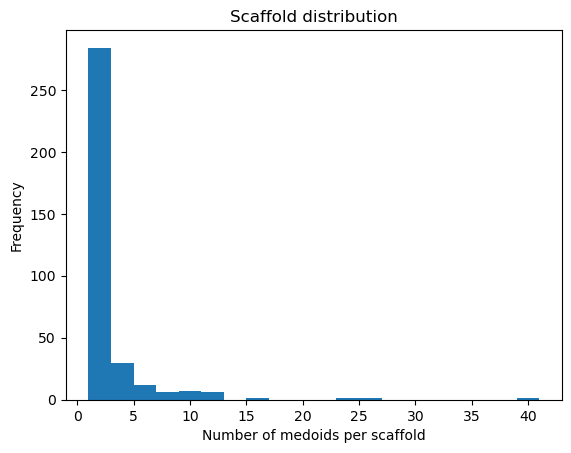

In [29]:
scaffold_counts = [len(v) for v in scaffold_map.values()]
plt.hist(scaffold_counts, bins=20)
plt.xlabel("Number of medoids per scaffold")
plt.ylabel("Frequency")
plt.title("Scaffold distribution")
plt.show()

In [31]:
per_scaffold_max = 5
final_seed = []
final_seed_pki = []

# Create SMILES -> fingerprint map
smiles_to_fp = {sm: fp for sm, fp in zip(smiles_list, fps)}

for scaf, members in scaffold_map.items():
    member_pki = scaffold_pki_map[scaf]
    
    # If small scaffold, keep all
    if len(members) <= per_scaffold_max:
        final_seed.extend(members)
        final_seed_pki.extend(member_pki)
        continue

    # Get fingerprints safely for these members
    scaffold_fps = [smiles_to_fp[m] for m in members if m in smiles_to_fp]

    # Cluster within scaffold
    sub_clusters = butina_cluster(scaffold_fps, cutoff=distance_cutoff)

    picked = []
    picked_pki = []

    for cl in sub_clusters:
        best_idx = medoid_of_cluster(cl, scaffold_fps)
        picked.append(members[best_idx])
        picked_pki.append(member_pki[best_idx])
        if len(picked) >= per_scaffold_max:
            break

    final_seed.extend(picked)
    final_seed_pki.extend(picked_pki)

print(f"Final seed size: {len(final_seed)}")

Final seed size: 588


In [32]:
seed_df = pd.DataFrame({'SMILES': final_seed, 'pKi': final_seed_pki})

In [34]:
seed_df.sort_values(by="pKi", ascending=False)

,SMILES,pKi
98,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,1.886057
99,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,1.795880
258,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,1.698970
249,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,1.522879
151,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN[C@H]...,1.522879
...,...,...
407,O=C1NCc2ccc(-c3ccc(Cl)cc3)cc21,-5.000000
410,O=C1CN=C(c2ccc(F)cc2)c2cn[nH]c2N1,-5.000000
443,Nc1ncnc2c1N=C(c1ccccc1)CCN2,-5.000000
389,O=c1[nH]c2ccc(Cl)cc2c2ncnn12,-5.000000


#### Trial 3

In [20]:
def _bits_to_rdkit(row, fp_cols):
    arr = np.asarray(row[fp_cols], dtype=int)
    bv = DataStructs.ExplicitBitVect(len(arr))
    for i, v in enumerate(arr):
        if v: bv.SetBit(i)
    return bv

def _morgan_from_smiles(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

def _ensure_fp(df, fp_prefix="FP_", smiles_col="Curated_SMILES"):
    fp_cols = [c for c in df.columns if c.startswith(fp_prefix)]
    if fp_cols:
        df = df.copy()
        df["fp"] = df.apply(lambda r: _bits_to_rdkit(r, fp_cols), axis=1)
        df["fp"] = df.apply(lambda r: _morgan_from_smiles(r[smiles_col]) if r["fp"] is None else r["fp"], axis=1)
    else:
        df = df.copy()
        df["fp"] = df[smiles_col].apply(_morgan_from_smiles)
    df = df[df["fp"].notna()].reset_index(drop=True)
    return df

In [21]:
def _tanimoto_dedup(df, thresh=0.9):
    kept_idx, kept_fps = [], []
    for i, fp in enumerate(df["fp"]):
        if not kept_fps:
            kept_idx.append(i)
            kept_fps.append(fp)
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, kept_fps)
        if max(sims) < thresh:
            kept_idx.append(i)
            kept_fps.append(fp)
    return df.iloc[kept_idx].reset_index(drop=True)

def _generic_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    generic = MurckoScaffold.MakeScaffoldGeneric(scaffold)
    return Chem.MolToSmiles(generic, isomericSmiles=False)

In [22]:
def _assign_singletons(df, groups, sim_thresh=0.60, min_target=3):
    mult = {s: idxs[:] for s, idxs in groups.items() if len(idxs) > 1}
    reps, reps_sc = [], []
    for sc, idxs in mult.items():
        best = max(idxs, key=lambda i: df.loc[i, "pKi_median"] if not pd.isna(df.loc[i, "pKi_median"]) else -1e9)
        reps.append(df.loc[best, "fp"])
        reps_sc.append(sc)
    for sc, idxs in [ (s, i) for s, i in groups.items() if len(i) <= 1 ]:
        i = idxs[0]
        if not reps: continue
        sims = DataStructs.BulkTanimotoSimilarity(df.loc[i,"fp"], reps)
        j = int(np.argmax(sims))
        best_sim = float(sims[j])
        target = reps_sc[j]
        if best_sim >= sim_thresh and len(mult[target]) >= min_target:
            mult[target].append(i)
        else:
            mult.setdefault(sc, []).append(i)
    return mult

def _scaffold_stats(df, groups):
    rows = []
    for sc, idxs in groups.items():
        pkis = df.loc[idxs, "pKi_median"].dropna().values
        rows.append((
            sc,
            len(idxs),
            float(np.median(pkis)) if pkis.size else np.nan,
            float(np.percentile(pkis, 75)) if pkis.size else np.nan
        ))
    return pd.DataFrame(rows, columns=["scaffold","n","median","q75"])


In [30]:
def _pick_medoids(df, groups, max_per_scaffold=4, divisor=15, alpha=0.7):
    chosen = []
    for sc, idxs in groups.items():
        k = max(1, min(max_per_scaffold, 1 + len(idxs)//divisor))
        pool = idxs.copy()
        for _ in range(min(k, len(pool))):
            fps = [df.loc[i, "fp"] for i in pool]
            pkis = np.array([df.loc[i, "pKi_median"] if not pd.isna(df.loc[i,"pKi_median"]) else -1e9 for i in pool], float)
            sim_mat = np.array([DataStructs.BulkTanimotoSimilarity(f, fps) for f in fps])
            avg_sim = sim_mat.mean(axis=1)
            pnorm = (pkis - pkis.min())/(pkis.max()-pkis.min()) if pkis.max()>pkis.min() else np.zeros_like(pkis)
            score = alpha*avg_sim + (1-alpha)*pnorm
            best = int(np.argmax(score))
            chosen_idx = pool[best]
            chosen.append(chosen_idx)
            pool.pop(best)
    return chosen

def _global_dedup_pki(df, idxs, max_sim=0.8, protected_idx=None):
    """pKi-aware global dedup with top-pKi protection"""
    if protected_idx is None: protected_idx = set()
    kept, kept_fps = [], []
    # first, always include protected molecules
    prot_list = [i for i in idxs if i in protected_idx]
    for i in prot_list:
        fp = df.loc[i,"fp"]
        kept.append(i)
        kept_fps.append(fp)
    # then process the rest by pKi descending
    remaining = [i for i in idxs if i not in protected_idx]
    remaining.sort(key=lambda i: df.loc[i,"pKi_median"], reverse=True)
    for i in remaining:
        fp = df.loc[i,"fp"]
        if not kept_fps:
            kept.append(i)
            kept_fps.append(fp)
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, kept_fps)
        if max(sims) < max_sim:
            kept.append(i)
            kept_fps.append(fp)
    return kept

def _hard_cutoff_balanced(df, idxs, N, max_per_scaffold=2, protected_idx=None):
    """
    Enforce an exact hard cutoff N while preserving scaffold balance.
    Protected compounds are always kept first.
    """
    if protected_idx is None:
        protected_idx = set()

    final = []
    scaffold_counts = {}

    # 1) Always include protected compounds first (in given order)
    for i in idxs:
        if i in protected_idx and i not in final:
            sc = df.loc[i, "scaffold"]
            scaffold_counts[sc] = scaffold_counts.get(sc, 0) + 1
            final.append(i)

    # 2) Fill remaining slots with scaffold cap enforced
    for i in idxs:
        if len(final) >= N:
            break
        if i in final:
            continue

        sc = df.loc[i, "scaffold"]
        if scaffold_counts.get(sc, 0) >= max_per_scaffold:
            continue

        final.append(i)
        scaffold_counts[sc] = scaffold_counts.get(sc, 0) + 1

    return final

In [31]:
def aggressive_pipeline_summary(df,
                             smiles_col="Curated_SMILES",
                             pki_col="pKi_median",
                             fp_prefix="FP_",
                             tanimoto_threshold=0.9,
                             sim_thresh_singleton=0.60,
                             min_target=3,
                             drop_bottom_frac=0.50,          # <--- increased from 0.20
                             max_per_scaffold=4,
                             divisor=15,
                             alpha=0.7,
                             global_max_sim=0.8):            # <--- lowered from 0.85
    # Step 1: ensure fingerprints
    df = _ensure_fp(df, fp_prefix=fp_prefix, smiles_col=smiles_col)
    df = _tanimoto_dedup(df, thresh=tanimoto_threshold)
    
    # Step 2: generate generic scaffolds
    df["scaffold"] = df[smiles_col].apply(_generic_scaffold)
    df = df[df["scaffold"].notna()].reset_index(drop=True)
    
    # Step 3: group & assign singletons
    groups = {}
    for i, sc in enumerate(df["scaffold"]): groups.setdefault(sc, []).append(i)
    groups = _assign_singletons(df, groups, sim_thresh_singleton, min_target)
    
    # Step 4: scaffold stats & remove bottom fraction
    stats = _scaffold_stats(df, groups)
    
    # --- new scoring: pKi-heavy + log(n), with alpha weighting ---
    stats["score"] = stats["q75"].fillna(-999)*0.7 + stats["median"].fillna(-999)*0.3
    stats = stats.sort_values("score", ascending=False).reset_index(drop=True)
    
    # Step 4b: identify protected top 10% pKi compounds
    pki_cutoff_protect = df[pki_col].quantile(0.90)
    protected_idx = set(df.index[df[pki_col] >= pki_cutoff_protect].tolist())
    
    n_drop = int(len(stats) * drop_bottom_frac)
    if n_drop >= len(stats):
        n_drop = len(stats) - 1
    keep_scaffolds = stats["scaffold"].tolist()[:-n_drop]  # top-scoring scaffolds
    protected_scaffolds = set(df.loc[list(protected_idx), "scaffold"])
    keep_scaffolds = set(keep_scaffolds).union(protected_scaffolds)
    groups = {s: idxs for s, idxs in groups.items() if s in keep_scaffolds}
    
    # Step 5: pick medoids
    medoids = _pick_medoids(df, groups, max_per_scaffold=max_per_scaffold, divisor=divisor, alpha=alpha)
    medoids = [i for i in medoids if df.loc[i,"scaffold"] in keep_scaffolds]
    
    # Step 6: sort by scaffold score & pKi safely
    ordered = sorted(
        medoids,
        key=lambda i: (
            stats.loc[stats["scaffold"]==df.loc[i,"scaffold"], "score"].values[0]
            if len(stats.loc[stats["scaffold"]==df.loc[i,"scaffold"], "score"]) > 0 else 0,
            df.loc[i, pki_col] if not pd.isna(df.loc[i,pki_col]) else -1
        ),
        reverse=True
    )
    
    # Step 7: global Tanimoto dedup with pKi-aware protection
    final_idxs = _global_dedup_pki(df, ordered, max_sim=global_max_sim, protected_idx=protected_idx)
    final_df = df.loc[final_idxs].reset_index(drop=True)
    
    # --- summary ---
    n_total = len(df)
    n_final = len(final_df)
    n_scaffolds = len(set(final_df["scaffold"]))
    print(f"Total molecules after FP/Tanimoto: {n_total}")
    print(f"Final molecules selected: {n_final}")
    print(f"Unique scaffolds in final set: {n_scaffolds}")
    
    return final_df, stats, {"final_n": n_final, "n_scaffolds": n_scaffolds}

In [26]:
final_df, stats_df, info = aggressive_pipeline_summary(jak2_compound_filtration)

Total molecules after FP/Tanimoto: 1560
Final molecules selected: 186
Unique scaffolds in final set: 166


#### Trial 4

In [35]:
def aggressive_pipeline_summary(df,
                             smiles_col="Curated_SMILES",
                             pki_col="pKi_median",
                             fp_prefix="FP_",
                             tanimoto_threshold=0.9,
                             sim_thresh_singleton=0.60,
                             min_target=3,
                             drop_bottom_frac=0.50,          # <--- increased from 0.20
                             max_per_scaffold=4,
                             divisor=15,
                             alpha=0.7,
                             global_max_sim=0.8):            # <--- lowered from 0.85
    # Step 1: ensure fingerprints
    df = _ensure_fp(df, fp_prefix=fp_prefix, smiles_col=smiles_col)
    df = _tanimoto_dedup(df, thresh=tanimoto_threshold)
    
    # Step 2: generate generic scaffolds
    df["scaffold"] = df[smiles_col].apply(_generic_scaffold)
    df = df[df["scaffold"].notna()].reset_index(drop=True)
    
    # Step 3: group & assign singletons
    groups = {}
    for i, sc in enumerate(df["scaffold"]): groups.setdefault(sc, []).append(i)
    groups = _assign_singletons(df, groups, sim_thresh_singleton, min_target)
    
    # Step 4: scaffold stats & remove bottom fraction
    stats = _scaffold_stats(df, groups)
    
    # --- new scoring: pKi-heavy + log(n), with alpha weighting ---
    stats["score"] = stats["q75"].fillna(-999)*0.7 + stats["median"].fillna(-999)*0.3
    stats = stats.sort_values("score", ascending=False).reset_index(drop=True)
    
    # Step 4b: identify protected top 10% pKi compounds
    pki_cutoff_protect = df[pki_col].quantile(0.90)
    protected_idx = set(df.index[df[pki_col] >= pki_cutoff_protect].tolist())
    
    n_drop = int(len(stats) * drop_bottom_frac)
    if n_drop >= len(stats):
        n_drop = len(stats) - 1
    keep_scaffolds = stats["scaffold"].tolist()[:-n_drop]  # top-scoring scaffolds
    protected_scaffolds = set(df.loc[list(protected_idx), "scaffold"])
    keep_scaffolds = set(keep_scaffolds).union(protected_scaffolds)
    groups = {s: idxs for s, idxs in groups.items() if s in keep_scaffolds}
    
    # Step 5: pick medoids
    medoids = _pick_medoids(df, groups, max_per_scaffold=max_per_scaffold, divisor=divisor, alpha=alpha)
    medoids = [i for i in medoids if df.loc[i,"scaffold"] in keep_scaffolds]
    
    # Step 6: sort by scaffold score & pKi safely
    ordered = sorted(
        medoids,
        key=lambda i: (
            stats.loc[stats["scaffold"]==df.loc[i,"scaffold"], "score"].values[0]
            if len(stats.loc[stats["scaffold"]==df.loc[i,"scaffold"], "score"]) > 0 else 0,
            df.loc[i, pki_col] if not pd.isna(df.loc[i,pki_col]) else -1
        ),
        reverse=True
    )
    
    # Step 7: global Tanimoto dedup with pKi-aware protection
    final_idxs = _global_dedup_pki(
    df, ordered, max_sim=global_max_sim, protected_idx=protected_idx
    )

    # Step 8: HARD CUTOFF (exact N)
    HARD_N = 100   # <-- choose your target size here

    final_idxs = _hard_cutoff_balanced(
        df,
        final_idxs,
        N=HARD_N,
        max_per_scaffold=max_per_scaffold,
        protected_idx=protected_idx
    )

    final_df = df.loc[final_idxs].reset_index(drop=True)
    
    # --- summary ---
    n_total = len(df)
    n_final = len(final_df)
    n_scaffolds = len(set(final_df["scaffold"]))
    print(f"Total molecules after FP/Tanimoto: {n_total}")
    print(f"Final molecules selected: {n_final}")
    print(f"Unique scaffolds in final set: {n_scaffolds}")
    
    return final_df, stats, {"final_n": n_final, "n_scaffolds": n_scaffolds}

In [36]:
final_df, stats_df, info = aggressive_pipeline_summary(jak2_compound_filtration)

Total molecules after FP/Tanimoto: 1560
Final molecules selected: 100
Unique scaffolds in final set: 84


In [37]:
final_df.to_csv("pre_loop_df", index=False)

In [83]:
pre_loop_df = pd.read_csv("pre_loop_df")

In [79]:
pre_loop_df = pd.read_csv("pre_loop_df")

## Compound Iteration V1

### Isoform and Ligand Preparation

In [15]:
def cif_to_pdbqt(cif_path: str, pdbqt_path: str, add_hydrogens: bool = True):
    """
    Convert a protein CIF file to PDBQT format optimized for AutoDock/Vina.

    Parameters
    ----------
    cif_path : str
        Input mmCIF file path
    pdbqt_path : str
        Output PDBQT file path
    add_hydrogens : bool
        Whether to add hydrogens to the structure (default: True)
    """

    # Step 1: Parse CIF
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("protein", cif_path)

    # Step 2: Save temporary PDB
    with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
        tmp_pdb_path = tmp.name

    try:
        io = PDBIO()
        io.set_structure(structure)
        io.save(tmp_pdb_path)

        # Step 3: Load PDB into Open Babel
        obConversion = openbabel.OBConversion()
        obConversion.SetInAndOutFormats("pdb", "pdbqt")

        mol = openbabel.OBMol()
        obConversion.ReadFile(mol, tmp_pdb_path)

        # Step 4: Optionally add hydrogens
        if add_hydrogens:
            mol.AddHydrogens()

        # Step 5: Skip Gasteiger charges for proteins (do NOT call ComputeCharges)

        # Step 6: Write PDBQT
        obConversion.WriteFile(mol, pdbqt_path)

    finally:
        os.remove(tmp_pdb_path)

In [21]:
cif_to_pdbqt("PDB Structures/CIF FILES/8S85_JAK1_Jh1_PDB.cif", "JAK1_PDBQT")
cif_to_pdbqt("PDB Structures/CIF FILES/6VNH_JAK2_Jh1_PDB.cif", "JAK2_PDBQT")
cif_to_pdbqt("PDB Structures/CIF FILES/3ZC6_JAK3_Jh1_PDB.cif", "JAK3_PDBQT")
cif_to_pdbqt("PDB Structures/CIF FILES/3NYX_Tyk2_Jh1_PDB.cif", "TYK2_PDBQT")

In [84]:
pre_loop_df = pre_loop_df.drop(columns=['Mol', 'MW', 'LogP', 'HBD', 'HBA', "RO5_violations", "fp", "scaffold"])

In [85]:
pre_loop_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.602060,0,1,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,10.522879,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...,10.698970,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CCC[C@@H](C...,9.259637,0,0,0,0,1,1,0,0,...,0,0,0,1,0,1,0,0,0,0
96,Cc1cc(Nc2nc(N[C@@H]3C[C@H]4CCC[C@@H](C3)N4S(=O...,9.259637,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
97,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
98,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [86]:
def process_single_smiles(smi, embed_seed=42, mmff_max_iters=2000):
    """Process a single SMILES and return an SDF string (robust version)."""
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            print(f"Invalid SMILES: {smi}")
            return None

        mol = Chem.AddHs(mol, addCoords=True)

        # 3D embedding
        params = AllChem.ETKDGv3()
        params.randomSeed = embed_seed
        params.useRandomCoords = False
        try:
            AllChem.EmbedMolecule(mol, params=params)
        except Exception:
            try:
                params2 = AllChem.ETKDG()
                params2.randomSeed = embed_seed + 1
                params2.useRandomCoords = True
                AllChem.EmbedMolecule(mol, params=params2)
            except Exception as e:
                print(f"Embedding failed for {smi}: {e}")
                return None

        if mol.GetNumConformers() == 0:
            print(f"No conformer for {smi}, skipping optimization")
            return None

        # Geometry optimization
        optimized = False
        try:
            if AllChem.MMFFHasAllMoleculeParams(mol):
                mmff_props = AllChem.MMFFGetMoleculeProperties(mol)
                AllChem.MMFFOptimizeMolecule(mol, mmff_props, maxIters=mmff_max_iters, confId=0)
                optimized = True
        except Exception:
            pass

        if not optimized:
            try:
                AllChem.UFFOptimizeMolecule(mol, maxIters=mmff_max_iters, confId=0)
            except Exception:
                print(f"Optimization skipped for {smi}")

        # Gasteiger charges
        try:
            rdPartialCharges.ComputeGasteigerCharges(mol)
        except Exception:
            pass

        # Write SDF string
        sio = StringIO()
        writer = Chem.SDWriter(sio)
        writer.write(mol)
        writer.close()

        return sio.getvalue()

    except Exception as e:
        print(f"Unexpected failure for {smi}: {e}")
        return None

In [87]:
def ligand_to_sdf(df: pd.DataFrame,
                  smiles_col: str,
                  out_col: str = "SDF",
                  embed_seed: int = 42,
                  mmff_max_iters: int = 2000,
                  n_workers: int = None):
    """
    Convert SMILES in a DataFrame column to 3D SDF strings using parallel processing.

    Args:
        df: pandas DataFrame containing SMILES
        smiles_col: name of the column containing SMILES strings
        out_col: name of the output column for SDF strings
        embed_seed: random seed for 3D embedding
        mmff_max_iters: maximum iterations for MMFF optimization
        n_workers: number of parallel processes (None = use os.cpu_count())

    Returns:
        A copy of the DataFrame with a new column containing SDF strings
    """
    df_out = df.copy()
    smiles_list = df_out[smiles_col].astype(str).tolist()
    results = [None] * len(smiles_list)

    # Parallel processing
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        future_to_index = {
            executor.submit(process_single_smiles, smi, embed_seed, mmff_max_iters): idx
            for idx, smi in enumerate(smiles_list)
        }

        for future in as_completed(future_to_index):
            idx = future_to_index[future]
            try:
                results[idx] = future.result()
            except Exception:
                results[idx] = None

    df_out[out_col] = results
    return df_out


In [88]:
pre_loop_df = ligand_to_sdf(pre_loop_df, 'Curated_SMILES')

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=8370) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


In [89]:
pre_loop_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023,SDF
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,\n RDKit 3D\n\n 79 84 0 0 0 0...
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,\n RDKit 3D\n\n 77 83 0 0 0 0...
2,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.602060,0,1,0,0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,\n RDKit 3D\n\n 79 84 0 0 0 0...
3,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,10.522879,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,\n RDKit 3D\n\n 77 83 0 0 0 0...
4,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...,10.698970,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,\n RDKit 3D\n\n 77 82 0 0 0 0...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CCC[C@@H](C...,9.259637,0,0,0,0,1,1,0,0,...,0,0,1,0,1,0,0,0,0,\n RDKit 3D\n\n 68 73 0 0 0 0...
96,Cc1cc(Nc2nc(N[C@@H]3C[C@H]4CCC[C@@H](C3)N4S(=O...,9.259637,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,\n RDKit 3D\n\n 64 69 0 0 0 0...
97,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,\n RDKit 3D\n\n 61 66 0 0 0 0...
98,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,\n RDKit 3D\n\n 61 66 0 0 0 0...


In [90]:
pre_loop_df.to_csv("sdf_pre_loop_df", index=False)

In [7]:
sdf_pre_loop_df = pd.read_csv("sdf_pre_loop_df")

In [11]:
def sdf_string_to_pdbqt(sdf_string: str) -> str:
    """
    Convert ligand stored as an SDF string into a PDBQT string
    using the OpenBabel Python API (no subprocess).
    """

    # --- Step 1: Read SDF string into an OBMol ---
    mol = openbabel.OBMol()

    conv = openbabel.OBConversion()
    conv.SetInFormat("sdf")

    success = conv.ReadString(mol, sdf_string)
    if not success:
        raise ValueError("Failed to parse SDF string with OpenBabel")

    # --- Step 2: Add hydrogens ---
    mol.AddHydrogens()

    # --- Step 3: Assign Gasteiger charges ---
    charge_model = openbabel.OBChargeModel.FindType("gasteiger")
    if charge_model is None:
        raise ValueError("Gasteiger charge model not found")

    charge_model.ComputeCharges(mol)

    # --- Step 4: Convert OBMol → PDBQT string ---
    conv_out = openbabel.OBConversion()
    conv_out.SetOutFormat("pdbqt")

    pdbqt_string = conv_out.WriteString(mol)

    return pdbqt_string

In [12]:
sdf_pre_loop_df["PDBQT"] = sdf_pre_loop_df["SDF"].apply(sdf_string_to_pdbqt)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/openbabel/__init__.py:14: UserWarning: "import openbabel" is deprecated, instead use "from openbabel import openbabel"
  warnings.warn('"import openbabel" is deprecated, instead use "from openbabel import openbabel"')


In [14]:
sdf_pre_loop_df.to_csv("pdbqt_pre_loop_df", index=False);

In [8]:
pdbqt_pre_loop_df = pd.read_csv("pdbqt_pre_loop_df")

### Docking Compounds

In [31]:
def list_ligands(cif_file):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("prot", cif_file)

    ligs = set()

    for model in structure:
        for chain in model:
            for res in chain:
                if res.id[0] != " ":  # hetero residue
                    ligs.add(res.get_resname())

    return ligs

print(list_ligands("PDB Structures/CIF FILES/8S85_JAK1_Jh1_PDB.cif"))
print(list_ligands("PDB Structures/CIF FILES/6VNH_JAK2_Jh1_PDB.cif"))
print(list_ligands("PDB Structures/CIF FILES/3ZC6_JAK3_Jh1_PDB.cif"))
print(list_ligands("PDB Structures/CIF FILES/3NYX_Tyk2_Jh1_PDB.cif"))

{'HOH', 'NA', 'PTR', 'A1H5R'}
{'XZS', 'PTR', 'HOH'}
{'CL', 'PEG', 'PTR', 'HOH', 'VFC', 'PG4'}
{'HOH', 'DTT', 'TZ1'}


In [8]:
!sudo yum install -y wget
!wget https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64
!chmod +x vina_1.2.5_linux_x86_64
!sudo mv vina_1.2.5_linux_x86_64 /usr/local/bin/vina

Loaded plugins: dkms-build-requires, extras_suggestions, kernel-livepatch,
              : langpacks, priorities, update-motd, versionlock
amzn2-core                                               | 3.6 kB     00:00     
amzn2extra-docker                                        | 2.9 kB     00:00     
amzn2extra-kernel-5.10                                   | 3.0 kB     00:00     
amzn2extra-livepatch                                     | 2.9 kB     00:00     
amzn2extra-lustre                                        | 2.5 kB     00:00     
centos-extras                                            | 2.9 kB     00:00     
copr:copr.fedorainfracloud.org:vbatts:shadow-utils-newxi | 3.3 kB     00:00     
https://download.docker.com/linux/centos/2/x86_64/stable/repodata/repomd.xml: [Errno 14] HTTPS Error 404 - Not Found
Trying other mirror.
nvidia-container-toolkit/x86_64/signature                |  833 B     00:00     
nvidia-container-toolkit/x86_64/signature                | 2.1 kB     00:02

In [9]:
def write_pdbqt_string(path: str, pdbqt_string: str) -> None:
    """Write PDBQT text string to file."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        f.write(pdbqt_string)

def pdbqt_to_pdb(pdbqt_path: str, pdb_out_path: str) -> None:
    """Convert pdbqt -> pdb using OpenBabel Python API."""
    conv = openbabel.OBConversion()
    ok = conv.SetInAndOutFormats("pdbqt", "pdb")
    if not ok:
        raise RuntimeError("OpenBabel: failed to set formats pdbqt->pdb")
    mol = openbabel.OBMol()
    if not conv.ReadFile(mol, pdbqt_path):
        raise RuntimeError(f"OpenBabel: failed to read {pdbqt_path}")
    if not conv.WriteFile(mol, pdb_out_path):
        raise RuntimeError(f"OpenBabel: failed to write {pdb_out_path}")
    if not os.path.exists(pdb_out_path):
        raise RuntimeError(f"Conversion didn't create expected file {pdb_out_path}")

def parse_vina_score_from_log(log_path: str) -> float:
    """Parse best (first) pose score from vina log; fallback to most negative float found."""
    if not os.path.exists(log_path):
        return None
    with open(log_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2 and parts[0] == "1":
                try:
                    return float(parts[1])
                except Exception:
                    pass
    # fallback: find floats and return minimum
    best = None
    with open(log_path, "r") as f:
        for line in f:
            for tok in line.split():
                try:
                    v = float(tok)
                    if best is None or v < best:
                        best = v
                except Exception:
                    pass
    return best

def merge_protein_ligand(protein_pdb: str, ligand_pdb: str, out_complex: str) -> None:
    """Append receptor PDB + ligand PDB into a combined complex PDB."""
    with open(out_complex, "w") as out:
        with open(protein_pdb, "r") as p:
            out.write(p.read())
            out.write("\n")
        with open(ligand_pdb, "r") as l:
            out.write(l.read())

def run_plip_on_complex_python(complex_pdb: str):
    """Run PLIP analysis via Python API and return interaction_sets dict."""
    pc = PDBComplex()
    pc.load_pdb(complex_pdb)
    pc.analyze()
    return pc.interaction_sets


def plip_interactions_to_binary_plif(interaction_sets: dict, target_residues: List[str]) -> Dict[str, int]:
    """
    Convert PLIP interaction_sets to a binary PLIF for target residues (e.g., "SER904").
    Returns dict mapping residue -> 0/1.
    """
    targets = [t.upper().replace(" ", "") for t in target_residues]
    plif = {t: 0 for t in targets}
    if not interaction_sets:
        return plif

    interacting = set()
    for lig_key, interactions in interaction_sets.items():
        # check common PLIP lists
        lists_to_check = [
            "hbonds_ligand", "hydrophobic_contacts", "pistacking",
            "saltbridges_ligand", "halogenbonds", "waterbridges", "metal_complex"
        ]
        for attr in lists_to_check:
            arr = getattr(interactions, attr, None)
            if arr:
                for entry in arr:
                    # PLIP entry objects often have .resnr and .restype
                    resnr = getattr(entry, "resnr", None)
                    restype = getattr(entry, "restype", None)
                    if resnr is None:
                        resnr = getattr(entry, "res_seq", None) or getattr(entry, "resid", None)
                    if restype is None:
                        restype = getattr(entry, "resname", None) or getattr(entry, "residue", None)
                    if restype and resnr:
                        label = f"{str(restype).upper()}{int(resnr)}"
                        interacting.add(label)

    for t in targets:
        if t in interacting:
            plif[t] = 1
    return plif

# ----------------- Vina wrapper -----------------

def dock_with_vina(ligand_pdbqt: str, receptor_pdbqt: str, out_pdbqt: str, log_path: str,
                   center: Tuple[float, float, float], size: Tuple[float, float, float],
                   exhaustiveness: int = 8) -> None:
    """Call Vina with string args. Assumes vina on PATH."""
    cx, cy, cz = center
    sx, sy, sz = size
    cmd = [
        "vina",
        "--receptor", receptor_pdbqt,
        "--ligand", ligand_pdbqt,
        "--center_x", str(cx),
        "--center_y", str(cy),
        "--center_z", str(cz),
        "--size_x", str(sx),
        "--size_y", str(sy),
        "--size_z", str(sz),
        "--exhaustiveness", str(exhaustiveness),
        "--out", out_pdbqt,
        "--log", log_path
    ]
    # ensure directories exist
    if os.path.dirname(out_pdbqt):
        os.makedirs(os.path.dirname(out_pdbqt), exist_ok=True)
    if os.path.dirname(log_path):
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
    subprocess.run(cmd, check=True)

# ----------------- Core per-pair processing (uses TemporaryDirectory) -----------------

def process_one_pair_tmp(ligand_id: str, ligand_pdbqt_string: str,
                         receptor_record: Dict[str, str],
                         target_residues: List[str],
                         docking_cfg: Dict) -> Dict:
    """
    Perform docking + PLIP for a single ligand x receptor inside a TemporaryDirectory.
    All intermediate files are created inside the tempdir and removed automatically.
    receptor_record: {"pdbqt": <path>, "pdb": <path>}
    docking_cfg: {"center": (x,y,z), "size": (sx,sy,sz), "exhaustiveness":int}
    Returns a result dict with vina_score and PLIF bits.
    """
    with tempfile.TemporaryDirectory(prefix=f"dock_{ligand_id}_") as tmpdir:
        # 1) write ligand pdbqt to temp file
        ligand_pdbqt_path = os.path.join(tmpdir, f"{ligand_id}.pdbqt")
        write_pdbqt_string(ligand_pdbqt_path, ligand_pdbqt_string)

        # 2) dock with Vina (outputs inside tmpdir)
        iso_name = os.path.splitext(os.path.basename(receptor_record["pdbqt"]))[0]
        out_pdbqt = os.path.join(tmpdir, f"{ligand_id}_{iso_name}_out.pdbqt")
        log_path = os.path.join(tmpdir, f"{ligand_id}_{iso_name}.log")

        dock_with_vina(
            ligand_pdbqt=ligand_pdbqt_path,
            receptor_pdbqt=receptor_record["pdbqt"],
            out_pdbqt=out_pdbqt,
            log_path=log_path,
            center=docking_cfg["center"],
            size=docking_cfg["size"],
            exhaustiveness=docking_cfg.get("exhaustiveness", 8)
        )

        # 3) parse vina score
        vina_score = parse_vina_score_from_log(log_path)

        # 4) convert docked ligand pdbqt -> pdb
        ligand_out_pdb = os.path.join(tmpdir, f"{ligand_id}_{iso_name}_out.pdb")
        pdbqt_to_pdb(out_pdbqt, ligand_out_pdb)

        # 5) merge receptor pdb + ligand pdb into complex file
        complex_pdb = os.path.join(tmpdir, f"{ligand_id}_{iso_name}_complex.pdb")
        merge_protein_ligand(receptor_record["pdb"], ligand_out_pdb, complex_pdb)

        # 6) run PLIP via Python API
        interactions = run_plip_on_complex_python(complex_pdb)

        # 7) extract binary PLIF for target residues
        plif = plip_interactions_to_binary_plif(interactions, target_residues)

        # build and return result (tmpdir and all files are removed when context ends)
        result = {"ligand_id": ligand_id, "isoform": iso_name, "vina_score": vina_score}
        result.update(plif)
        return result

def convert_receptors_to_temp_pdb(receptors_folder: str) -> Tuple[str, Dict[str, Dict[str, str]]]:
    """
    Convert all receptors (.pdbqt) in receptors_folder to PDB files in a TemporaryDirectory.
    Returns (tmpdir_path, receptor_map) where receptor_map: basename -> {"pdbqt":..., "pdb":...}.
    The returned tmpdir_path must be kept alive while you run the jobs (it is not auto-deleted here).
    """
    tmp_receptors_dir = tempfile.mkdtemp(prefix="receptors_")
    receptor_files = sorted(glob.glob(os.path.join(receptors_folder, "*.pdbqt")))
    if not receptor_files:
        raise FileNotFoundError(f"No receptor .pdbqt files found in {receptors_folder}")
    mapping = {}
    for r in receptor_files:
        base = os.path.splitext(os.path.basename(r))[0]
        out_pdb = os.path.join(tmp_receptors_dir, f"{base}.pdb")
        pdbqt_to_pdb(r, out_pdb)
        mapping[base] = {"pdbqt": r, "pdb": out_pdb}
    return tmp_receptors_dir, mapping

# ----------------- Top-level run_all using temporary files -----------------

def run_all_tmp(df: pd.DataFrame,
                ligand_id_col: str,
                pdbqt_col: str,
                receptors_folder: str,
                target_residues: List[str],
                docking_cfg: Dict,
                save_csv: str = None) -> pd.DataFrame:
    """
    Orchestrate docking + PLIP for all ligands x receptors.
    Uses temporary directories for per-pair intermediates and a temporary receptor cache.
    Returns results DataFrame.
    """
    # Convert receptors once into a temp dir (we will delete this folder at the end explicitly)
    receptor_tmpdir, receptor_map = convert_receptors_to_temp_pdb(receptors_folder)

    results = []
    receptor_items = sorted(receptor_map.items())

    total = len(df) * len(receptor_items)
    print(f"Running {total} docking jobs ({len(df)} ligands x {len(receptor_items)} receptors).")

    try:
        for idx, row in df.iterrows():
            ligand_id = str(row[ligand_id_col])
            pdbqt_string = row[pdbqt_col]
            for iso_name, rec_rec in receptor_items:
                try:
                    res = process_one_pair_tmp(
                        ligand_id=ligand_id,
                        ligand_pdbqt_string=pdbqt_string,
                        receptor_record=rec_rec,
                        target_residues=target_residues,
                        docking_cfg=docking_cfg
                    )
                    results.append(res)
                except Exception as e:
                    print(f"ERROR for {ligand_id} x {iso_name}: {e}")
                    fail_row = {"ligand_id": ligand_id, "isoform": iso_name, "vina_score": None}
                    for tr in [t.upper().replace(" ", "") for t in target_residues]:
                        fail_row[tr] = None
                    results.append(fail_row)
        res_df = pd.DataFrame(results)
        if save_csv:
            res_df.to_csv(save_csv, index=False)
        return res_df
    finally:
        # cleanup receptor temporary directory (remove converted receptor pdbs)
        try:
            shutil.rmtree(receptor_tmpdir)
        except Exception:
            pass

In [176]:
target_residues_map = {
    "JAK1": ["ARG879", "LEU891", "SER909", "SER961"],
    "JAK2": ["GLN853", "MET865", "LYS883", "TYR934"],
    "JAK3": ["SER826", "LEU838", "GLN856", "SER907"],
    "TYK2": ["ARG901", "LEU913", "ALA931", "LEU983"]
}

In [96]:
def get_ligand_centroid(cif_file, ligand_resname):
    """
    Compute centroid of a bound ligand in an mmCIF (.cif) receptor file.

    Parameters
    ----------
    cif_file : str
        Path to receptor .cif file
    ligand_resname : str
        Residue name of ligand (e.g. 'ATP', 'ADP', 'LIG')

    Returns
    -------
    center : tuple(float, float, float)
        Docking center coordinates (x, y, z)
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("receptor", cif_file)

    coords = []

    for model in structure:
        for chain in model:
            for residue in chain:

                # Ligands appear as hetero residues
                if residue.get_resname().strip() == ligand_resname:
                    for atom in residue:
                        coords.append(atom.coord)

    if len(coords) == 0:
        raise ValueError(
            f"No ligand '{ligand_resname}' found in {cif_file}"
        )

    coords = np.array(coords)

    # Centroid = mean of ligand atom coordinates
    centroid = coords.mean(axis=0)

    return tuple(centroid)


In [33]:
center_jak1 = get_ligand_centroid(cif_file="PDB Structures/CIF FILES/8S85_JAK1_Jh1_PDB.cif", ligand_resname="A1H5R")
print("Docking center", center_jak1)

center_jak2 = get_ligand_centroid(cif_file="PDB Structures/CIF FILES/6VNH_JAK2_Jh1_PDB.cif", ligand_resname="XZS")
print("Docking center", center_jak2)

center_jak3 = get_ligand_centroid(cif_file="PDB Structures/CIF FILES/3ZC6_JAK3_Jh1_PDB.cif", ligand_resname="VFC")
print("Docking center", center_jak3)

center_tyk2 = get_ligand_centroid(cif_file="PDB Structures/CIF FILES/3NYX_Tyk2_Jh1_PDB.cif", ligand_resname="TZ1")
print("Docking center", center_tyk2)

Docking center (np.float32(10.695751), np.float32(30.88385), np.float32(0.512175))
Docking center (np.float32(54.4646), np.float32(-15.138589), np.float32(8.880867))
Docking center (np.float32(0.8076449), np.float32(-0.3083268), np.float32(26.176697))
Docking center (np.float32(7.2102003), np.float32(9.348201), np.float32(21.48732))


In [45]:
docking_cfgs = {
    "JAK1": {
        "center": (10.695751, 30.88385, 0.512175),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    },
    "JAK2": {
        "center": (54.4646, -15.138589, 8.880867),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    },
    "JAK3": {
        "center": (0.8076449, -0.3083268, 26.176697),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    },
    "TYK2": {
        "center": (7.2102003, 9.348201, 21.48732),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    }
}

In [ ]:
results_df = run_all_tmp(
    df=df,
    ligand_id_col="smiles_hash",
    pdbqt_col="PDBQT",
    receptors_folder="PDB Structures/PDBQT FILES",
    target_residues=target_residues_map,
    docking_cfg=docking_cfgs,
    save_csv="results.csv"
)

In [14]:
def add_smiles_hash_column(
    df,
    smiles_col="Curated_SMILES",
    out_col="smiles_hash",
    algorithm="sha256"
):
    """
    Takes a DataFrame, hashes every SMILES string in `smiles_col`,
    and adds the result as a new column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe
    smiles_col : str
        Column containing preprocessed SMILES
    out_col : str
        Name of new hashed column
    algorithm : str
        Hash algorithm (default: sha256)

    Returns
    -------
    pandas.DataFrame
        DataFrame with new hash column added
    """

    def hash_smiles(smiles):
        return hashlib.new(algorithm, smiles.encode("utf-8")).hexdigest()

    df[out_col] = df[smiles_col].apply(hash_smiles)

    return df

In [15]:
hashed_pdbqt_pre_loop_df = add_smiles_hash_column(pdbqt_pre_loop_df)

In [13]:
hashed_pdbqt_pre_loop_df = pd.read_csv("hashed_pdbqt_pre_loop_df")

In [21]:
df = hashed_pdbqt_pre_loop_df.copy()

In [22]:
df = df.head(2)

In [23]:
df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023,SDF,PDBQT,smiles_hash
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,0,1,0,0,0,0,\n RDKit 3D\n\n 79 84 0 0 0 0...,REMARK Name = \nREMARK 13 active torsions:\n...,d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbd...
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,\n RDKit 3D\n\n 77 83 0 0 0 0...,REMARK Name = \nREMARK 10 active torsions:\n...,4ffba84640075cc66f9baab063323ac0a8c99d4b58463a...


## Compound Iteration V2

### Protein and Ligand Preparation

#### Protein Preparation: CIF --> PDBQT

In [89]:
import os
import subprocess
import tempfile
import sys
from pathlib import Path
from Bio.PDB import MMCIFParser, PDBIO, Select

In [93]:
# ============================================
# 1. CONFIGURATION & PATHS
# ============================================
# These paths are based on your SageMaker Conda environment
CONDA_BASE = Path("/home/ec2-user/anaconda3/envs/python3")
PREP_REC_SCRIPT = CONDA_BASE / "bin/prepare_receptor4.py"
MGL_PACKAGE_PATH = CONDA_BASE / "MGLToolsPckgs"

CIF_DIR = Path("CIF - Chimera")
OUTPUT_DIR = Path("CHIMERA_PDBQT_FINAL_VALIDATED")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ISOFORMS = {
    "JAK1": "JAK1_edited.cif",
    "JAK2": "JAK2_edited.cif",
    "JAK3": "JAK3_edited.cif",
    "TYK2": "TYK2_edited.cif"
}

# Residue handling
KEEP_HET_RESIDUES = {"PTR"}
KEEP_IONS = {"ZN", "MG", "MN", "FE", "CA", "K"}
REMOVE_EXPLICIT = {"HOH", "PEG", "PG4", "DTT"}

# ============================================
# 2. THE FIXERS (Sanitizer & Force-Mapper)
# ============================================

def sanitize_pdb_columns(pdb_path):
    """
    Reconstructs PDB lines with strict spacing to prevent HH1A1 column-shifting.
    Forces element symbols into columns 77-78 to help MGLTools.
    """
    with open(pdb_path, 'r') as f:
        lines = f.readlines()
    
    with open(pdb_path, 'w') as f:
        for line in lines:
            if line.startswith(("ATOM", "HETATM")):
                try:
                    # Extract raw fields via exact PDB column slicing
                    serial = line[6:11].strip()
                    name = line[12:16].strip()
                    resName = line[17:20].strip()
                    chainID = line[21].strip() or "A"
                    resSeq = line[22:26].strip()
                    x, y, z = line[30:38].strip(), line[38:46].strip(), line[46:54].strip()

                    # Fix leading numbers (e.g. 1HD2 -> HD21) and truncate
                    if name[0].isdigit(): name = name[1:] + name[0]
                    name = name[:4]

                    # Derive Element Symbol
                    potential_elem = name[:2].capitalize()
                    if potential_elem in ["Zn", "Mg", "Mn", "Fe", "Ca"]:
                        element = potential_elem
                    else:
                        element = "".join([c for c in name if c.isalpha()][:1])

                    # Rebuild line using strict PDB field widths
                    new_line = (
                        f"{line[:6]:<6}"         # Record name
                        f"{serial:>5} "          # Serial
                        f"{name:<4} "            # Atom Name
                        f"{resName:>3} "         # Residue Name
                        f"{chainID:1}"           # Chain
                        f"{resSeq:>4}    "       # Sequence
                        f"{float(x):8.3f}"       # X
                        f"{float(y):8.3f}"       # Y
                        f"{float(z):8.3f}"       # Z
                        f"{' ' * 22}"            # Padding
                        f"{element:>2}"          # Element Symbol (Col 77-78)
                    )
                    f.write(new_line + "\n")
                except:
                    f.write(line)
            else:
                f.write(line)

def force_assign_types(pdbqt_path: Path):
    """
    Final pass: Replaces 'NA' types with standard AutoDock types 
    based on the element symbol column. Fixes the '449 atoms are NA' error.
    """
    type_map = {
        "C": "C ", "N": "N ", "O": "OA", "S": "SA", 
        "P": "P ", "H": "HD", "F": "F ", "CL": "Cl",
        "BR": "Br", "I": "I ", "ZN": "Zn", "MG": "Mg"
    }
    
    with open(pdbqt_path, 'r') as f:
        lines = f.readlines()
    
    with open(pdbqt_path, 'w') as f:
        for line in lines:
            if line.startswith(("ATOM", "HETATM")):
                # Check AutoDock Type column (77-79)
                atom_type = line[77:79].strip()
                if atom_type == "NA" or not atom_type:
                    # Fallback to Element Symbol column (also 77-79 in PDBQT)
                    element = line[77:79].strip().upper()
                    new_type = type_map.get(element, "C ")
                    line = line[:77] + f"{new_type:<2}" + line[79:]
            f.write(line)

# ============================================
# 3. VALIDATOR & UTILITIES
# ============================================

def enhanced_validator(pdbqt_path: Path):
    """Checks for column alignment, total charge, and atom-type integrity."""
    total_charge, line_count = 0.0, 0
    has_hydrogens, unassigned_types = False, 0
    
    with open(pdbqt_path, 'r') as f:
        for line_num, line in enumerate(f, 1):
            if line.startswith(("ATOM", "HETATM")):
                line_count += 1
                try:
                    # Column slice test
                    x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
                    charge = float(line[70:76])
                    atom_type = line[77:79].strip()
                    
                    total_charge += charge
                    if atom_type in ["HD", "H"]: has_hydrogens = True
                    if atom_type == "NA" or not atom_type: unassigned_types += 1
                except ValueError:
                    return False, f"Line {line_num}: Column alignment error."

    if line_count == 0: return False, "File is empty."
    if not has_hydrogens: return False, "Missing hydrogens."
    if unassigned_types > 0: return False, f"{unassigned_types} atoms are 'NA'."
    
    return True, f"Charge: {total_charge:.2f} | Atoms: {line_count}"

def run_cmd(cmd):
    env = os.environ.copy()
    env["PYTHONPATH"] = f"{MGL_PACKAGE_PATH}:{env.get('PYTHONPATH', '')}"
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, env=env)
    if result.returncode != 0: raise RuntimeError(result.stderr)
    return result.stdout

class CleanProteinSelect(Select):
    def accept_residue(self, residue):
        resname = residue.get_resname().strip().upper()
        if residue.id[0] == " ": return 1 
        if resname in REMOVE_EXPLICIT: return 0
        return 1 if (resname in KEEP_HET_RESIDUES or resname in KEEP_IONS) else 0

# ============================================
# 4. MASTER PROCESS
# ============================================

def prepare_isoform(isoform_name):
    cif_path = CIF_DIR / ISOFORMS[isoform_name]
    if not cif_path.exists(): return

    output_pdbqt = OUTPUT_DIR / f"{isoform_name}_chimera.pdbqt"
    
    # Step A: Clean CIF -> PDB
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure(isoform_name, str(cif_path))
    fd, tmp_path = tempfile.mkstemp(suffix=".pdb"); os.close(fd)
    tmp_path = Path(tmp_path)
    
    io = PDBIO()
    io.set_structure(structure)
    io.save(str(tmp_path), CleanProteinSelect())
    
    try:
        # Step B: Advanced Sanitization
        sanitize_pdb_columns(tmp_path)
        
        # Step C: MGLTools Conversion
        print(f"[>] Converting {isoform_name}...")
        cmd = ["python", str(PREP_REC_SCRIPT), "-r", str(tmp_path), "-o", str(output_pdbqt), 
               "-A", "checkhydrogens", "-U", "nphs_lps_waters", "-e"]
        run_cmd(cmd)
        
        # Step D: Force Type Mapping (The Final Fix for 'NA' Types)
        force_assign_types(output_pdbqt)
        
        # Step E: Validation
        success, info = enhanced_validator(output_pdbqt)
        if success:
            print(f"[P] PASSED: {isoform_name} ({info})")
        else:
            print(f"[!] FAILED: {isoform_name} -> {info}")
            
    except Exception as e:
        print(f"[!] ERROR: {isoform_name} -> {e}")
    finally:
        if tmp_path.exists(): tmp_path.unlink()

In [94]:
if __name__ == "__main__":
    print(f"Starting Final JAK Preparation Pipeline\n" + "="*55)
    for isoform in ISOFORMS:
        prepare_isoform(isoform)
    print("="*55 + "\nPipeline Complete.")

Starting Final JAK Preparation Pipeline
[>] Converting JAK1...
[P] PASSED: JAK1 (Charge: 6.05 | Atoms: 2312)
[>] Converting JAK2...
[P] PASSED: JAK2 (Charge: -9.00 | Atoms: 2365)
[>] Converting JAK3...
[P] PASSED: JAK3 (Charge: -12.93 | Atoms: 2272)
[>] Converting TYK2...
[P] PASSED: TYK2 (Charge: -8.03 | Atoms: 2305)
Pipeline Complete.


In [97]:
center_jak1 = get_ligand_centroid(cif_file="CIF - Chimera/JAK1_edited.cif", ligand_resname="A1H5R")
print("Docking center", center_jak1)

center_jak2 = get_ligand_centroid(cif_file="CIF - Chimera/JAK2_edited.cif", ligand_resname="XZS")
print("Docking center", center_jak2)

center_jak3 = get_ligand_centroid(cif_file="CIF - Chimera/JAK3_edited.cif", ligand_resname="VFC")
print("Docking center", center_jak3)

center_tyk2 = get_ligand_centroid(cif_file="CIF - Chimera/TYK2_edited.cif", ligand_resname="OVI")
print("Docking center", center_tyk2)

Docking center (np.float32(14.796501), np.float32(4.6253996), np.float32(0.35870004))
Docking center (np.float32(54.40922), np.float32(-9.629999), np.float32(29.953173))
Docking center (np.float32(11.589486), np.float32(-1.603909), np.float32(44.04805))
Docking center (np.float32(6.8339353), np.float32(9.76929), np.float32(-17.908743))


#### Ligand Preparation: SMILES --> PDBQT

In [46]:
pre_loop_df = pd.read_csv("pre_loop_df")

In [47]:
pre_loop_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1022,FP_1023,Mol,MW,LogP,HBD,HBA,RO5_violations,fp,scaffold
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974740>,559.690,4.32470,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9971f50>,557.674,4.07870,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...
2,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.602060,0,1,0,0,1,0,1,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974580>,559.690,4.32630,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)...
3,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,10.522879,0,0,0,0,1,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974200>,557.674,4.08030,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...
4,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...,10.698970,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974270>,561.662,2.90860,4,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CCC[C@@H](C...,9.259637,0,0,0,0,1,1,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4b920>,517.659,4.73232,3,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(CC1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3...
96,Cc1cc(Nc2nc(N[C@@H]3C[C@H]4CCC[C@@H](C3)N4S(=O...,9.259637,0,0,0,0,1,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd21620>,522.610,4.12532,3,8,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(C1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3C...
97,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4bf40>,453.550,4.65262,3,6,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1C2CCC1CC(CC1CC(CC3CCCC3)CC3CCCCC...
98,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd20ac0>,440.555,4.40742,3,7,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,C1CCC(CC2C3CCC2CC(CC2CC(CC4CCCC4)CC4CCCCC42)C3...


In [48]:


# -------------------------------
# HELPER: Generate 3D conformer
# -------------------------------
def generate_3d_conformer(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    
    mol = Chem.AddHs(mol)
    
    # Try MMFF94 embedding
    if AllChem.EmbedMolecule(mol, randomSeed=0xf00d) != 0:
        # Fallback to ETKDG + UFF
        if AllChem.EmbedMolecule(mol, AllChem.ETKDG()) != 0:
            raise RuntimeError("Failed to generate 3D conformer")
    
    # Energy minimize
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        AllChem.UFFOptimizeMolecule(mol)
    
    return mol

# -------------------------------
# HELPER: Convert RDKit Mol → PDBQT text
# -------------------------------
def rdkit_to_pdbqt_text(mol):
    # Write temporary PDB
    with tempfile.NamedTemporaryFile(suffix=".pdb", delete=False) as tmp:
        pdb_path = tmp.name
    
    w = Chem.rdmolfiles.PDBWriter(pdb_path)
    w.write(mol)
    w.close()
    
    # Convert PDB → PDBQT using OpenBabel in-memory
    obConversion = openbabel.OBConversion()
    obConversion.SetInAndOutFormats("pdb", "pdbqt")
    
    obMol = openbabel.OBMol()
    if not obConversion.ReadFile(obMol, pdb_path):
        os.remove(pdb_path)
        raise RuntimeError("Failed to read temporary PDB")
    
    # Add hydrogens
    obMol.AddHydrogens()
    
    # Write PDBQT to string
    pdbqt_path = pdb_path + ".pdbqt"
    if not obConversion.WriteFile(obMol, pdbqt_path):
        os.remove(pdb_path)
        raise RuntimeError("Failed to write PDBQT")
    
    # Read PDBQT text
    with open(pdbqt_path, "r") as f:
        pdbqt_text = f.read()
    
    # Cleanup temp files
    os.remove(pdb_path)
    os.remove(pdbqt_path)
    
    return pdbqt_text

# -------------------------------
# MASTER FUNCTION — Prepare Ligand
# -------------------------------
def prepare_ligand(smiles: str):
    """
    Full ligand pipeline:
    SMILES → 3D conformer → PDBQT (text)
    """
    mol3d = generate_3d_conformer(smiles)
    pdbqt_text = rdkit_to_pdbqt_text(mol3d)
    return pdbqt_text

In [49]:
pre_loop_df["PDBQT"] = pre_loop_df["Curated_SMILES"].apply(prepare_ligand)

print(pre_loop_df.head())

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/openbabel/__init__.py:14: UserWarning: "import openbabel" is deprecated, instead use "from openbabel import openbabel"
  warnings.warn('"import openbabel" is deprecated, instead use "from openbabel import openbabel"')


                                      Curated_SMILES  pKi_median  FP_0  FP_1  \
0  CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...   10.886057     0     1   
1  CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...   10.698970     0     0   
2  CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...   10.602060     0     1   
3  CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...   10.522879     0     0   
4  CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...   10.698970     0     0   

   FP_2  FP_3  FP_4  FP_5  FP_6  FP_7  ...  FP_1023  \
0     0     0     0     0     1     0  ...        0   
1     0     0     0     0     0     0  ...        0   
2     0     0     1     0     1     0  ...        0   
3     0     0     1     0     0     0  ...        0   
4     0     0     0     0     0     0  ...        0   

                                                Mol       MW    LogP  HBD  \
0  <rdkit.Chem.rdchem.Mol object at 0x7f41e9974740>  559.690  4.3247    3   
1  <rdkit.Chem.rdchem.Mol object a

/tmp/ipykernel_10159/2815201657.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pre_loop_df["PDBQT"] = pre_loop_df["Curated_SMILES"].apply(prepare_ligand)


In [50]:
pre_loop_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1023,Mol,MW,LogP,HBD,HBA,RO5_violations,fp,scaffold,PDBQT
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974740>,559.690,4.32470,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1,REMARK Name = /tmp/tmpsbe63qh_.pdb\nREMARK 1...
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9971f50>,557.674,4.07870,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...,REMARK Name = /tmp/tmpesrxn4sx.pdb\nREMARK 1...
2,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.602060,0,1,0,0,1,0,1,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974580>,559.690,4.32630,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)...,REMARK Name = /tmp/tmp5bn3akvy.pdb\nREMARK 1...
3,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,10.522879,0,0,0,0,1,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974200>,557.674,4.08030,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...,REMARK Name = /tmp/tmp0jof7b53.pdb\nREMARK 9...
4,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...,10.698970,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974270>,561.662,2.90860,4,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)C...,REMARK Name = /tmp/tmpndlb1bdw.pdb\nREMARK 1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CCC[C@@H](C...,9.259637,0,0,0,0,1,1,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4b920>,517.659,4.73232,3,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(CC1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3...,REMARK Name = /tmp/tmp30clgsmz.pdb\nREMARK 6...
96,Cc1cc(Nc2nc(N[C@@H]3C[C@H]4CCC[C@@H](C3)N4S(=O...,9.259637,0,0,0,0,1,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd21620>,522.610,4.12532,3,8,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(C1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3C...,REMARK Name = /tmp/tmp4fxvuxzk.pdb\nREMARK 5...
97,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4bf40>,453.550,4.65262,3,6,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1C2CCC1CC(CC1CC(CC3CCCC3)CC3CCCCC...,REMARK Name = /tmp/tmp6tjvv118.pdb\nREMARK 4...
98,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd20ac0>,440.555,4.40742,3,7,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,C1CCC(CC2C3CCC2CC(CC2CC(CC4CCCC4)CC4CCCCC42)C3...,REMARK Name = /tmp/tmp5lxusygw.pdb\nREMARK 5...


### Docking and PLIP Analysis

In [102]:
docking_cfgs = {
    "JAK1": {
        "center": (14.796501, 4.6253996, 0.35870004),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    },
    "JAK2": {
        "center": (54.40922, -9.629999, 29.953173),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    },
    "JAK3": {
        "center": (11.589486, -1.603909, 44.04805),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    },
    "TYK2": {
        "center": (6.8339353, 9.76929, -17.908743),
        "size": (20, 20, 20),
        "exhaustiveness": 8
    }
}

In [103]:
target_residues_map = {
    "JAK1": ["ARG879", "LEU891", "SER909", "SER961", "LYS1154"],
    "JAK2": ["GLN853", "MET865", "LYS883", "TYR934", "GLY1132"],
    "JAK3": ["SER826", "LEU838", "GLN856", "SER907", "SER1100"],
    "TYK2": ["ARG901", "LEU913", "ALA931", "LEU983", "HIS1178"]
}

In [115]:
!mkdir -p ~/bin

!wget -O ~/bin/vina \
https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64

!chmod +x ~/bin/vina

--2026-02-22 23:02:19--  https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/258054635/b208f84f-df05-4575-9991-2190698c7914?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-23T00%3A01%3A28Z&rscd=attachment%3B+filename%3Dvina_1.2.5_linux_x86_64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-22T23%3A01%3A18Z&ske=2026-02-23T00%3A01%3A28Z&sks=b&skv=2018-11-09&sig=N7FnejUVrUEZCRHom%2FqG%2BRhiJpqUvBk44qO16SItMp8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MTgwMTYzOSwibmJmIjoxNzcxODAxMzM5LCJwYXRoIjoicmVsZWF

In [120]:
VINA_BIN = os.path.expanduser("~/bin/vina")

In [53]:
!ls -l ~/bin/vina
!~/bin/vina --version


-rwxrwxr-x 1 ec2-user ec2-user 4089576 Jun 16  2023 /home/ec2-user/bin/vina
AutoDock Vina v1.2.5


In [54]:
pre_loop_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1023,Mol,MW,LogP,HBD,HBA,RO5_violations,fp,scaffold,PDBQT
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974740>,559.690,4.32470,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1,REMARK Name = /tmp/tmpsbe63qh_.pdb\nREMARK 1...
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9971f50>,557.674,4.07870,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...,REMARK Name = /tmp/tmpesrxn4sx.pdb\nREMARK 1...
2,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.602060,0,1,0,0,1,0,1,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974580>,559.690,4.32630,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)...,REMARK Name = /tmp/tmp5bn3akvy.pdb\nREMARK 1...
3,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,10.522879,0,0,0,0,1,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974200>,557.674,4.08030,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...,REMARK Name = /tmp/tmp0jof7b53.pdb\nREMARK 9...
4,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...,10.698970,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974270>,561.662,2.90860,4,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)C...,REMARK Name = /tmp/tmpndlb1bdw.pdb\nREMARK 1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CCC[C@@H](C...,9.259637,0,0,0,0,1,1,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4b920>,517.659,4.73232,3,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(CC1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3...,REMARK Name = /tmp/tmp30clgsmz.pdb\nREMARK 6...
96,Cc1cc(Nc2nc(N[C@@H]3C[C@H]4CCC[C@@H](C3)N4S(=O...,9.259637,0,0,0,0,1,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd21620>,522.610,4.12532,3,8,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(C1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3C...,REMARK Name = /tmp/tmp4fxvuxzk.pdb\nREMARK 5...
97,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4bf40>,453.550,4.65262,3,6,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1C2CCC1CC(CC1CC(CC3CCCC3)CC3CCCCC...,REMARK Name = /tmp/tmp6tjvv118.pdb\nREMARK 4...
98,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd20ac0>,440.555,4.40742,3,7,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,C1CCC(CC2C3CCC2CC(CC2CC(CC4CCCC4)CC4CCCCC42)C3...,REMARK Name = /tmp/tmp5lxusygw.pdb\nREMARK 5...


In [55]:
def add_smiles_hash_column(
    df,
    smiles_col="Curated_SMILES",
    out_col="smiles_hash",
    algorithm="sha256"
):
    """
    Takes a DataFrame, hashes every SMILES string in `smiles_col`,
    and adds the result as a new column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe
    smiles_col : str
        Column containing preprocessed SMILES
    out_col : str
        Name of new hashed column
    algorithm : str
        Hash algorithm (default: sha256)

    Returns
    -------
    pandas.DataFrame
        DataFrame with new hash column added
    """

    def hash_smiles(smiles):
        return hashlib.new(algorithm, smiles.encode("utf-8")).hexdigest()

    df[out_col] = df[smiles_col].apply(hash_smiles)

    return df

In [56]:
hashed_pre_loop_df = add_smiles_hash_column(pre_loop_df)

/tmp/ipykernel_10159/2169816206.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df[smiles_col].apply(hash_smiles)


In [57]:
df = hashed_pre_loop_df.head(1)

In [58]:
df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,Mol,MW,LogP,HBD,HBA,RO5_violations,fp,scaffold,PDBQT,smiles_hash
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974740>,559.69,4.3247,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1,REMARK Name = /tmp/tmpsbe63qh_.pdb\nREMARK 1...,d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbd...


In [30]:
def cif_to_pdb(cif_file, pdb_file):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("receptor", cif_file)

    io = PDBIO()
    io.set_structure(structure)
    io.save(pdb_file)

# Example
cif_to_pdb("PDB Structures/CIF FILES/8S85_JAK1_Jh1_PDB.cif", "JAK1.pdb")
cif_to_pdb("PDB Structures/CIF FILES/6VNH_JAK2_Jh1_PDB.cif", "JAK2.pdb")
cif_to_pdb("PDB Structures/CIF FILES/3ZC6_JAK3_Jh1_PDB.cif", "JAK3.pdb")
cif_to_pdb("PDB Structures/CIF FILES/3NYX_Tyk2_Jh1_PDB.cif", "TYK2.pdb")

In [131]:
# -------------------------------
# Live timing context manager
# -------------------------------
def timed_step(step_name: str):
    class Timer:
        def __enter__(self):
            print(f"\n⏳ Running: {step_name} ...", flush=True)
            self.start = time.perf_counter()
            return self
        def __exit__(self, exc_type, exc_val, exc_tb):
            elapsed = time.perf_counter() - self.start
            print(f"✅ Finished: {step_name} ({elapsed:.2f} sec)", flush=True)
    return Timer()

# -------------------------------
# PyMOL-only PDBQT -> PDB conversion
# -------------------------------
def pdbqt_to_pdb_pymol(pdbqt_path: str, pdb_out_path: str, timeout: int = 60) -> None:
    """
    Convert a PDBQT to PDB using PyMOL headless CLI:
      pymol -cq input.pdbqt -o output.pdb
    Raises RuntimeError with useful diagnostics if conversion fails.
    """
    if not shutil.which("pymol"):
        raise RuntimeError("PyMOL not found on PATH. Install headless PyMOL (pymol-open-source).")

    cmd = ["pymol", "-cq", pdbqt_path, "-o", pdb_out_path]
    try:
        with timed_step(f"PyMOL convert {os.path.basename(pdbqt_path)}"):
            subprocess.run(cmd, check=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        raise RuntimeError(f"PyMOL conversion timed out for {pdbqt_path}")
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"PyMOL conversion failed for {pdbqt_path} (rc={e.returncode}). STDERR/STDOUT unavailable in this call.")

    if not os.path.exists(pdb_out_path):
        raise RuntimeError(f"PyMOL claimed success but output missing: {pdb_out_path}")

# -------------------------------
# Run PLIP in isolated subprocess and return simple mapping
# -------------------------------
def run_plip_subprocess_and_get_interactions(complex_pdb: str, timeout: int = 120) -> Dict[str, List[str]]:
    """
    Runs a transient Python subprocess that loads PLIP, analyzes complex_pdb,
    and prints JSON mapping ligand_key -> list of interacting residue labels (e.g., "ARG879").
    Returns that mapping as dict.
    """
    script = r'''
import sys, json
from plip.structure.preparation import PDBComplex
fn = sys.argv[1]
pc = PDBComplex()
pc.load_pdb(fn)
pc.analyze()
out = {}
attrs = ["hbonds_ligand","hydrophobic_contacts","pistacking","saltbridges_ligand",
         "halogenbonds","waterbridges","metal_complex","hbonds","saltbridges","metalcontacts"]
for lig_key, interactions in pc.interaction_sets.items():
    interacting = set()
    for attr in attrs:
        arr = getattr(interactions, attr, None)
        if arr:
            for entry in arr:
                resnr = getattr(entry, "resnr", None)
                restype = getattr(entry, "restype", None)
                if resnr is None:
                    resnr = getattr(entry, "res_seq", None) or getattr(entry, "resid", None)
                if restype is None:
                    restype = getattr(entry, "resname", None) or getattr(entry, "residue", None)
                if restype and resnr:
                    try:
                        interacting.add(f"{str(restype).upper()}{int(resnr)}")
                    except Exception:
                        pass
    out[lig_key] = sorted(list(interacting))
print(json.dumps(out))
'''
    fd, script_path = tempfile.mkstemp(prefix="plip_run_", suffix=".py")
    os.close(fd)
    try:
        with open(script_path, "w") as fh:
            fh.write(script)
        proc = subprocess.run(["python3", script_path, complex_pdb],
                              stdout=subprocess.PIPE, stderr=subprocess.PIPE,
                              text=True, timeout=timeout)
        if proc.returncode != 0:
            raise RuntimeError(f"PLIP subprocess failed (rc={proc.returncode}). STDERR:\n{proc.stderr}")
        return json.loads(proc.stdout)
    finally:
        try:
            os.remove(script_path)
        except Exception:
            pass

# -------------------------------
# Parse Vina log (unchanged)
# -------------------------------
def parse_vina_score_from_log(log_path: str) -> Optional[float]:
    if not os.path.exists(log_path):
        return None
    with open(log_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2 and parts[0] == "1":
                try:
                    return float(parts[1])
                except Exception:
                    pass
    # fallback: find floats and return minimum
    best = None
    with open(log_path, "r") as f:
        for line in f:
            for tok in line.split():
                try:
                    v = float(tok)
                    if best is None or v < best:
                        best = v
                except Exception:
                    pass
    return best

# -------------------------------
# Vina wrapper (with cpu & timeout)
# -------------------------------
def dock_with_vina(ligand_pdbqt: str, receptor_pdbqt: str, out_pdbqt: str, log_path: str,
                   center: Tuple[float, float, float], size: Tuple[float, float, float],
                   exhaustiveness: int = 8, cpu: int = 1, timeout: int = 300) -> None:
    if not os.path.exists(VINA_BIN):
        raise RuntimeError(f"Vina binary not found at {VINA_BIN}")

    cx, cy, cz = center
    sx, sy, sz = size

    cmd = [
        VINA_BIN,
        "--receptor", receptor_pdbqt,
        "--ligand", ligand_pdbqt,
        "--out", out_pdbqt,
        #"--log", log_path,
        "--center_x", str(cx),
        "--center_y", str(cy),
        "--center_z", str(cz),
        "--size_x", str(sx),
        "--size_y", str(sy),
        "--size_z", str(sz),
        "--exhaustiveness", str(exhaustiveness),
        "--cpu", str(cpu)
    ]

    subprocess.run(cmd, check=True, timeout=timeout)

# -------------------------------
# Merge protein + ligand
# -------------------------------
def merge_protein_ligand(protein_pdb: str, ligand_pdb: str, out_complex: str) -> None:
    with open(out_complex, "w") as out:
        with open(protein_pdb, "r") as p:
            out.write(p.read())
            out.write("\n")
        with open(ligand_pdb, "r") as l:
            out.write(l.read())

# -------------------------------
# Per-pair sequential pipeline (uses PyMOL for ligand pose conversion)
# -------------------------------
def process_one_pair_tmp(ligand_id: str, ligand_pdbqt_string: str,
                         receptor_record: Dict[str, str],
                         target_residues: List[str],
                         docking_cfg: Dict,
                         cpu_per_vina: int = 1) -> Dict:
    """
    Sequential job: docks ligand -> converts ligand pose with PyMOL -> merges with receptor.pdb -> PLIP
    receptor_record: {"pdbqt": <path>, "pdb": <path>}
    """
    with tempfile.TemporaryDirectory(prefix=f"dock_{ligand_id}_") as tmpdir:
        # 1) write ligand pdbqt to temp file
        with timed_step(f"Write ligand PDBQT ({ligand_id})"):
            ligand_pdbqt_path = os.path.join(tmpdir, f"{ligand_id}.pdbqt")
            os.makedirs(os.path.dirname(ligand_pdbqt_path) or ".", exist_ok=True)
            with open(ligand_pdbqt_path, "w") as f:
                f.write(ligand_pdbqt_string)

        # 2) dock with Vina
        iso_name = os.path.splitext(os.path.basename(receptor_record["pdbqt"]))[0]
        out_pdbqt = os.path.join(tmpdir, f"{ligand_id}_{iso_name}_out.pdbqt")
        log_path = os.path.join(tmpdir, f"{ligand_id}_{iso_name}.log")
        with timed_step(f"Vina docking ({ligand_id} → {iso_name})"):
            dock_with_vina(
                ligand_pdbqt=ligand_pdbqt_path,
                receptor_pdbqt=receptor_record["pdbqt"],
                out_pdbqt=out_pdbqt,
                log_path=log_path,
                center=docking_cfg["center"],
                size=docking_cfg["size"],
                exhaustiveness=docking_cfg.get("exhaustiveness", 8),
                cpu=cpu_per_vina,
                timeout=docking_cfg.get("timeout", 300)
            )

        # 3) parse vina score
        with timed_step("Parse Vina score"):
            vina_score = parse_vina_score_from_log(log_path)

        # 4) convert docked ligand pdbqt -> pdb (PyMOL)
        ligand_out_pdb = os.path.join(tmpdir, f"{ligand_id}_{iso_name}_out.pdb")
        with timed_step("Convert docked ligand PDBQT → PDB (PyMOL)"):
            pdbqt_to_pdb_pymol(out_pdbqt, ligand_out_pdb, timeout=60)

        # 5) merge receptor pdb + ligand pdb into complex file
        complex_pdb = os.path.join(tmpdir, f"{ligand_id}_{iso_name}_complex.pdb")
        with timed_step("Merge receptor + ligand into complex PDB"):
            merge_protein_ligand(receptor_record["pdb"], ligand_out_pdb, complex_pdb)

        # 6) run PLIP via subprocess
        with timed_step("Run PLIP (isolated subprocess)"):
            plip_raw = run_plip_subprocess_and_get_interactions(complex_pdb, timeout=120)

        # 7) binary PLIF
        with timed_step("Extract binary PLIF"):
            plif = plip_interactions_to_binary_plif(plip_raw, target_residues)

        result = {"ligand_id": ligand_id, "isoform": iso_name, "vina_score": vina_score}
        result.update(plif)
        return result

# -------------------------------
# PLIF helper: convert PLIP raw -> binary vector
# -------------------------------
def plip_interactions_to_binary_plif(interaction_sets: Dict[str, List[str]], target_residues: List[str]) -> Dict[str, int]:
    targets = [t.upper().replace(" ", "") for t in target_residues]
    plif = {t: 0 for t in targets}
    if not interaction_sets:
        return plif
    interacting = set()
    for lig_key, residues in interaction_sets.items():
        for r in residues:
            interacting.add(r.upper().replace(" ", ""))
    for t in targets:
        if t in interacting:
            plif[t] = 1
    return plif

# -------------------------------
# Prepare receptor cache (convert .pdbqt -> .pdb once using PyMOL if needed)
# -------------------------------
def prepare_receptor_cache(receptor_pdbqt_folder: str,
                           receptor_pdb_folder: str) -> Dict[str, Dict[str, str]]:
    """
    Build receptor mapping with a specific suffix for PDB files.
    
    Mapping logic:
        Docking: receptor_pdbqt_folder/JAK1.pdbqt
        PLIP:    receptor_pdb_folder/JAK1_V2.pdb
    """

    receptor_files = sorted(glob.glob(os.path.join(receptor_pdbqt_folder, "*.pdbqt")))
    if not receptor_files:
        raise FileNotFoundError(f"No receptor .pdbqt files found in {receptor_pdbqt_folder}")

    mapping = {}

    with timed_step("Prepare receptor cache (PDBQT + V2 PDB)"):
        for r in receptor_files:
            # Extract 'JAK1' from 'JAK1.pdbqt'
            base = os.path.splitext(os.path.basename(r))[0]

            # Construct the new PDB filename with the _V2 suffix
            pdb_filename = f"{base}_V2.pdb"
            pdb_path = os.path.join(receptor_pdb_folder, pdb_filename)

            if not os.path.exists(pdb_path):
                raise FileNotFoundError(
                    f"Missing receptor PDB file for PLIP:\n"
                    f"  Expected: {pdb_path}\n"
                    f"  Please ensure your conversion script outputted filenames with '_V2'."
                )

            mapping[base] = {
                "pdbqt": r,
                "pdb": pdb_path
            }

            print(f"  ✅ {base}: docking={os.path.basename(r)}, plip={pdb_filename}", flush=True)

    return mapping

# -------------------------------
# Top-level sequential runner
# -------------------------------
def run_all_sequential(df: pd.DataFrame,
                       ligand_id_col: str,
                       pdbqt_col: str,
                       receptor_pdbqt_folder: str,
                       receptor_pdb_folder: str,
                       target_residues_map: Dict[str, List[str]],
                       docking_cfgs: Dict[str, Dict],
                       save_csv: Optional[str] = None,
                       cpu_per_vina: int = 1) -> pd.DataFrame:

    # ✅ Build receptor map using existing PDB files
    receptor_map = prepare_receptor_cache(
        receptor_pdbqt_folder=receptor_pdbqt_folder,
        receptor_pdb_folder=receptor_pdb_folder
    )

    receptor_items = sorted(receptor_map.items())
    results = []

    total = len(df) * len(receptor_items)
    print(f"\nRunning {total} docking jobs...", flush=True)

    job_idx = 0

    for _, row in df.iterrows():
        ligand_id = str(row[ligand_id_col])
        ligand_pdbqt_string = row[pdbqt_col]

        for base, rec in receptor_items:
            job_idx += 1
            print(f"\n[{job_idx}/{total}] Docking {ligand_id} → {base}", flush=True)

            cfg = docking_cfgs.get(base)
            if cfg is None:
                raise KeyError(f"No docking config found for receptor {base}")

            target_residues = target_residues_map.get(base, [])

            try:
                res = process_one_pair_tmp(
                    ligand_id,
                    ligand_pdbqt_string,
                    rec,
                    target_residues,
                    cfg,
                    cpu_per_vina=cpu_per_vina
                )
                results.append(res)

            except Exception as e:
                print(f"ERROR for {ligand_id} x {base}: {e}", flush=True)

                fail_row = {
                    "ligand_id": ligand_id,
                    "isoform": base,
                    "vina_score": None
                }
                for tr in target_residues:
                    fail_row[tr] = None

                results.append(fail_row)

    res_df = pd.DataFrame(results)

    if save_csv:
        res_df.to_csv(save_csv, index=False)

    return res_df



In [29]:
res_df = run_all_sequential(
    df=df,
    ligand_id_col="smiles_hash",
    pdbqt_col="PDBQT",

    receptor_pdbqt_folder="PDBQT_FINAL_VALIDATED",
    receptor_pdb_folder="PDB Files V2",

    target_residues_map=target_residues_map,
    docking_cfgs=docking_cfgs,

    cpu_per_vina=1,
    save_csv="jak_docking_results.csv"
)


⏳ Running: Prepare receptor cache (PDBQT + V2 PDB) ...
  ✅ JAK1: docking=JAK1.pdbqt, plip=JAK1_V2.pdb
  ✅ JAK2: docking=JAK2.pdbqt, plip=JAK2_V2.pdb
  ✅ JAK3: docking=JAK3.pdbqt, plip=JAK3_V2.pdb
  ✅ TYK2: docking=TYK2.pdbqt, plip=TYK2_V2.pdb
✅ Finished: Prepare receptor cache (PDBQT + V2 PDB) (0.00 sec)

Running 4 docking jobs...

[1/4] Docking d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee → JAK1

⏳ Running: Write ligand PDBQT (d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee) ...
✅ Finished: Write ligand PDBQT (d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee) (0.00 sec)

⏳ Running: Vina docking (d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee → JAK1) ...
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tilla

In [106]:
class CleanProteinSelect(Select):
    def accept_residue(self, residue):
        # resname: e.g., 'GLU', 'HOH', 'PTR'
        resname = residue.get_resname().strip().upper()
        # hetflag: ' ' for protein, 'W' for water, 'H_...' for hetero
        hetflag = residue.id[0]

        # 1. Keep standard protein residues
        if hetflag == " ":
            return 1
        # 2. Remove explicit junk (Water, PEG, etc.)
        if resname in {"HOH", "PEG", "PG4", "DTT"}:
            return 0
        # 3. Keep specific hetero residues and ions
        keep_list = {"PTR", "ZN", "MG", "MN", "FE", "CA", "K"}
        if resname in keep_list:
            return 1
        # 4. Filter out everything else (unbound ligands)
        return 0

def cif_to_pdb_cleaned(cif_file, pdb_file):
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("receptor", cif_file)

    io = PDBIO()
    io.set_structure(structure)
    # The selector logic is applied here during the save
    io.save(pdb_file, CleanProteinSelect())

# Example usage:
#cif_to_pdb_cleaned("PDB Structures/CIF FILES/8S85_JAK1_Jh1_PDB.cif", "JAK1_V2.pdb")
#cif_to_pdb_cleaned("PDB Structures/CIF FILES/6VNH_JAK2_Jh1_PDB.cif", "JAK2_V2.pdb")
#cif_to_pdb_cleaned("PDB Structures/CIF FILES/3ZC6_JAK3_Jh1_PDB.cif", "JAK3_V2.pdb")
#cif_to_pdb_cleaned("PDB Structures/CIF FILES/3NYX_Tyk2_Jh1_PDB.cif", "TYK2_V2.pdb")

In [107]:
cif_to_pdb_cleaned("CIF - Chimera/JAK1_edited.cif", "JAK1_chimera.pdb")
cif_to_pdb_cleaned("CIF - Chimera/JAK2_edited.cif", "JAK2_chimera.pdb")
cif_to_pdb_cleaned("CIF - Chimera/JAK3_edited.cif", "JAK3_chimera.pdb")
cif_to_pdb_cleaned("CIF - Chimera/TYK2_edited.cif", "TYK2_chimera.pdb")

In [28]:
#!plip -h


In [66]:
res_df = run_all_sequential(
    df=df,
    ligand_id_col="smiles_hash",
    pdbqt_col="PDBQT",

    receptor_pdbqt_folder="PDBQT_FINAL_VALIDATED",
    receptor_pdb_folder="PDB Files V2",

    target_residues_map=target_residues_map,
    docking_cfgs=docking_cfgs,

    cpu_per_vina=1,
    save_csv="jak_docking_results.csv"
)


⏳ Running: Prepare receptor cache (PDBQT + V2 PDB) ...
  ✅ JAK1: docking=JAK1.pdbqt, plip=JAK1_V2.pdb
  ✅ JAK2: docking=JAK2.pdbqt, plip=JAK2_V2.pdb
  ✅ JAK3: docking=JAK3.pdbqt, plip=JAK3_V2.pdb
  ✅ TYK2: docking=TYK2.pdbqt, plip=TYK2_V2.pdb
✅ Finished: Prepare receptor cache (PDBQT + V2 PDB) (0.00 sec)

Running 4 docking jobs...

[1/4] Docking d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee → JAK1

⏳ Running: Write ligand PDBQT (d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee) ...
✅ Finished: Write ligand PDBQT (d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee) (0.00 sec)

⏳ Running: Vina docking (d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbdb9177a0e002d716eee → JAK1) ...
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tilla

  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pymol/__init__.py", line 343
    print(" Detected %d CPU cores."%ncpu, end=' ')
                                             ^
SyntaxError: invalid syntax


AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pymol/__init__.py", line 343
    print(" Detected %d CPU cores."%ncpu, end=' ')
                                             ^
SyntaxError: invalid syntax


AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pymol/__init__.py", line 343
    print(" Detected %d CPU cores."%ncpu, end=' ')
                                             ^
SyntaxError: invalid syntax


AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pymol/__init__.py", line 343
    print(" Detected %d CPU cores."%ncpu, end=' ')
                                             ^
SyntaxError: invalid syntax


In [132]:
import tqdm
import json 


# -------------------------------
# 1. Fortified RDKit Converter
# -------------------------------
def pdbqt_to_pdb_string_rdkit(pdbqt_path: str) -> str:
    """
    Parses PDBQT and returns a PDB string.
    Slices columns to remove Vina 'A' types and prevents filesystem race conditions.
    """
    if not os.path.exists(pdbqt_path) or os.path.getsize(pdbqt_path) < 200:
        raise RuntimeError(f"Vina output missing/empty: {pdbqt_path}")

    with open(pdbqt_path, 'r') as f:
        lines = f.readlines()

    clean_lines = []
    for line in lines:
        # Standardize to 66 columns to remove AutoDock specific atom types
        if line.startswith("ATOM") or line.startswith("HETATM"):
            clean_lines.append(line[:66]) 
        elif line.startswith("MODEL") or line.startswith("ENDMDL"):
            clean_lines.append(line)
        
        # Take only the first (best) pose for diagnostics
        if line.startswith("ENDMDL"):
            break
    
    pdb_block = "\n".join(clean_lines)
    
    # MolFromPDBBlock positional arguments: (data, sanitize=False, removeHs=False)
    mol = Chem.MolFromPDBBlock(pdb_block, False, False)
    
    if mol is None:
        raise RuntimeError("RDKit failed to parse the docking pose.")
    
    return Chem.MolToPDBBlock(mol)

# -------------------------------
# 2. Sequential Runner (With File Saving)
# -------------------------------
def run_diagnostic_pipeline(df: pd.DataFrame,
                             ligand_id_col: str,
                             pdbqt_col: str,
                             receptor_pdbqt_folder: str,
                             receptor_pdb_folder: str,
                             target_residues_map: Dict[str, List[str]],
                             docking_cfgs: Dict[str, Dict],
                             save_csv: str = "jak_diagnostic_results.csv") -> pd.DataFrame:

    # Build Receptor Cache
    receptor_map = prepare_receptor_cache(receptor_pdbqt_folder, receptor_pdb_folder)
    
    # Pre-align residue headers
    all_res = set()
    for r_list in target_residues_map.values():
        all_res.update([r.upper().replace(" ", "") for r in r_list])
    sorted_res = sorted(list(all_res))

    # --- DIRECTORY SETUP ---
    # Workspace for temporary Vina logs
    workspace_root = os.path.abspath("./rdkit_workspace")
    if os.path.exists(workspace_root):
        shutil.rmtree(workspace_root)
    os.makedirs(workspace_root, exist_ok=True)

    # PERMANENT FOLDER for your PDB files (for Chimera)
    complexes_dir = os.path.abspath("./saved_complexes")
    if not os.path.exists(complexes_dir):
        os.makedirs(complexes_dir)
    print(f"📂 Complexes will be saved to: {complexes_dir}")

    results = []
    total_jobs = len(df) * len(receptor_map)
    print(f"🚀 Starting Diagnostic Run: {total_jobs} jobs...")

    with tqdm.tqdm(total=total_jobs, desc="DOCKING") as pbar:
        for _, row in df.iterrows():
            lig_id = str(row[ligand_id_col])
            lig_pdbqt_str = row[pdbqt_col]

            for iso_name, rec in receptor_map.items():
                # Temporary sub-folder for Vina execution
                job_dir = os.path.join(workspace_root, f"{lig_id[:8]}_{iso_name}")
                os.makedirs(job_dir, exist_ok=True)
                
                lig_in = os.path.join(job_dir, "lig.pdbqt")
                out_pdbqt = os.path.join(job_dir, "docked.pdbqt")
                log_path = os.path.join(job_dir, "vina.log")
                
                # Path for the file you will open in Chimera
                saved_complex_path = os.path.join(complexes_dir, f"{lig_id[:8]}_{iso_name}_complex.pdb")

                try:
                    # A. Write Ligand Input
                    with open(lig_in, "w") as f:
                        f.write(lig_pdbqt_str)

                    # B. Dock with Vina
                    cfg = docking_cfgs[iso_name]
                    dock_with_vina(lig_in, rec["pdbqt"], out_pdbqt, log_path,
                                   cfg["center"], cfg["size"], cfg.get("exhaustiveness", 8))

                    # C. Score and Convert (IN-MEMORY)
                    score = parse_vina_score_from_log(log_path)
                    pdb_string = pdbqt_to_pdb_string_rdkit(out_pdbqt)

                    # D. Merge Receptor (File) + Ligand (Memory) and SAVE
                    with open(rec["pdb"], "r") as f_rec:
                        protein_data = f_rec.read()
                    
                    # We write directly to the SAVED folder
                    with open(saved_complex_path, "w") as f_comp:
                        f_comp.write(protein_data)
                        f_comp.write("\n")
                        f_comp.write(pdb_string)

                    # E. PLIP Analysis (Directly on the saved file)
                    plip_raw = run_plip_subprocess_and_get_interactions(saved_complex_path)
                    plif_data = plip_interactions_to_binary_plif(plip_raw, target_residues_map[iso_name])

                    # F. Aggregate Results
                    row_data = {"ligand_id": lig_id, "isoform": iso_name, "vina_score": score}
                    row_data.update(plif_data)
                    results.append(row_data)

                except Exception as e:
                    print(f"\n❌ Error on {lig_id} x {iso_name}: {str(e)}")
                    results.append({"ligand_id": lig_id, "isoform": iso_name, "vina_score": None, "error": str(e)})
                
                # Cleanup Vina logs but KEEP the saved_complex_path
                if os.path.exists(job_dir):
                    shutil.rmtree(job_dir)
                pbar.update(1)

    # Cleanup temp workspace
    if os.path.exists(workspace_root):
        shutil.rmtree(workspace_root)

    # Final DataFrame Processing
    final_df = pd.DataFrame(results)
    for col in sorted_res:
        if col not in final_df.columns:
            final_df[col] = 0
            
    final_cols = ["ligand_id", "isoform", "vina_score"] + sorted_res
    final_df = final_df.reindex(columns=final_cols).fillna(0)
    final_df.to_csv(save_csv, index=False)
    
    return final_df

In [135]:
try:
    diagnostic_results = run_diagnostic_pipeline(
        df=df,
        ligand_id_col="smiles_hash",
        pdbqt_col="PDBQT",
        receptor_pdbqt_folder="Doubled Protein Structures/PDBQT_FINAL_VALIDATED",
        receptor_pdb_folder="Doubled Protein Structures/PDB Files V2",
        target_residues_map=target_residues_map,
        docking_cfgs=docking_cfgs,
        save_csv="jak_surgical_results.csv"
    )
    
    print("\n✅ Execution Successful!")
    print(f"Check the folder: {os.path.abspath('./saved_complexes')} for PDB files.")
    display(diagnostic_results)

except Exception as e:
    print(f"\n❌ Pipeline failed during execution: {e}")


⏳ Running: Prepare receptor cache (PDBQT + V2 PDB) ...
  ✅ JAK1: docking=JAK1.pdbqt, plip=JAK1_V2.pdb
  ✅ JAK2: docking=JAK2.pdbqt, plip=JAK2_V2.pdb
  ✅ JAK3: docking=JAK3.pdbqt, plip=JAK3_V2.pdb
  ✅ TYK2: docking=TYK2.pdbqt, plip=TYK2_V2.pdb
✅ Finished: Prepare receptor cache (PDBQT + V2 PDB) (0.00 sec)
📂 Complexes will be saved to: /home/ec2-user/SageMaker/saved_complexes
🚀 Starting Diagnostic Run: 4 jobs...


DOCKING:   0%|          | 0/4 [00:00<?, ?it/s]

AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

DOCKING:  25%|██▌       | 1/4 [03:49<11:29, 229.88s/it]

AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

...

DOCKING:  75%|███████▌  | 3/4 [09:35<03:06, 186.98s/it]

AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

DOCKING: 100%|██████████| 4/4 [13:24<00:00, 201.15s/it]


✅ Execution Successful!
Check the folder: /home/ec2-user/SageMaker/saved_complexes for PDB files.


,ligand_id,isoform,vina_score,ALA931,ARG879,ARG901,GLN853,GLN856,GLY1132,HIS1178,...,LEU983,LYS1154,LYS883,MET865,SER1100,SER826,SER907,SER909,SER961,TYR934
0,d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbd...,JAK1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbd...,JAK2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbd...,JAK3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,d78c2ead372d180d0b88263a9d5cbd9ff4a0d46942dbbd...,TYK2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [177]:
pre_loop_df = pd.read_csv("pre_loop_df")

In [178]:
pre_loop_df

,Curated_SMILES,pKi_median,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,FP_1022,FP_1023,Mol,MW,LogP,HBD,HBA,RO5_violations,fp,scaffold
0,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.886057,0,1,0,0,0,0,1,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974740>,559.690,4.32470,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1
1,CCCN1Cc2[nH]c(-c3n[nH]c4cc(-c5cc(F)c(O)cc5CC)c...,10.698970,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9971f50>,557.674,4.07870,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...
2,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C(C)...,10.602060,0,1,0,0,1,0,1,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974580>,559.690,4.32630,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)...
3,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(CC)[...,10.522879,0,0,0,0,1,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974200>,557.674,4.08030,3,6,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)CC2C1)C1CC...
4,CCc1cc(O)c(F)cc1-c1ccc2c(-c3nc4c([nH]3)CN(C)[C...,10.698970,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41e9974270>,561.662,2.90860,4,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1CCC2CC(C3CCC4CC(C5CCCCC5)CCC43)C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CCC[C@@H](C...,9.259637,0,0,0,0,1,1,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4b920>,517.659,4.73232,3,7,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(CC1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3...
96,Cc1cc(Nc2nc(N[C@@H]3C[C@H]4CCC[C@@H](C3)N4S(=O...,9.259637,0,0,0,0,1,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd21620>,522.610,4.12532,3,8,1,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C)(C1CCCCC1)C1C2CCCC1CC(CC1CC(CC3CCCC3)CC3C...
97,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebc4bf40>,453.550,4.65262,3,6,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,CC(C1CCCCC1)C1C2CCC1CC(CC1CC(CC3CCCC3)CC3CCCCC...
98,Cc1cc(Nc2cc3ncccc3c(N[C@@H]3C[C@H]4CC[C@@H](C3...,9.259637,0,0,0,0,0,0,0,0,...,0,0,<rdkit.Chem.rdchem.Mol object at 0x7f41ebd20ac0>,440.555,4.40742,3,7,0,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,C1CCC(CC2C3CCC2CC(CC2CC(CC4CCCC4)CC4CCCCC42)C3...
